In [ ]:
!pip install gdown
!pip install gensim
!pip install tensorflow

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix,f1_score

from itertools import product
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec



## Eda

In [ ]:
file_id_1 = '1LMU8mFo5Y-FZ5z2ojohBzDoEXwDcABAV'#(test)
file_id_2 = '1r_nmMBYAXtiHYlqJ6Q75gv3eE_cgzFA7'

# Download the files using gdown
import gdown
gdown.download(f'https://drive.google.com/uc?id={file_id_1}', 'test_file.csv', quiet=False)
gdown.download(f'https://drive.google.com/uc?id={file_id_2}', 'file1.csv', quiet=False)

train_df = pd.read_csv('file1.csv')
test_df = pd.read_csv('test_file.csv')

print(train_df.head())

Downloading...
From: https://drive.google.com/uc?id=1LMU8mFo5Y-FZ5z2ojohBzDoEXwDcABAV
To: C:\Users\famousBruiser\Downloads\test_file.csv
100%|██████████| 37.8M/37.8M [00:06<00:00, 5.55MB/s]
Downloading...
From: https://drive.google.com/uc?id=1r_nmMBYAXtiHYlqJ6Q75gv3eE_cgzFA7
To: C:\Users\famousBruiser\Downloads\file1.csv
100%|██████████| 61.4M/61.4M [00:10<00:00, 5.98MB/s]


                                             QA Text                  Class
0  <html> Question Title:\n <br> I saw some gang ...      Society & Culture
1  <html> Question Title:\n <br> How can I get a ...  Science & Mathematics
2  <html> Question Title:\n <br> why does are ele...  Politics & Government
3  <html> Question Title:\n <br> is anyone happy ...      Society & Culture
4  <html> Question Title:\n <br> I'am scared to g...                 Health


In [ ]:
#Basic Data Health Check
print("--- Data Health Check ---")
print(f"Duplicates in Train: {train_df.duplicated().sum()}")
print(f"Nulls in Train:\n{train_df.isnull().sum()}")
print("-" * 30)

--- Data Health Check ---
Duplicates in Train: 0
Nulls in Train:
QA Text    0
Class      0
dtype: int64
------------------------------


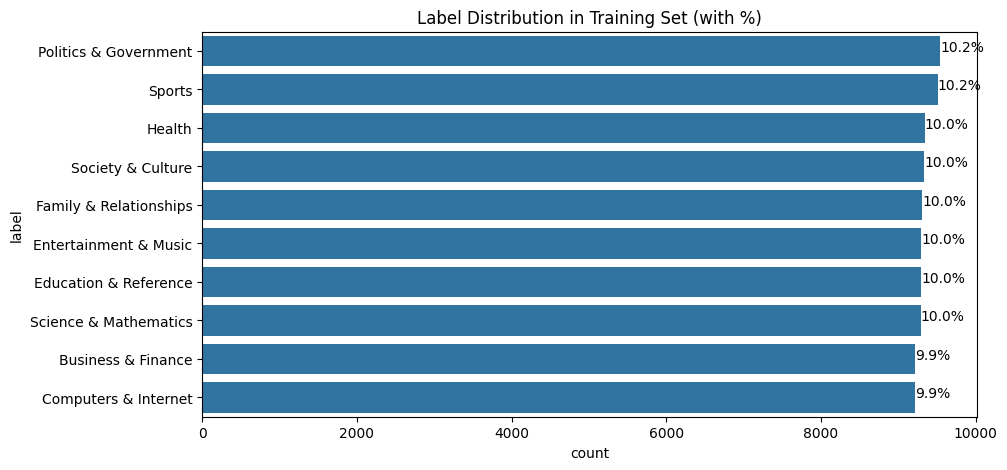

In [ ]:
#Class Distribution with Percentages
train_df.rename(columns={'QA Text': 'text', 'Class': 'label'}, inplace=True)
test_df.rename(columns={'QA Text': 'text', 'Class': 'label'}, inplace=True)


plt.figure(figsize=(10, 5))
ax = sns.countplot(y='label', data=train_df, order=train_df['label'].value_counts().index)
total = len(train_df)
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_width() / total)
    x = p.get_x() + p.get_width() + 0.02
    y = p.get_y() + p.get_height() / 2
    ax.annotate(percentage, (x, y))
plt.title("Label Distribution in Training Set (with %)")
plt.show()

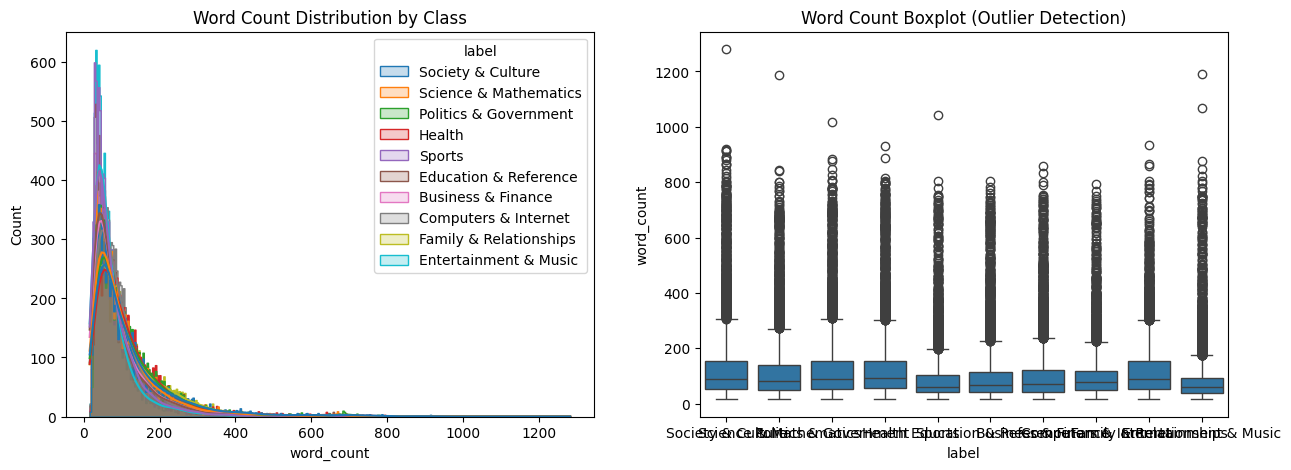

✅ Average Word Count per Class:
label
Business & Finance         99.350656
Computers & Internet       97.893846
Education & Reference      97.083719
Entertainment & Music      82.849258
Family & Relationships    118.417168
Health                    124.875027
Politics & Government     122.659922
Science & Mathematics     113.277748
Society & Culture         125.414916
Sports                     85.831756
Name: word_count, dtype: float64


In [ ]:

# Calculating character length and word count
train_df['char_length'] = train_df['text'].astype(str).apply(len)
train_df['word_count'] = train_df['text'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Word Count Distribution (KDE)
sns.histplot(train_df, x='word_count', hue='label', kde=True, element="step", ax=axes[0])
axes[0].set_title("Word Count Distribution by Class")

# Plot 2: Boxplot for outlier detection
sns.boxplot(x='label', y='word_count', data=train_df, ax=axes[1])
axes[1].set_title("Word Count Boxplot (Outlier Detection)")
plt.show()

print("✅ Average Word Count per Class:")
print(train_df.groupby('label')['word_count'].mean())


--- Diagnostic: Top Words in Raw Data (Before Cleaning) ---


C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


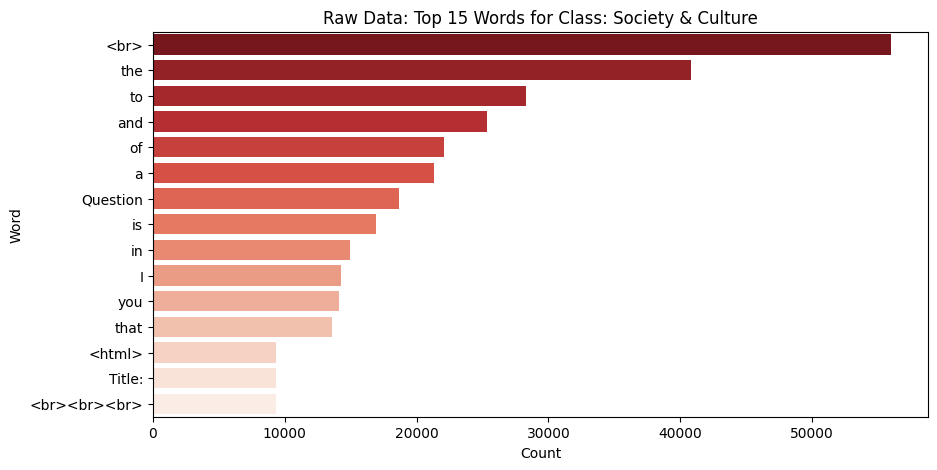

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


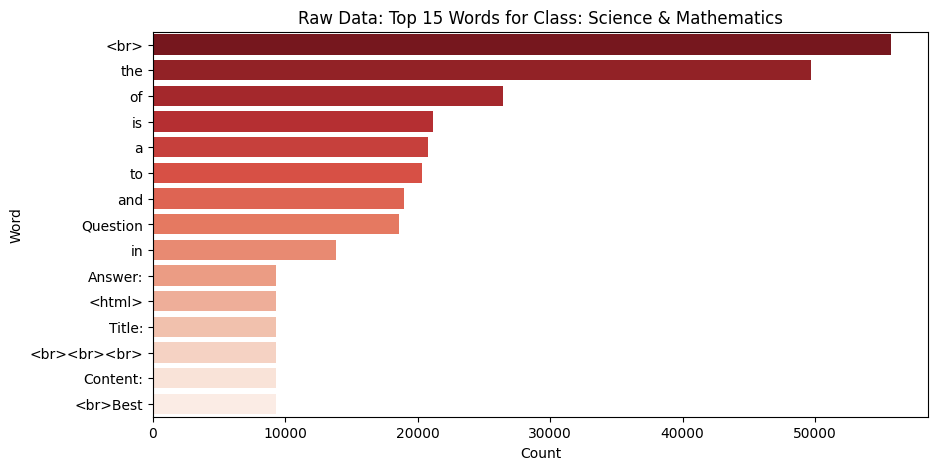

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


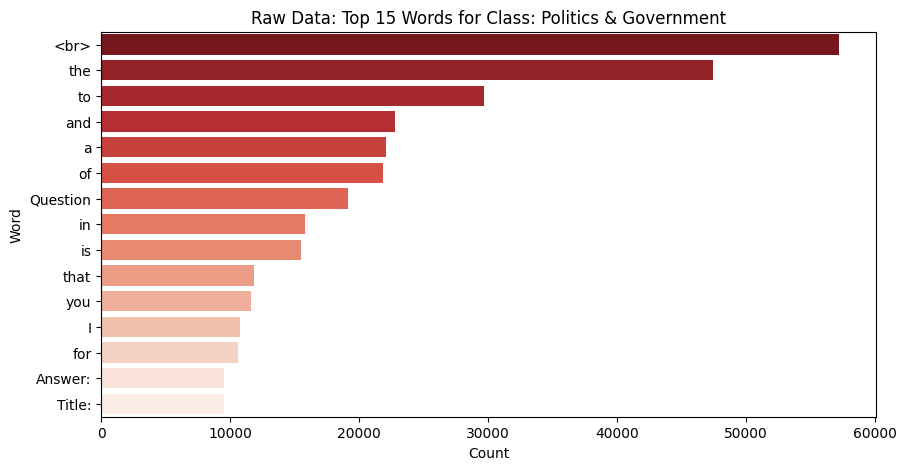

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


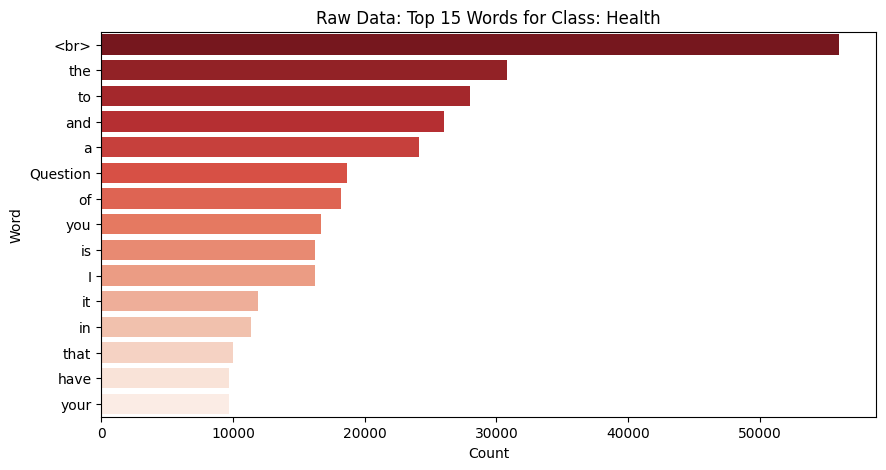

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


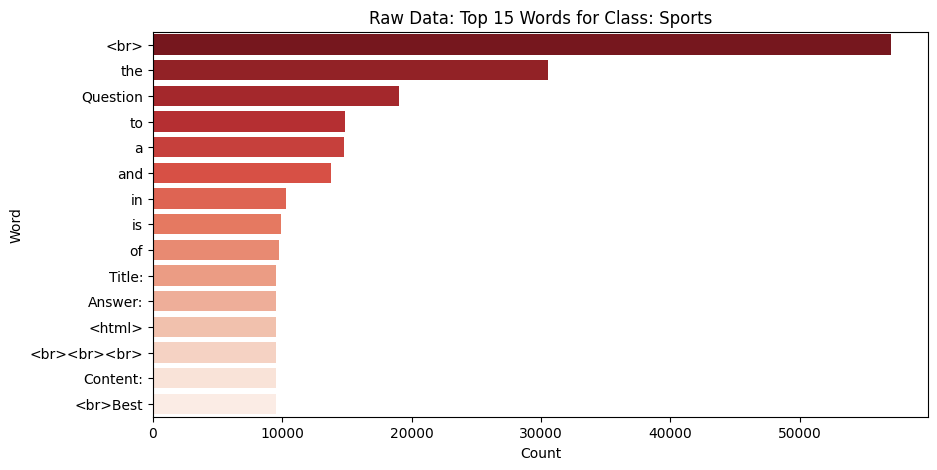

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


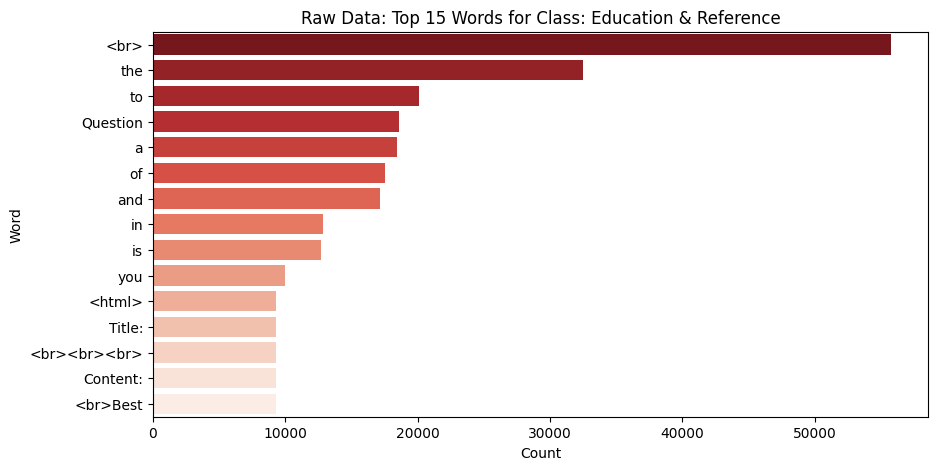

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


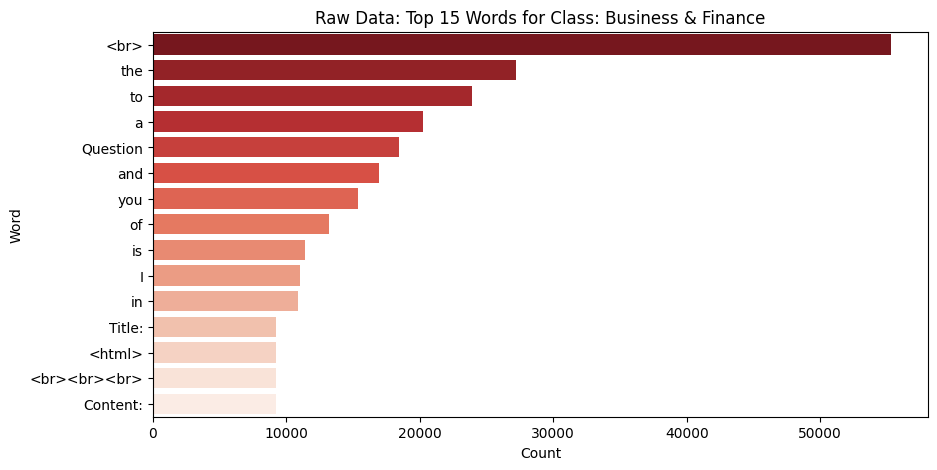

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


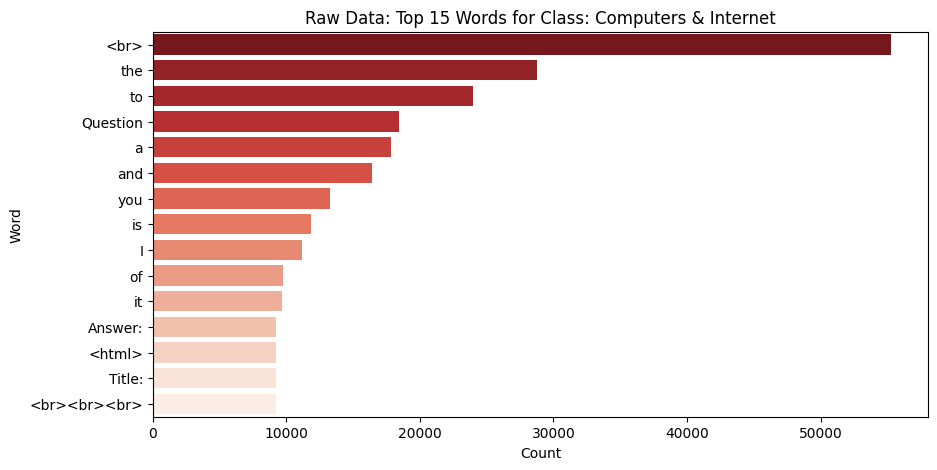

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


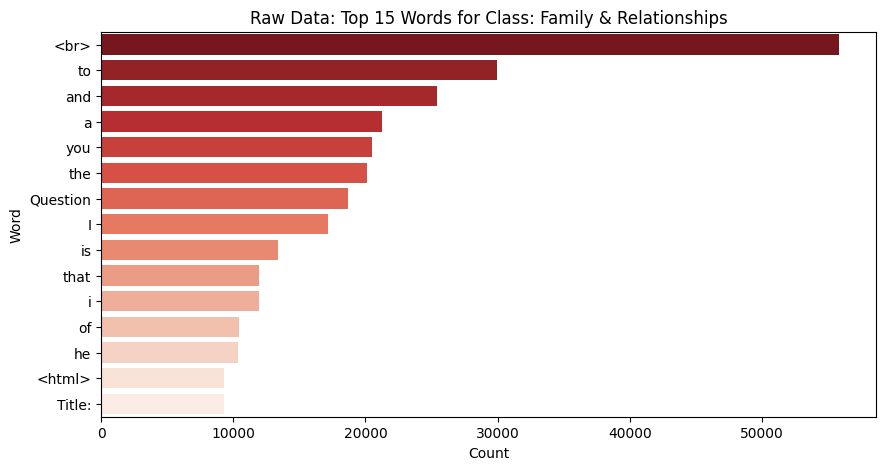

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\4111971565.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"


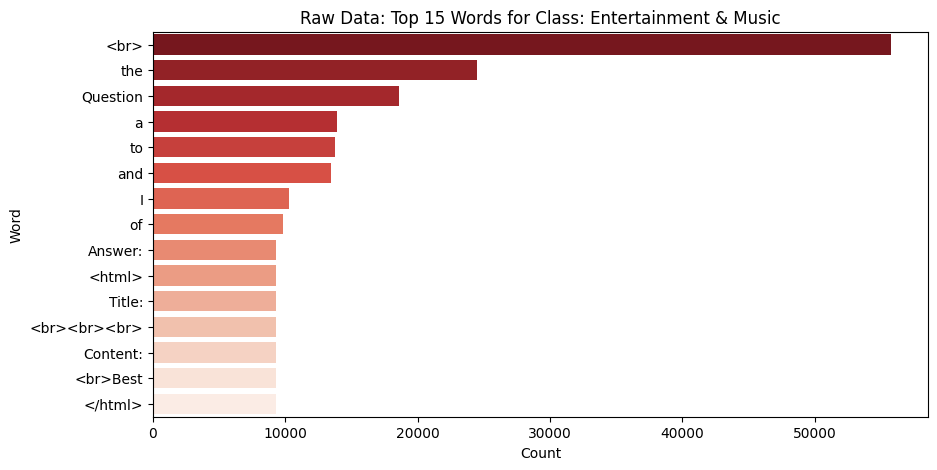

In [ ]:
from collections import Counter
unique_labels = train_df['label'].unique()

def plot_top_words(df, label, text_column='text', n=10):
    subset = df[df['label'] == label]

    # 2. Combine all raw text and split into words
    all_text = " ".join(subset[text_column].astype(str).tolist())
    words = all_text.split()

    # 3. Count frequencies
    word_freq = Counter(words)
    common_words = word_freq.most_common(n)

    # 4. Create a DataFrame for plotting
    words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

    # 5. Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Count', y='Word', data=words_df, palette='Reds_r') # Red palette to indicate "Uncleaned"
    plt.title(f"Raw Data: Top {n} Words for Class: {label}")
    plt.show()

print("\n--- Diagnostic: Top Words in Raw Data (Before Cleaning) ---")
for label in unique_labels:
    # For stop words finding
    plot_top_words(train_df, label, text_column='text', n=15)

In [ ]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# --- DOWNLOADS ---
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

custom_artifacts = {
    'br', 'html', 'http', 'https', 'class', 'span', 'div',
    'question', 'answer', 'title', 'content', 'text', 'best', 'header'
}

stop_words = set(stopwords.words('english')).union(custom_artifacts)
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text): return "empty"

    # Convert to lowercase
    text = str(text).lower()

    # Remove HTML tags and URLs
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove punctuation but KEEP NUMBERS
    # Old: [^a-zA-Z\s]  -> Deletes numbers
    # New: [^a-z0-9\s]  -> Keeps "401k", "10", "3d"
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Tokenize, Lemmatize, and Filter
    # Changed > 2 to > 1 so we keep 2-letter words like "us", "uk", "ai", "pc"
    words = [
        lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in stop_words and len(w) > 1
    ]

    return " ".join(words) if words else "empty"

# Apply to DataFrames
print("Cleaning master training data...")
train_df['clean_text'] = train_df['text'].apply(clean_text)
print(" Cleaning testing data...")
test_df['clean_text'] = test_df['text'].apply(clean_text)

print(" Preprocessing Complete.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\famousBruiser\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\famousBruiser\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\famousBruiser\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Cleaning master training data...
 Cleaning testing data...
 Preprocessing Complete.



--- Generating Top Word Frequency Charts ---


C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


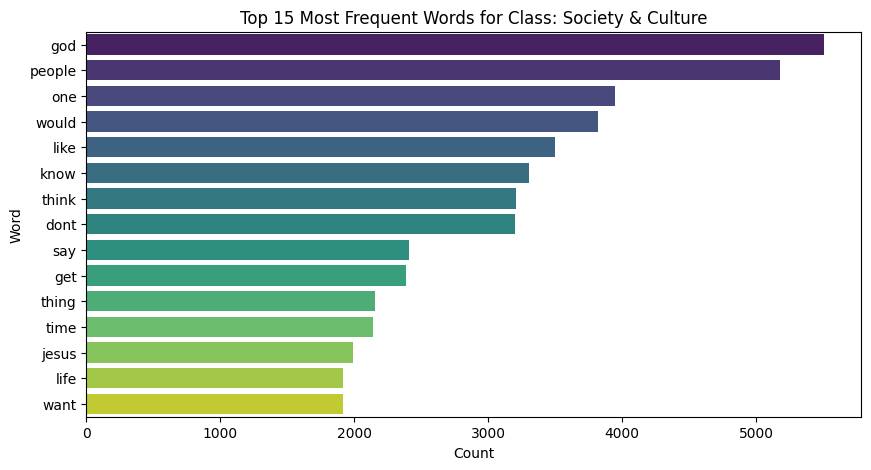

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


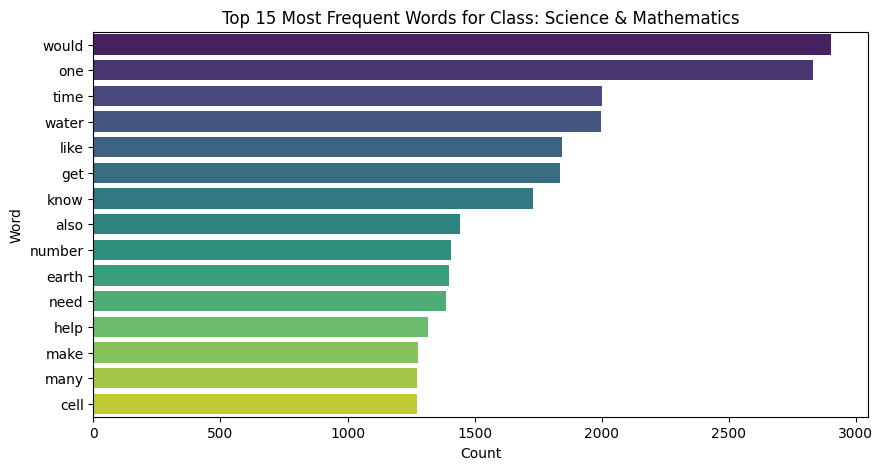

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


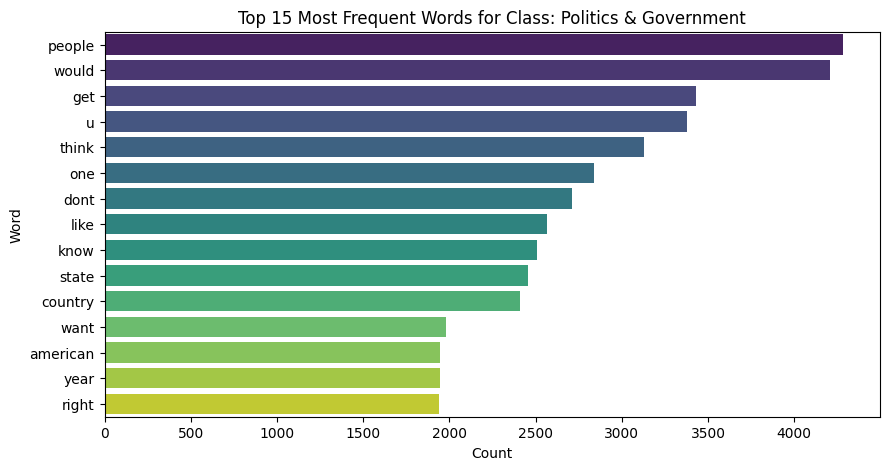

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


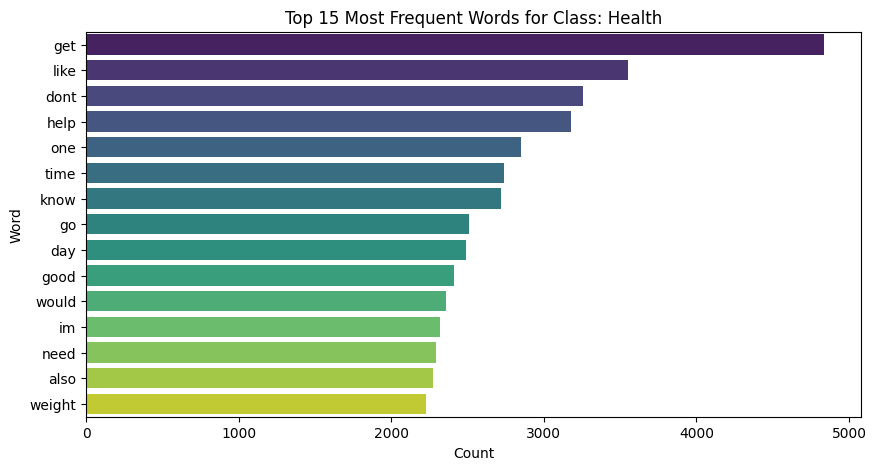

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


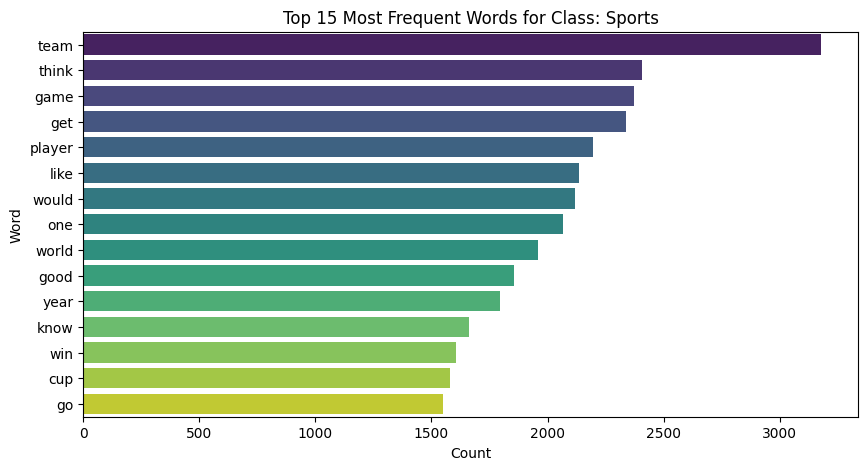

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


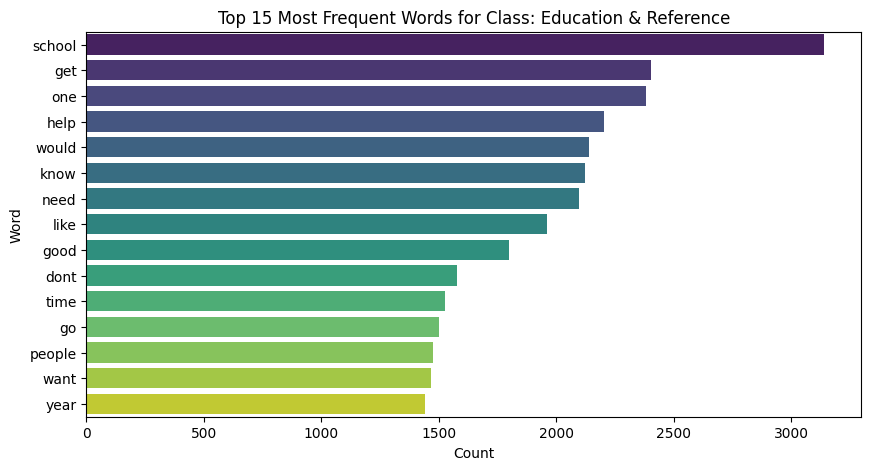

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


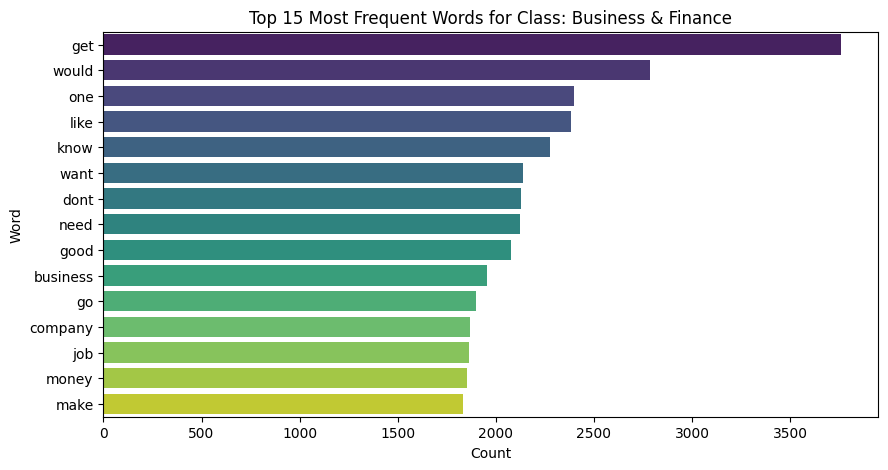

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


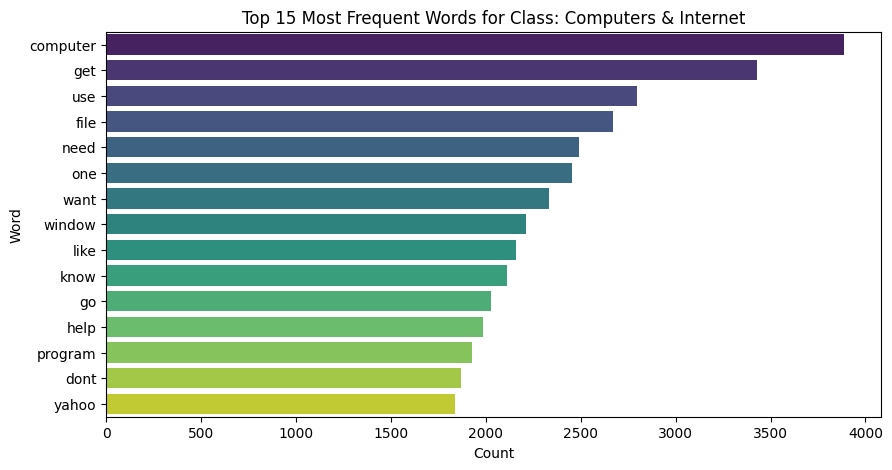

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


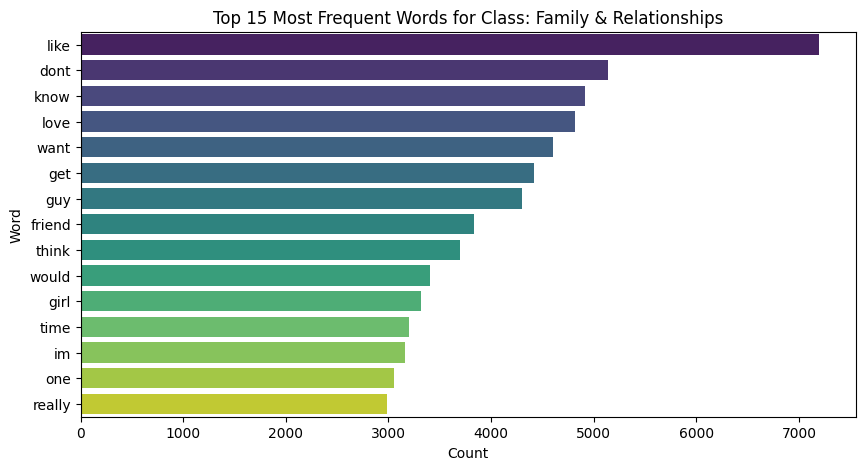

C:\Users\famousBruiser\AppData\Local\Temp\ipykernel_18544\3225976732.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')


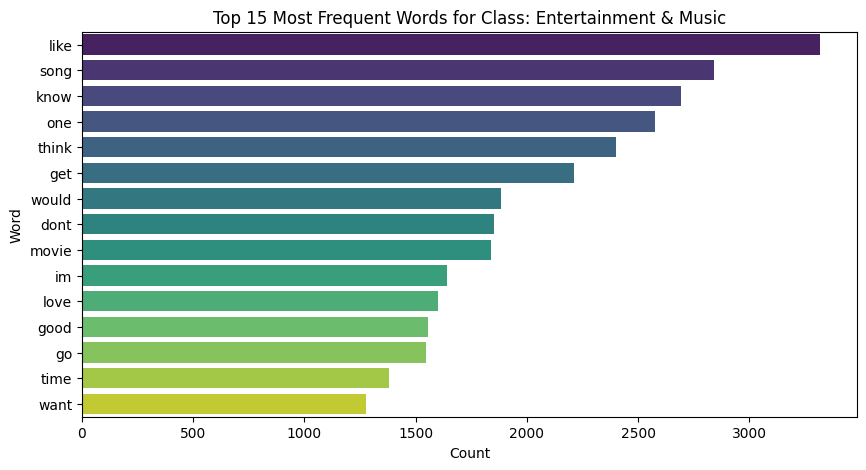

In [ ]:
unique_labels = train_df['label'].unique()

def plot_top_words(df, label, text_column='clean_text', n=10):
    # 1. Filter data for the specific label
    subset = df[df['label'] == label]

    # 2. Combine all text and split into words
    all_text = " ".join(subset[text_column].astype(str).tolist())
    words = all_text.split()

    # 3. Count frequencies
    word_freq = Counter(words)
    common_words = word_freq.most_common(n)

    # 4. Create a DataFrame for plotting
    words_df = pd.DataFrame(common_words, columns=['Word', 'Count'])

    # 5. Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(x='Count', y='Word', data=words_df, palette='viridis')
    plt.title(f"Top {n} Most Frequent Words for Class: {label}")
    plt.show()

print("\n--- Generating Top Word Frequency Charts ---")
# Loop through each label and plot
for label in unique_labels:
    plot_top_words(train_df, label, text_column='clean_text', n=15)

In [ ]:

train_subset, val_subset = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['label'] # Keeps class balance (e.g., 50% Sports in both)
)

print(f"Train Split Shape: {train_subset.shape}")
print(f"Validation Split Shape: {val_subset.shape}")



X_train_text = train_subset['clean_text']
y_train      = train_subset['label']


X_val_text   = val_subset['clean_text']
y_val        = val_subset['label']


X_test_text  = test_df['clean_text']
y_test       = test_df['label']

le = LabelEncoder()

# Fit on the Training Subset ONLY
#  stratify usually fixes it, but fitting on full train_df is also acceptable for labels).
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

num_classes = len(le.classes_)
print(f"Classes: {le.classes_}")

Train Split Shape: (74666, 5)
Validation Split Shape: (18667, 5)
Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']


In [ ]:

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), token_pattern=r'\b[a-zA-Z]{3,}\b') # to remove ab abc


# 2. FIT (Learn Vocabulary) on Training Subset ONLY
print(" Fitting vectorizer on Training Subset...")
tfidf.fit(X_train_text)

# 3. TRANSFORM (Apply Vocabulary) to All Sets
print(" Transforming all datasets...")
X_train_tfidf = tfidf.transform(X_train_text)
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# ----------------------------
# 🔟 Verification
# ----------------------------
print("\n Vectorization Complete.")
print(f"Vocabulary Size: {len(tfidf.vocabulary_)}")
print(f"X_train shape: {X_train_tfidf.shape}")
print(f"X_val shape:   {X_val_tfidf.shape}")
print(f"X_test shape:  {X_test_tfidf.shape}")

# Optional: Peek at the actual words learned
print("\nFirst 10 features in vocabulary:")
print(tfidf.get_feature_names_out()[:10])

 Fitting vectorizer on Training Subset...
 Transforming all datasets...

 Vectorization Complete.
Vocabulary Size: 5000
X_train shape: (74666, 5000)
X_val shape:   (18667, 5000)
X_test shape:  (59999, 5000)

First 10 features in vocabulary:
['abc' 'abdominal' 'ability' 'able' 'able find' 'able get' 'able help'
 'abnormal' 'abortion' 'abroad']


Training On Logistic Regression

In [ ]:
def evaluate_model(model, X_data, y_true, class_names, title="Model Evaluation", cmap='Greens'):
    """
    Evaluates a trained model on a given dataset (Validation or Test).

    Args:
        model: The trained model (must have a .predict() method).
        X_data: The feature data (X_val or X_test).
        y_true: The true labels (y_val or y_test).
        class_names: List of class names (e.g., le.classes_).
        title: Title for the confusion matrix plot.
        cmap: Color map for the confusion matrix (default: 'Greens').
    """

    print(f" Predicting on {title}...")
    predictions = model.predict(X_data)

    # 1. Accuracy Score
    acc = accuracy_score(y_true, predictions)
    print(f"\n{title} ACCURACY: {acc:.4f} ({acc*100:.2f}%)")

    # 2. Detailed Classification Report
    print(f"\n--- Classification Report ({title}) ---")
    print(classification_report(y_true, predictions, target_names=class_names))

    # 3. Confusion Matrix
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {title}')
    plt.show()

In [ ]:
#Model Training (Logistic Regression)
# ----------------------------
print("⏳ Training Logistic Regression Model...")

#max_iter=1000 ensures the model has enough time to find the best solution
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

#FIT on the Training Split (X_train_tfidf)
model.fit(X_train_tfidf, y_train_enc)

print(" Model Trained successfully.")


⏳ Training Logistic Regression Model...
 Model Trained successfully.


⏳ Predicting on Validation Set...

🚀 Validation Set ACCURACY: 0.6694 (66.94%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.53      0.48      0.50      1843
  Computers & Internet       0.81      0.84      0.82      1842
 Education & Reference       0.52      0.47      0.49      1859
 Entertainment & Music       0.64      0.63      0.63      1859
Family & Relationships       0.65      0.74      0.69      1862
                Health       0.72      0.75      0.73      1868
 Politics & Government       0.73      0.73      0.73      1908
 Science & Mathematics       0.65      0.71      0.68      1858
     Society & Culture       0.57      0.53      0.55      1866
                Sports       0.82      0.82      0.82      1902

              accuracy                           0.67     18667
             macro avg       0.67      0.67      0.67     18667
          weighted avg       0.67      0

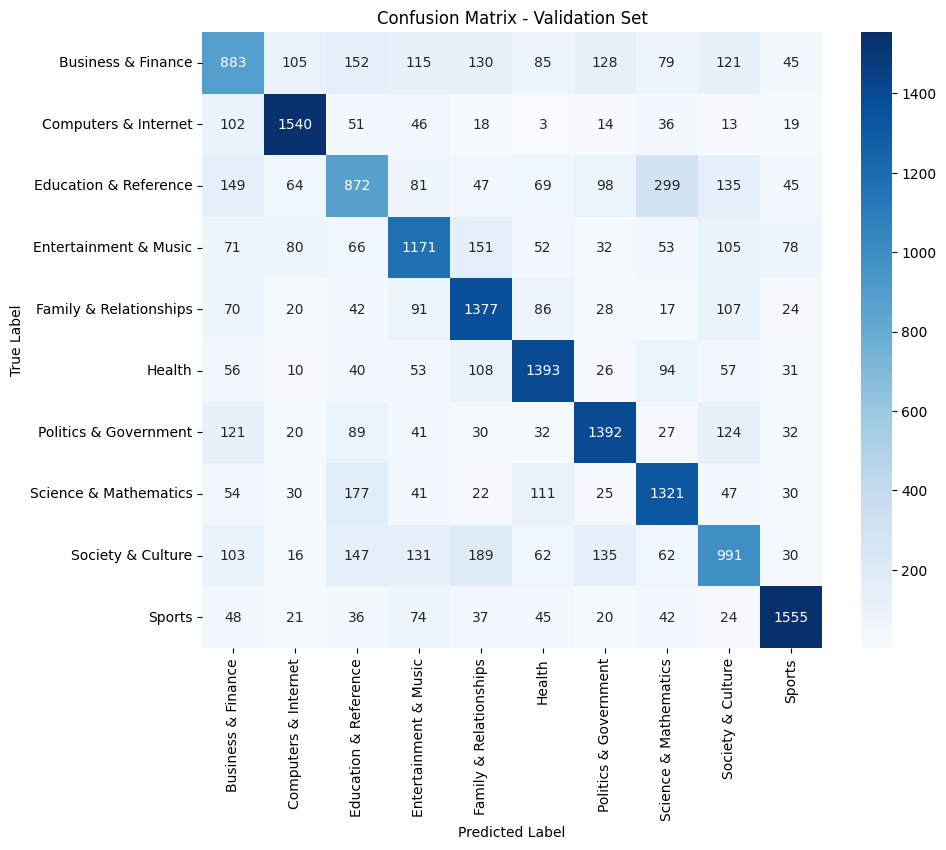

⏳ Predicting on Test Set...

🚀 Test Set ACCURACY: 0.6491 (64.91%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.52      0.47      0.49      6000
  Computers & Internet       0.79      0.81      0.80      6000
 Education & Reference       0.48      0.47      0.47      6000
 Entertainment & Music       0.60      0.61      0.60      6000
Family & Relationships       0.65      0.72      0.68      5999
                Health       0.72      0.74      0.73      6000
 Politics & Government       0.72      0.70      0.71      6000
 Science & Mathematics       0.64      0.70      0.67      6000
     Society & Culture       0.56      0.51      0.54      6000
                Sports       0.80      0.77      0.78      6000

              accuracy                           0.65     59999
             macro avg       0.65      0.65      0.65     59999
          weighted avg       0.65      0.65      0.65     

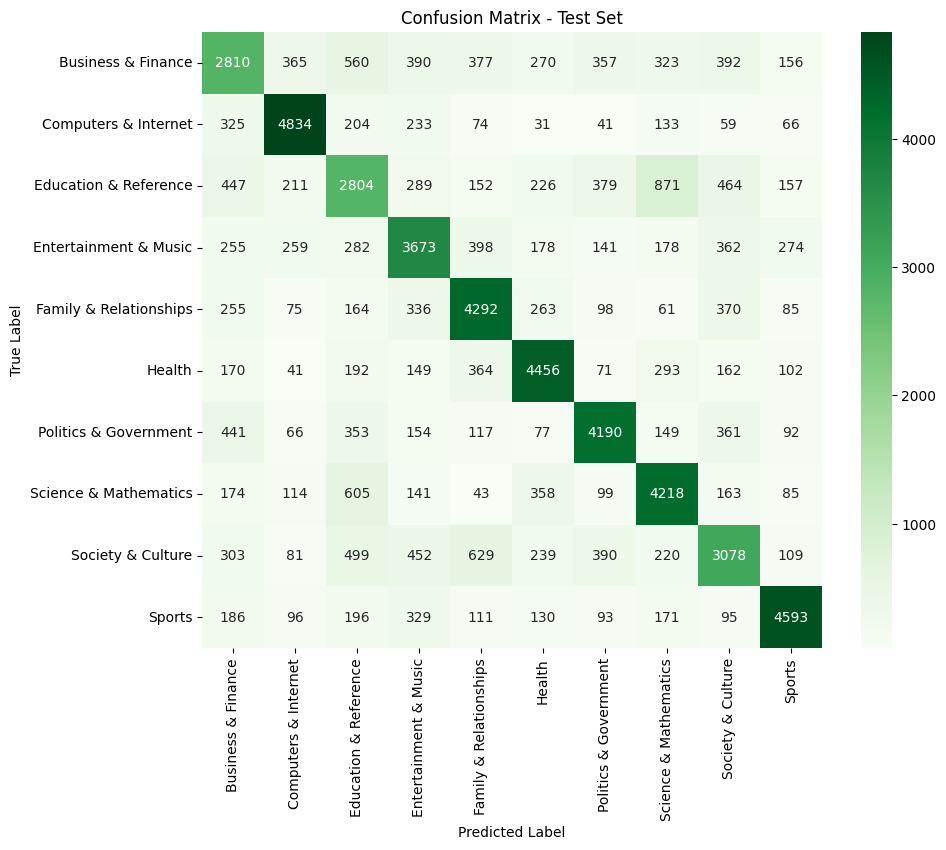

In [ ]:
# ----------------------------
# Model Evaluation (Validation Set)
evaluate_model(
    model,
    X_val_tfidf,
    y_val_enc,
    le.classes_,
    title="Validation Set",
    cmap='Blues'
)

# ----------------------------
# Final Evaluation (Test Set)
# ----------------------------
evaluate_model(
    model,
    X_test_tfidf,
    y_test_enc,
    le.classes_,
    title="Test Set",
    cmap='Greens'
)

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# ----------------------------
# 1. Define the Parameter Grid
# ----------------------------
# 'C' is the most important hyperparameter:
#   - Small C (e.g., 0.1) = Strong Regularization (Prevents Overfitting)
#   - Large C (e.g., 10)  = Weak Regularization (Fits training data closely)
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'], # 'liblinear' handles sparse text data well
    'penalty': ['l2']                 # 'l2' (Ridge) is standard for text
}


# ----------------------------
# 2. Initialize Grid Search
# ----------------------------
# cv=5 means "5-Fold Cross Validation" (Trains 5 times per setting to be sure)
grid_search = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy', # Or 'f1_weighted' if classes are imbalanced
    verbose=1,
    n_jobs=-1 # Uses all CPU cores to speed up training
)

# 3. Fit to Data
grid_search.fit(X_train_tfidf, y_train_enc)

# 4. Results
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f" Best Cross-Val Accuracy: {grid_search.best_score_:.4f}")

# Extract the best model directly to use for predictions
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits

Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
 Best Cross-Val Accuracy: 0.6670


⏳ Predicting on Validation Set (Best LogReg)...

🚀 Validation Set (Best LogReg) ACCURACY: 0.6733 (67.33%)

--- Classification Report (Validation Set (Best LogReg)) ---
                        precision    recall  f1-score   support

    Business & Finance       0.55      0.48      0.51      1843
  Computers & Internet       0.80      0.84      0.82      1842
 Education & Reference       0.54      0.46      0.50      1859
 Entertainment & Music       0.64      0.63      0.63      1859
Family & Relationships       0.65      0.76      0.70      1862
                Health       0.71      0.76      0.73      1868
 Politics & Government       0.73      0.74      0.74      1908
 Science & Mathematics       0.66      0.72      0.68      1858
     Society & Culture       0.58      0.53      0.55      1866
                Sports       0.82      0.82      0.82      1902

              accuracy                           0.67     18667
             macro avg       0.67      0.67      0.67     1866

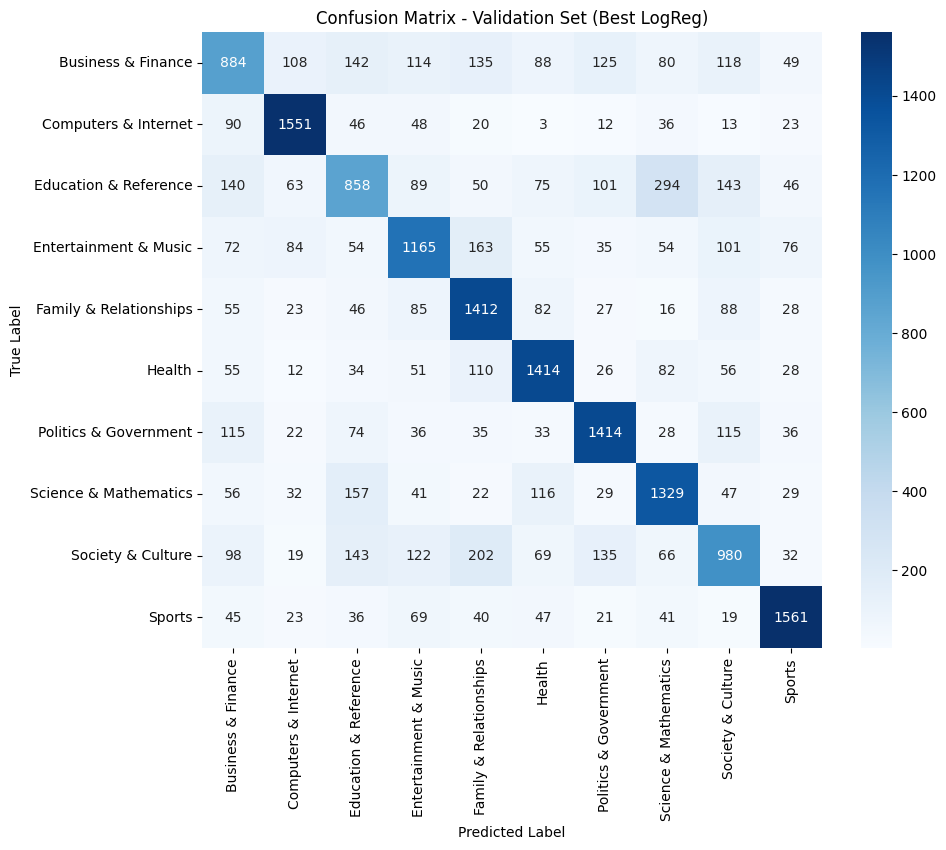

⏳ Predicting on Test Set (Best LogReg)...

🚀 Test Set (Best LogReg) ACCURACY: 0.6530 (65.30%)

--- Classification Report (Test Set (Best LogReg)) ---
                        precision    recall  f1-score   support

    Business & Finance       0.54      0.47      0.50      6000
  Computers & Internet       0.78      0.81      0.80      6000
 Education & Reference       0.49      0.46      0.47      6000
 Entertainment & Music       0.60      0.61      0.61      6000
Family & Relationships       0.65      0.73      0.69      5999
                Health       0.71      0.75      0.73      6000
 Politics & Government       0.71      0.71      0.71      6000
 Science & Mathematics       0.64      0.71      0.67      6000
     Society & Culture       0.57      0.51      0.54      6000
                Sports       0.80      0.77      0.79      6000

              accuracy                           0.65     59999
             macro avg       0.65      0.65      0.65     59999
          weight

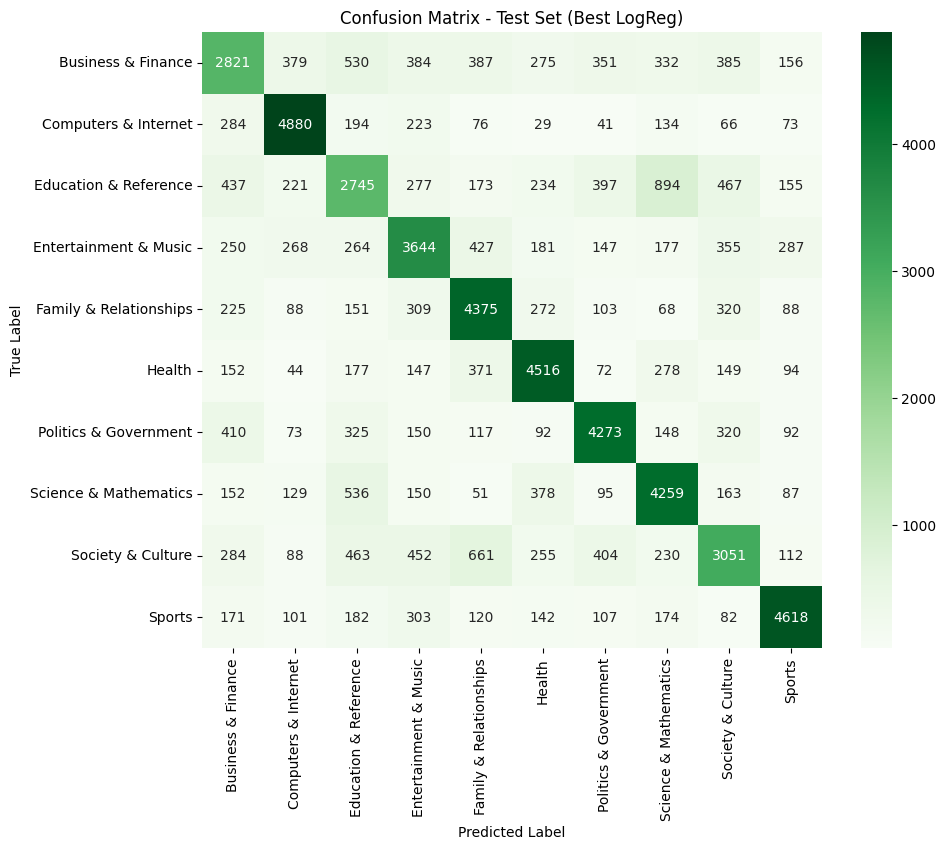

In [ ]:
model_to_evaluate = grid_search.best_estimator_

# 2. Run Evaluation on Validation Set
evaluate_model(
    model_to_evaluate,
    X_val_tfidf,
    y_val_enc,
    le.classes_,
    title="Validation Set (Best LogReg)",
    cmap='Blues'
)

# 3. Run Evaluation on Test Set (Final Result)
evaluate_model(
    model_to_evaluate,
    X_test_tfidf,
    y_test_enc,
    le.classes_,
    title="Test Set (Best LogReg)",
    cmap='Greens'
)

In [ ]:
#deep learning model


In [ ]:
def evaluate_keras_model(model, history, X_val, y_val, X_test, y_test, class_names):
    """
    Evaluates a Keras model: Plots training curves, then checks Validation & Test sets.

    Args:
        model: Trained Keras model.
        history: The history object returned by model.fit().
        X_val, y_val: Validation features and labels.
        X_test, y_test: Test features and labels.
        class_names: List of class names.
    """

    # -------------------------------------------------------
    # 1. Plot Training History (Accuracy & Loss Curves)
    # -------------------------------------------------------
    if history:
        print("\n Plotting Training Curves...")
        acc = history.history['accuracy']
        val_acc = history.history['val_accuracy']
        loss = history.history['loss']
        val_loss = history.history['val_loss']
        epochs_range = range(1, len(acc) + 1)

        plt.figure(figsize=(14, 5))

        # Plot Accuracy
        plt.subplot(1, 2, 1)
        plt.plot(epochs_range, acc, label='Training Accuracy')
        plt.plot(epochs_range, val_acc, label='Validation Accuracy')
        plt.title('Training and Validation Accuracy')
        plt.xlabel('Epochs')
        plt.ylabel('Accuracy')
        plt.legend(loc='lower right')
        plt.grid(True)

        # Plot Loss
        plt.subplot(1, 2, 2)
        plt.plot(epochs_range, loss, label='Training Loss')
        plt.plot(epochs_range, val_loss, label='Validation Loss')
        plt.title('Training and Validation Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend(loc='upper right')
        plt.grid(True)

        plt.show()

    # -------------------------------------------------------
    # Internal Helper to Plot Results for One Dataset
    # -------------------------------------------------------
    def plot_results(X_data, y_true, title, color_map):
        print(f"\n Predicting on {title}...")

        # 1. Get Probabilities
        probs = model.predict(X_data, verbose=0)

        # 2. Convert to Class Indices
        predictions = probs.argmax(axis=1)

        # 3. Print Accuracy
        acc = accuracy_score(y_true, predictions)
        print(f" {title} ACCURACY: {acc:.4f} ({acc*100:.2f}%)")

        # 4. Print Report
        print(f"\n--- Classification Report ({title}) ---")
        print(classification_report(y_true, predictions, target_names=class_names))

        # 5. Plot Confusion Matrix
        plt.figure(figsize=(8, 6))
        cm = confusion_matrix(y_true, predictions)
        sns.heatmap(cm, annot=True, fmt='d', cmap=color_map,
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix - {title}')
        plt.show()

    # -------------------------------------------------------
    # 2. Run Validation Evaluation (Blue)
    # -------------------------------------------------------
    plot_results(X_val, y_val, "Validation Set", 'Blues')

    # -------------------------------------------------------
    # 3. Run Test Evaluation (Green)
    # -------------------------------------------------------
    plot_results(X_test, y_test, "Test Set", 'Greens')




In [ ]:
INPUT_DIM = X_train_tfidf.shape[1]
NUM_CLASSES = len(le.classes_)

# OPTIONAL: Sort sparse indices to prevent TensorFlow warnings
X_train_tfidf.sort_indices()
X_val_tfidf.sort_indices()

# 2. Define the "Normal" Model
model = Sequential([
    # Input Layer
    Input(shape=(INPUT_DIM,)),

    # Hidden Layer 1
    Dense(64, activation='relu'),

    # Dropout to prevent overfitting
    Dropout(0.5),

    # Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

# 3. Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Early Stopping (Standard safety net)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print(f"🚀 Training Base ANN with {INPUT_DIM} TF-IDF features...")

# 5. Train
history = model.fit(
    X_train_tfidf,
    y_train_enc,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_tfidf, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

🚀 Training Base ANN with 5000 TF-IDF features...
Epoch 1/20


C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Reshape:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/sequential/dense/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


2334/2334 [==============================] - 7s 3ms/step - loss: 1.3635 - accuracy: 0.5984 - val_loss: 1.0385 - val_accuracy: 0.6787
Epoch 2/20
2334/2334 [==============================] - 7s 3ms/step - loss: 1.0430 - accuracy: 0.6791 - val_loss: 1.0164 - val_accuracy: 0.6796
Epoch 3/20
2334/2334 [==============================] - 7s 3ms/step - loss: 0.9698 - accuracy: 0.6974 - val_loss: 1.0184 - val_accuracy: 0.6766
Epoch 4/20
2334/2334 [==============================] - 7s 3ms/step - loss: 0.9216 - accuracy: 0.7130 - val_loss: 1.0279 - val_accuracy: 0.6749
Epoch 5/20
2334/2334 [==============================] - 7s 3ms/step - loss: 0.8815 - accuracy: 0.7219 - val_loss: 1.0413 - val_accuracy: 0.6719
Epoch 5: early stopping



 Plotting Training Curves...


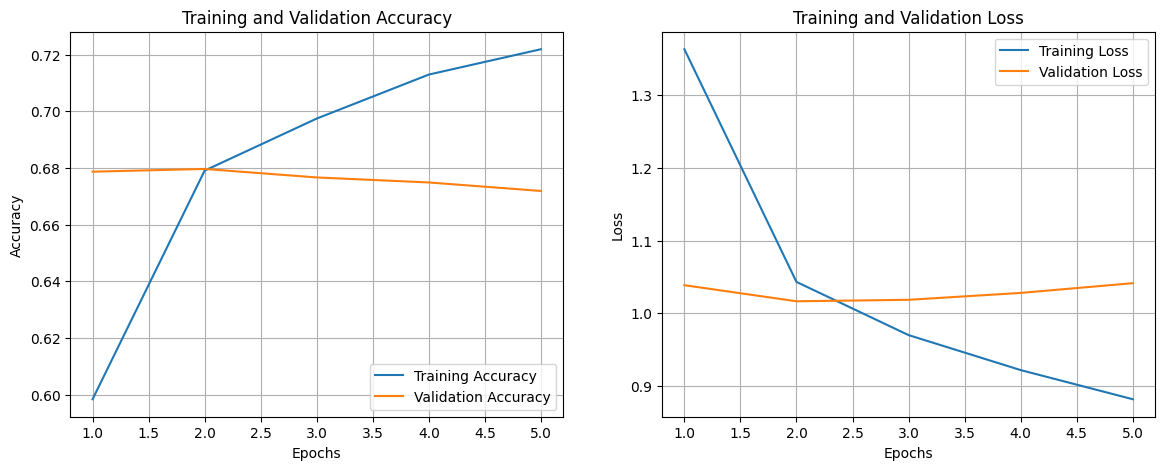


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.6796 (67.96%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.58      0.47      0.52      1843
  Computers & Internet       0.80      0.85      0.82      1842
 Education & Reference       0.55      0.46      0.50      1859
 Entertainment & Music       0.64      0.65      0.64      1859
Family & Relationships       0.63      0.78      0.69      1862
                Health       0.72      0.77      0.74      1868
 Politics & Government       0.73      0.76      0.74      1908
 Science & Mathematics       0.66      0.72      0.69      1858
     Society & Culture       0.62      0.52      0.56      1866
                Sports       0.83      0.82      0.82      1902

              accuracy                           0.68     18667
             macro avg       0.67      0.68      0.67     18667
          weighted avg       0.68      0.6

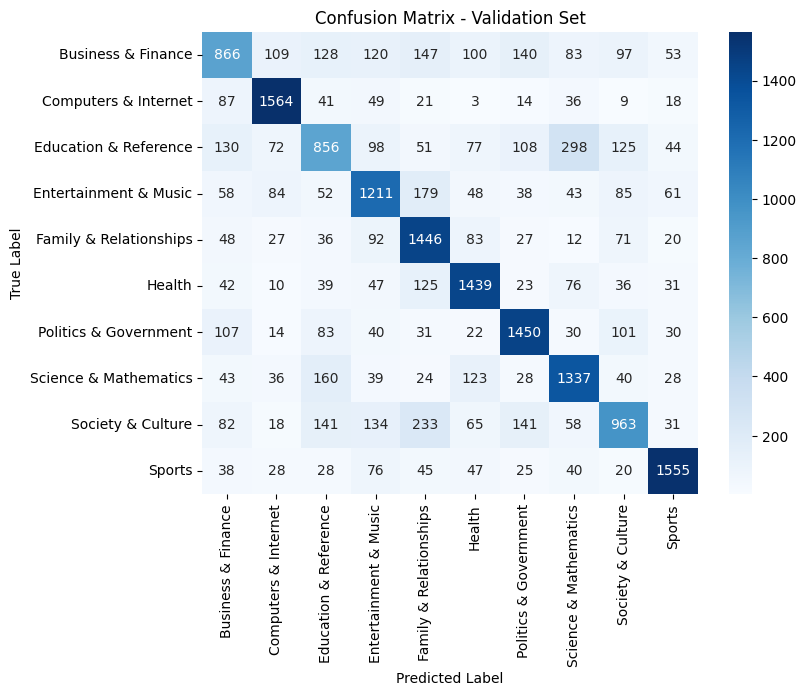


 Predicting on Test Set...
 Test Set ACCURACY: 0.6579 (65.79%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.56      0.46      0.51      6000
  Computers & Internet       0.78      0.82      0.80      6000
 Education & Reference       0.51      0.45      0.48      6000
 Entertainment & Music       0.59      0.63      0.61      6000
Family & Relationships       0.63      0.75      0.68      5999
                Health       0.71      0.76      0.73      6000
 Politics & Government       0.70      0.74      0.72      6000
 Science & Mathematics       0.65      0.71      0.68      6000
     Society & Culture       0.61      0.48      0.54      6000
                Sports       0.81      0.78      0.79      6000

              accuracy                           0.66     59999
             macro avg       0.65      0.66      0.65     59999
          weighted avg       0.65      0.66      0.65     59

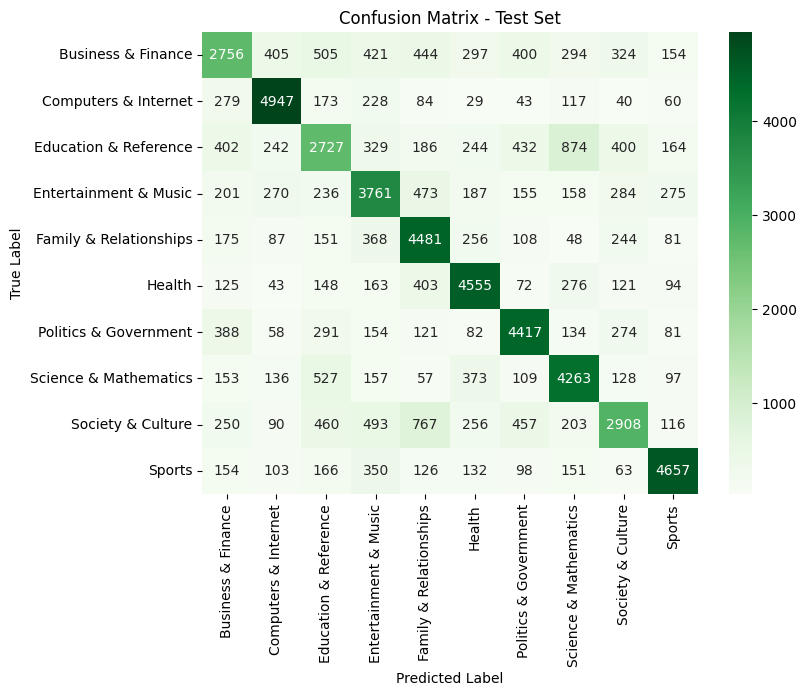

In [ ]:
# 1. Ensure Test Data is Ready & Sorted (Best practice for TF)
X_test_tfidf.sort_indices()

evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_tfidf,      # TF-IDF features now
    y_val=y_val_enc,
    X_test=X_test_tfidf,    #Using TF-IDF features now
    y_test=y_test_enc,
    class_names=list(le.classes_)
)

In [ ]:
param_grid = {
    'hidden_layers': [1, 2],       # Test 1 layer vs 2 layers
    'units': [32, 64],             # Test neuron counts
    'dropout_rate': [0.3, 0.5],    # Test regularization strength
    'learning_rate': [0.001]
}

# Store results here
results = []
INPUT_DIM = X_train_tfidf.shape[1]
NUM_CLASSES = len(le.classes_)

print(" Starting Grid Search...")

# 2. Start the Loops (Grid Search)
for layers in param_grid['hidden_layers']:
    for units in param_grid['units']:
        for dropout in param_grid['dropout_rate']:

            print(f"\nTesting: Layers={layers}, Units={units}, Dropout={dropout}")

            # --- Build Model ---
            model = Sequential()
            model.add(Input(shape=(INPUT_DIM,)))

            # First Layer
            model.add(Dense(units, activation='relu'))
            model.add(Dropout(dropout))

            # (Optional) Second Layer
            if layers == 2:
                model.add(Dense(units, activation='relu'))
                model.add(Dropout(dropout))

            # Output Layer
            model.add(Dense(NUM_CLASSES, activation='softmax'))

            # --- Compile & Train ---
            model.compile(optimizer=Adam(learning_rate=0.001),
                          loss='sparse_categorical_crossentropy',
                          metrics=['accuracy'])

            early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=0, restore_best_weights=True)

            history = model.fit(
                X_train_tfidf, y_train_enc,
                epochs=15, # Keep epochs low for search speed
                batch_size=32,
                validation_data=(X_val_tfidf, y_val_enc),
                callbacks=[early_stop],
                verbose=0 # Silent mode
            )

            # --- Record Best Result ---
            # Get the highest val_accuracy reached during training
            best_val_acc = max(history.history['val_accuracy'])
            print(f"   >>> Result: {best_val_acc:.4f}")

            results.append({
                'Layers': layers,
                'Units': units,
                'Dropout': dropout,
                'Val_Acc': best_val_acc
            })

# 3. Show Final Report
print("\n Grid Search Complete! Here are the results:")
df_results = pd.DataFrame(results)
# Sort by Validation Accuracy (Best on top)
df_sorted = df_results.sort_values(by='Val_Acc', ascending=False)
print(df_sorted)

# 4. Recommendation
print(f"\n The Best Configuration is:\n{df_sorted.iloc[0]}")

 Starting Grid Search...

Testing: Layers=1, Units=32, Dropout=0.3


C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_1/dense_2/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_1/dense_2/embedding_lookup_sparse/Reshape:0", shape=(None, 32), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_1/dense_2/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


   >>> Result: 0.6785

Testing: Layers=1, Units=32, Dropout=0.5


C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_2/dense_4/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_2/dense_4/embedding_lookup_sparse/Reshape:0", shape=(None, 32), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_2/dense_4/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


   >>> Result: 0.6754

Testing: Layers=1, Units=64, Dropout=0.3


...

   >>> Result: 0.6579

Testing: Layers=2, Units=64, Dropout=0.3


C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_7/dense_16/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_7/dense_16/embedding_lookup_sparse/Reshape:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_7/dense_16/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


   >>> Result: 0.6736

Testing: Layers=2, Units=64, Dropout=0.5


C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_8/dense_19/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_8/dense_19/embedding_lookup_sparse/Reshape:0", shape=(None, 64), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_8/dense_19/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


   >>> Result: 0.6727

 Grid Search Complete! Here are the results:
   Layers  Units  Dropout   Val_Acc
0       1     32      0.3  0.678470
3       1     64      0.5  0.677291
2       1     64      0.3  0.676274
1       1     32      0.5  0.675363
6       2     64      0.3  0.673649
7       2     64      0.5  0.672684
4       2     32      0.3  0.669952
5       2     32      0.5  0.657899

 The Best Configuration is:
Layers      1.00000
Units      32.00000
Dropout     0.30000
Val_Acc     0.67847
Name: 0, dtype: float64


In [ ]:
BEST_UNITS = 32
BEST_DROPOUT = 0.3
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 30
# ==========================================

# 1. Prepare Dimensions
INPUT_DIM = X_train_tfidf.shape[1]
NUM_CLASSES = len(le.classes_)

# 2. Build the Champion Model
model = Sequential([
    # Input Layer
    Input(shape=(INPUT_DIM,)),

    # --- HIDDEN LAYER 1 (The Winner) ---
    Dense(BEST_UNITS, activation='relu'),

    # --- DROPOUT (The Winner) ---
    Dropout(BEST_DROPOUT),

    # Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

# 3. Compile
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 4. Early Stopping
# We can be a bit stricter now that we know the architecture is stable
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,             # Increased patience slightly to let it settle
    verbose=1,
    restore_best_weights=True
)

print(f" Training Final Champion ANN (Units={BEST_UNITS}, Dropout={BEST_DROPOUT})...")

history = model.fit(
    X_train_tfidf,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_tfidf, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

 Training Final Champion ANN (Units=32, Dropout=0.3)...
Epoch 1/30
   1/2334 [..............................] - ETA: 9:09 - loss: 2.3083 - accuracy: 0.0000e+00

C:\Users\famousBruiser\anaconda3\envs\tf_gpu\lib\site-packages\tensorflow\python\framework\indexed_slices.py:444: UserWarning: Converting sparse IndexedSlices(IndexedSlices(indices=Tensor("gradient_tape/sequential_9/dense_22/embedding_lookup_sparse/Reshape_1:0", shape=(None,), dtype=int32), values=Tensor("gradient_tape/sequential_9/dense_22/embedding_lookup_sparse/Reshape:0", shape=(None, 32), dtype=float32), dense_shape=Tensor("gradient_tape/sequential_9/dense_22/embedding_lookup_sparse/Cast:0", shape=(2,), dtype=int32))) to a dense Tensor of unknown shape. This may consume a large amount of memory.
  warnings.warn(


2334/2334 [==============================] - 6s 2ms/step - loss: 1.3948 - accuracy: 0.5940 - val_loss: 1.0499 - val_accuracy: 0.6739
Epoch 2/30
2334/2334 [==============================] - 6s 2ms/step - loss: 1.0436 - accuracy: 0.6771 - val_loss: 1.0186 - val_accuracy: 0.6757
Epoch 3/30
2334/2334 [==============================] - 6s 2ms/step - loss: 0.9756 - accuracy: 0.6948 - val_loss: 1.0202 - val_accuracy: 0.6734
Epoch 4/30
2334/2334 [==============================] - 6s 2ms/step - loss: 0.9246 - accuracy: 0.7087 - val_loss: 1.0277 - val_accuracy: 0.6720
Epoch 5/30
2334/2334 [==============================] - 6s 2ms/step - loss: 0.8867 - accuracy: 0.7189 - val_loss: 1.0435 - val_accuracy: 0.6691
Epoch 6/30
2334/2334 [==============================] - 6s 2ms/step - loss: 0.8549 - accuracy: 0.7290 - val_loss: 1.0570 - val_accuracy: 0.6660
Epoch 7/30
2334/2334 [==============================] - 6s 2ms/step - loss: 0.8258 - accuracy: 0.7351 - val_loss: 1.0730 - val_accuracy: 0.6650
Epo


 Plotting Training Curves...


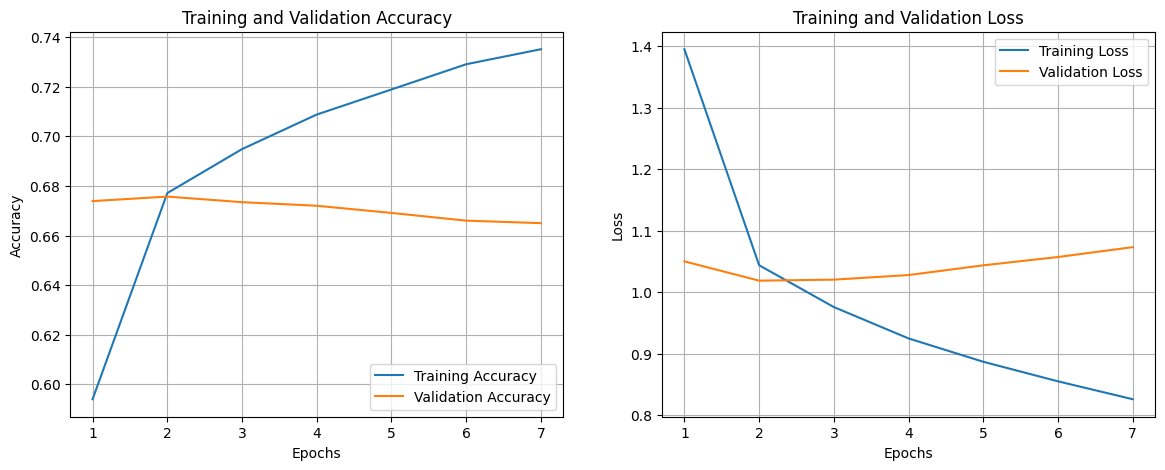


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.6757 (67.57%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.58      0.44      0.50      1843
  Computers & Internet       0.80      0.85      0.82      1842
 Education & Reference       0.54      0.46      0.49      1859
 Entertainment & Music       0.65      0.63      0.64      1859
Family & Relationships       0.62      0.78      0.69      1862
                Health       0.73      0.76      0.74      1868
 Politics & Government       0.72      0.77      0.74      1908
 Science & Mathematics       0.66      0.73      0.69      1858
     Society & Culture       0.59      0.53      0.56      1866
                Sports       0.82      0.82      0.82      1902

              accuracy                           0.68     18667
             macro avg       0.67      0.68      0.67     18667
          weighted avg       0.67      0.6

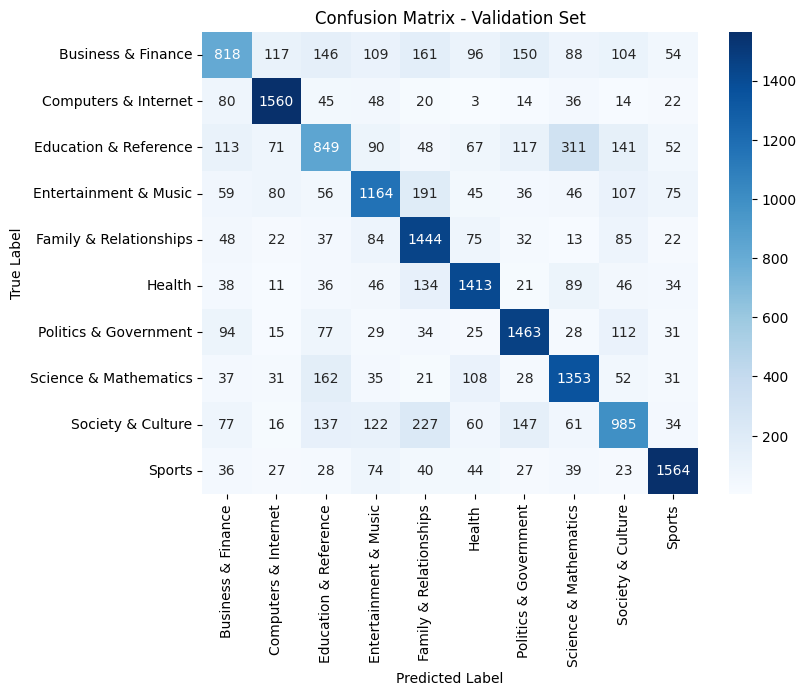


 Predicting on Test Set...
 Test Set ACCURACY: 0.6569 (65.69%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.45      0.50      6000
  Computers & Internet       0.78      0.82      0.80      6000
 Education & Reference       0.50      0.46      0.48      6000
 Entertainment & Music       0.60      0.61      0.61      6000
Family & Relationships       0.63      0.75      0.68      5999
                Health       0.72      0.75      0.74      6000
 Politics & Government       0.70      0.74      0.72      6000
 Science & Mathematics       0.64      0.72      0.68      6000
     Society & Culture       0.58      0.50      0.54      6000
                Sports       0.80      0.78      0.79      6000

              accuracy                           0.66     59999
             macro avg       0.65      0.66      0.65     59999
          weighted avg       0.65      0.66      0.65     59

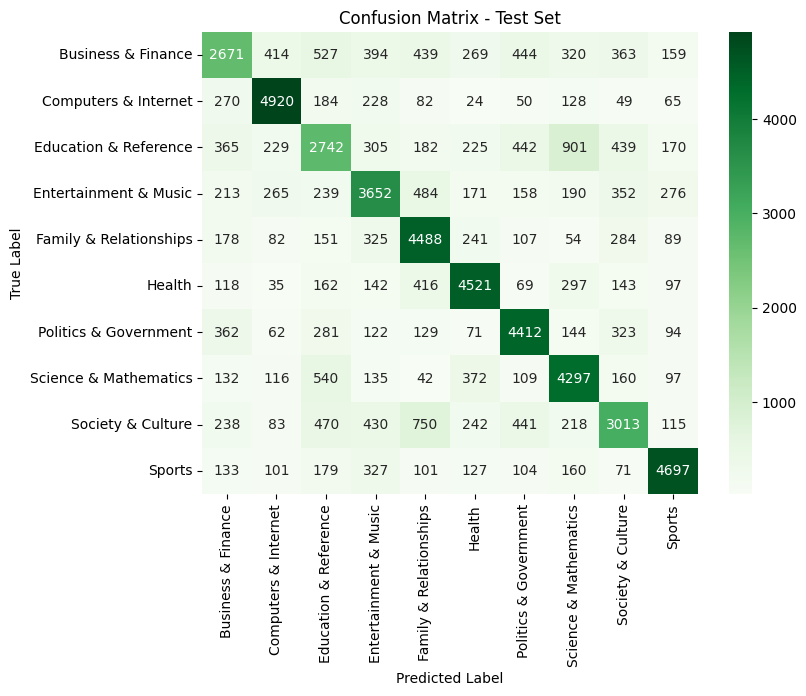

In [ ]:
# Evaluate the Champion Model
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_tfidf,
    y_val=y_val_enc,
    X_test=X_test_tfidf,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)

##skip-gram


In [ ]:

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ----------------------------
# 1️⃣ Tokenization & Sequence Padding

# Define max vocab size (keep top 20,000 words) and max length of a sentence
MAX_VOCAB_SIZE = 20000
MAX_SEQUENCE_LENGTH = 200

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text) # Learn vocab from Train only

# Convert text to sequences of integers
print(" Converting text to sequences...")
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

print(" Padding sequences...")
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

# ----------------------------
# 2️⃣ Verification
# ----------------------------
print(f" Data Shapes: Train={X_train_pad.shape}, Val={X_val_pad.shape}")

print("\nExample of 'Pre' Padding (Zeros at the start):")
print(X_train_pad[0])

 Converting text to sequences...
 Padding sequences...
 Data Shapes: Train=(74666, 200), Val=(18667, 200)

Example of 'Pre' Padding (Zeros at the start):
[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence
# ----------------------------
#  Train Skip-gram Model
# ----------------------------
print(" Training Skip-gram Word2Vec Model...")
sentences = [text_to_word_sequence(text) for text in X_train_text]

# 2. TRAIN MODEL
# sg=1 is Skip-gram (good for smaller datasets and rare words)

w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=2, workers=4, sg=1)

print(f" Word2Vec Trained. Vocab size: {len(w2v_model.wv)}")

# Check a word association
# Wrap in try-except in case 'money' was filtered out (unlikely, but good practice)
try:
    print("Most similar to 'money':", w2v_model.wv.most_similar('money', topn=3))
except KeyError:
    print("'money' not in vocabulary")

 Training Skip-gram Word2Vec Model...
 Word2Vec Trained. Vocab size: 69551
Most similar to 'money': [('repay', 0.7694954872131348), ('borrowing', 0.7619079351425171), ('lend', 0.748183012008667)]


In [ ]:
vocab_size = MAX_VOCAB_SIZE
embedding_dim = 100

# --- 2. Create the Matrix ---
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# --- 3. Fill Matrix ---
hits = 0
misses = 0

for word, i in tokenizer.word_index.items():
    if i >= MAX_VOCAB_SIZE:
        continue

    try:
        embedding_vector = w2v_model.wv[word]
        embedding_matrix[i] = embedding_vector
        hits += 1
    except KeyError:
        # Word not in Word2Vec -> Leave as zeros (or random init)
        misses += 1

print(f" Embedding Matrix Ready: {embedding_matrix.shape}")
print(f"   Hits: {hits} (Words found in W2V)")
print(f"   Misses: {misses} (Words new/unique to this dataset)")

 Embedding Matrix Ready: (20000, 100)
   Hits: 19998 (Words found in W2V)
   Misses: 1 (Words new/unique to this dataset)


In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling1D
DENSE_UNITS = 32         # Standard starting point
DROPOUT_RATE = 0.5
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 40
# ==========================================

# Dimensions from your previous steps
# Ensure vocab_size matches the shape of your embedding_matrix
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
MAX_SEQUENCE_LENGTH = 200                   # As defined earlier

model = Sequential([
    # 1. Input Layer
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    # 2. Embedding Layer (Using your Word2Vec weights)
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix], # <--- Loading your matrix here
              trainable=False),           # Keep False for base model to preserve W2V features

    # 3. Pooling Layer
    # This averages the 200 word vectors into 1 summary vector
    GlobalAveragePooling1D(),

    # 4. Hidden Dense Layer
    Dense(DENSE_UNITS, activation='relu'),
    Dropout(DROPOUT_RATE),

    # 5. Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print(f" Training ANN with Word2Vec Embeddings...")

# Note: We go back to using X_train_pad (Sequences), NOT X_train_tfidf
history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

 Training ANN with Word2Vec Embeddings...
Epoch 1/40
2334/2334 [==============================] - 5s 2ms/step - loss: 1.8124 - accuracy: 0.4201 - val_loss: 1.4463 - val_accuracy: 0.6037
Epoch 2/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.4903 - accuracy: 0.5310 - val_loss: 1.2934 - val_accuracy: 0.6262
Epoch 3/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.4069 - accuracy: 0.5572 - val_loss: 1.2267 - val_accuracy: 0.6339
Epoch 4/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.3689 - accuracy: 0.5678 - val_loss: 1.1979 - val_accuracy: 0.6401
Epoch 5/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.3403 - accuracy: 0.5771 - val_loss: 1.1649 - val_accuracy: 0.6448
Epoch 6/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.3200 - accuracy: 0.5831 - val_loss: 1.1558 - val_accuracy: 0.6475
Epoch 7/40
2334/2334 [==============================] - 4s 2ms/step - loss: 1.3063 - accuracy:


 Plotting Training Curves...


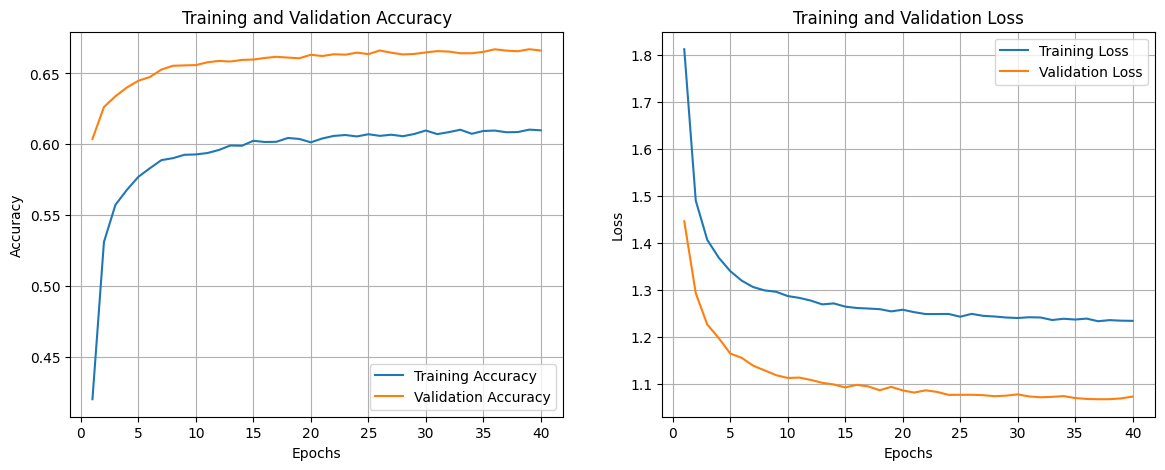


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.6661 (66.61%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.57      0.44      0.50      1843
  Computers & Internet       0.78      0.86      0.82      1842
 Education & Reference       0.56      0.38      0.45      1859
 Entertainment & Music       0.60      0.63      0.61      1859
Family & Relationships       0.64      0.75      0.69      1862
                Health       0.74      0.76      0.75      1868
 Politics & Government       0.66      0.79      0.72      1908
 Science & Mathematics       0.65      0.75      0.70      1858
     Society & Culture       0.57      0.49      0.53      1866
                Sports       0.81      0.81      0.81      1902

              accuracy                           0.67     18667
             macro avg       0.66      0.67      0.66     18667
          weighted avg       0.66      0.6

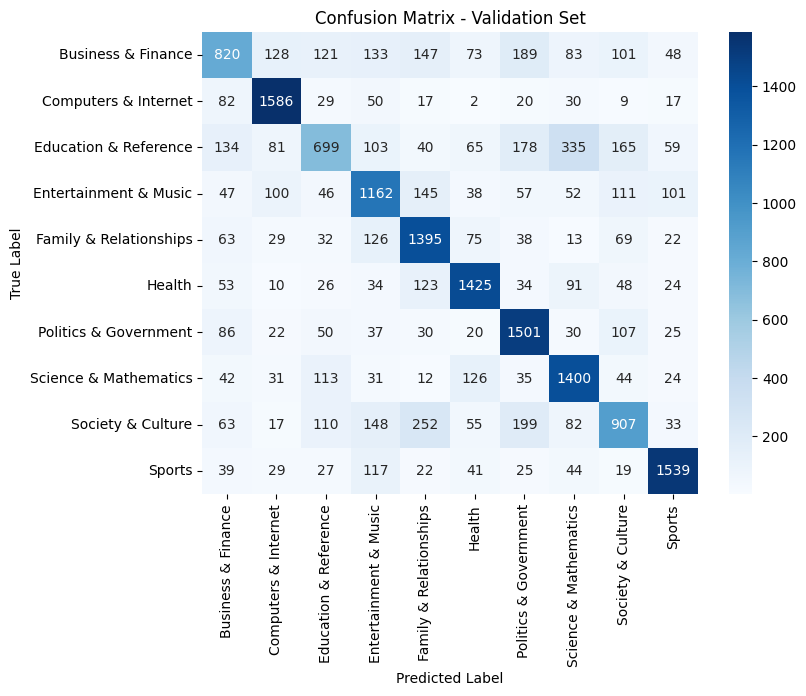


 Predicting on Test Set...
 Test Set ACCURACY: 0.6482 (64.82%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.48      0.45      0.46      6000
  Computers & Internet       0.77      0.83      0.80      6000
 Education & Reference       0.51      0.37      0.43      6000
 Entertainment & Music       0.57      0.63      0.60      6000
Family & Relationships       0.65      0.72      0.68      5999
                Health       0.74      0.75      0.74      6000
 Politics & Government       0.65      0.77      0.71      6000
 Science & Mathematics       0.65      0.72      0.68      6000
     Society & Culture       0.58      0.46      0.51      6000
                Sports       0.82      0.77      0.80      6000

              accuracy                           0.65     59999
             macro avg       0.64      0.65      0.64     59999
          weighted avg       0.64      0.65      0.64     59

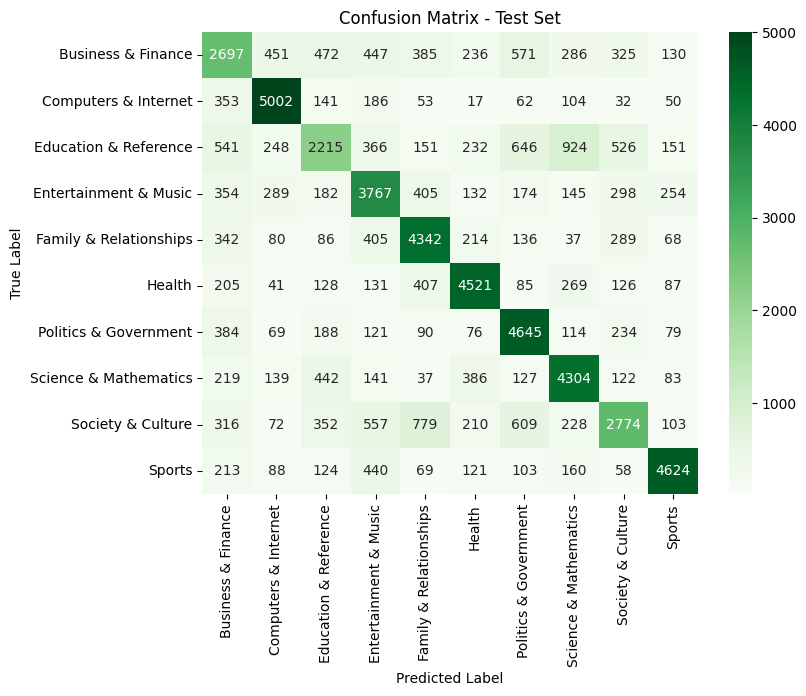

In [ ]:
# Evaluate the Base ANN (Word2Vec Version)
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,      # <--- MUST use Padded Sequences here
    y_val=y_val_enc,
    X_test=X_test_pad,    # <--- MUST use Padded Sequences here
    y_test=y_test_enc,
    class_names=list(le.classes_)
)

In [ ]:
from tensorflow.keras.regularizers import l2

# ==========================================
#  1. Define Full Parameter Grid
# ==========================================
param_grid = {
    'hidden_layers': [1, 2],       # <--- Testing Multilayer again
    'units': [32, 64],             # Width
    'dropout_rate': [0.3, 0.5],    # Dropout
    'l2_strength': [0.01, 0.001],  # L2 Regularization
    'learning_rate': [0.001]
}

results = []
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
MAX_SEQUENCE_LENGTH = 200

print(f" Starting Full Grid Search (Layers, Units, Dropout, L2)...")

# ==========================================
#  2. Start the Nested Loops
# ==========================================
for layers in param_grid['hidden_layers']:
    for units in param_grid['units']:
        for dropout in param_grid['dropout_rate']:
            for l2_val in param_grid['l2_strength']:

                print(f"\nTesting: Layers={layers}, Units={units}, Drop={dropout}, L2={l2_val}")

                model = Sequential()

                # --- Fixed Base (Word2Vec) ---
                model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
                model.add(Embedding(input_dim=vocab_size,
                                    output_dim=embedding_dim,
                                    weights=[embedding_matrix],
                                    trainable=False))
                model.add(GlobalAveragePooling1D())

                # --- Layer 1 ---
                model.add(Dense(units,
                                activation='relu',
                                kernel_regularizer=l2(l2_val)))
                model.add(Dropout(dropout))

                # --- Optional Layer 2 ---
                if layers == 2:
                    model.add(Dense(units,
                                    activation='relu',
                                    kernel_regularizer=l2(l2_val)))
                    model.add(Dropout(dropout))

                # --- Output ---
                model.add(Dense(NUM_CLASSES, activation='softmax'))

                # --- Train ---
                model.compile(optimizer=Adam(learning_rate=0.001),
                              loss='sparse_categorical_crossentropy',
                              metrics=['accuracy'])

                early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=0, restore_best_weights=True)

                history = model.fit(
                    X_train_pad, y_train_enc,
                    epochs=15,
                    batch_size=32,
                    validation_data=(X_val_pad, y_val_enc),
                    callbacks=[early_stop],
                    verbose=0
                )

                # --- Record ---
                best_val_acc = max(history.history['val_accuracy'])
                print(f"   >>> Result: {best_val_acc:.4f}")

                results.append({
                    'Layers': layers,
                    'Units': units,
                    'Dropout': dropout,
                    'L2_Reg': l2_val,
                    'Val_Acc': best_val_acc
                })

# ==========================================
#  3. Final Report
# ==========================================
print("\n Full Grid Search Results:")
df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='Val_Acc', ascending=False)
print(df_sorted)

print(f"\n Best Configuration:\n{df_sorted.iloc[0]}")


 Starting Full Grid Search (Layers, Units, Dropout, L2)...

Testing: Layers=1, Units=32, Drop=0.3, L2=0.01
   >>> Result: 0.6326

Testing: Layers=1, Units=32, Drop=0.3, L2=0.001
   >>> Result: 0.6563

Testing: Layers=1, Units=32, Drop=0.5, L2=0.01
   >>> Result: 0.6121

Testing: Layers=1, Units=32, Drop=0.5, L2=0.001
   >>> Result: 0.6541

Testing: Layers=1, Units=64, Drop=0.3, L2=0.01
   >>> Result: 0.6350

Testing: Layers=1, Units=64, Drop=0.3, L2=0.001
   >>> Result: 0.6606

Testing: Layers=1, Units=64, Drop=0.5, L2=0.01
   >>> Result: 0.6301

Testing: Layers=1, Units=64, Drop=0.5, L2=0.001
   >>> Result: 0.6560

Testing: Layers=2, Units=32, Drop=0.3, L2=0.01
   >>> Result: 0.5354

Testing: Layers=2, Units=32, Drop=0.3, L2=0.001
   >>> Result: 0.6522

Testing: Layers=2, Units=32, Drop=0.5, L2=0.01
   >>> Result: 0.4512

Testing: Layers=2, Units=32, Drop=0.5, L2=0.001
   >>> Result: 0.6305

Testing: Layers=2, Units=64, Drop=0.3, L2=0.01
   >>> Result: 0.5845

Testing: Layers=2, Units

In [ ]:
BEST_UNITS = 64
BEST_DROPOUT = 0.3
BEST_L2 = 0.001
LEARNING_RATE = 0.001
BATCH_SIZE = 64
EPOCHS = 40
# ==========================================

# Dimensions
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
MAX_SEQUENCE_LENGTH = 200

model = Sequential([
    # 1. Input Layer
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    # 2. Embedding Layer (Fixed Word2Vec)
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=False),

    # 3. Global Average Pooling (Squashes sequence to single vector)
    GlobalAveragePooling1D(),

    # 4. Hidden Layer (The Winner)
    Dense(BEST_UNITS,
          activation='relu',
          kernel_regularizer=l2(BEST_L2)), # Light L2 regularization

    # 5. Dropout (The Winner)
    Dropout(BEST_DROPOUT),

    # 6. Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping (Slightly relaxed patience for final training)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    verbose=1,
    restore_best_weights=True
)

print(f" Training Champion ANN (Units={BEST_UNITS}, Drop={BEST_DROPOUT}, L2={BEST_L2})...")

history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

 Training Champion ANN (Units=64, Drop=0.3, L2=0.001)...
Epoch 1/40
1167/1167 [==============================] - 3s 2ms/step - loss: 1.9166 - accuracy: 0.4684 - val_loss: 1.6676 - val_accuracy: 0.5954
Epoch 2/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.6309 - accuracy: 0.5681 - val_loss: 1.5376 - val_accuracy: 0.6261
Epoch 3/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.5391 - accuracy: 0.5869 - val_loss: 1.4638 - val_accuracy: 0.6298
Epoch 4/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.4828 - accuracy: 0.5953 - val_loss: 1.4221 - val_accuracy: 0.6243
Epoch 5/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.4417 - accuracy: 0.6033 - val_loss: 1.3770 - val_accuracy: 0.6427
Epoch 6/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.4108 - accuracy: 0.6089 - val_loss: 1.3470 - val_accuracy: 0.6412
Epoch 7/40
1167/1167 [==============================] - 2s 2ms/step - loss: 1.3


 Plotting Training Curves...


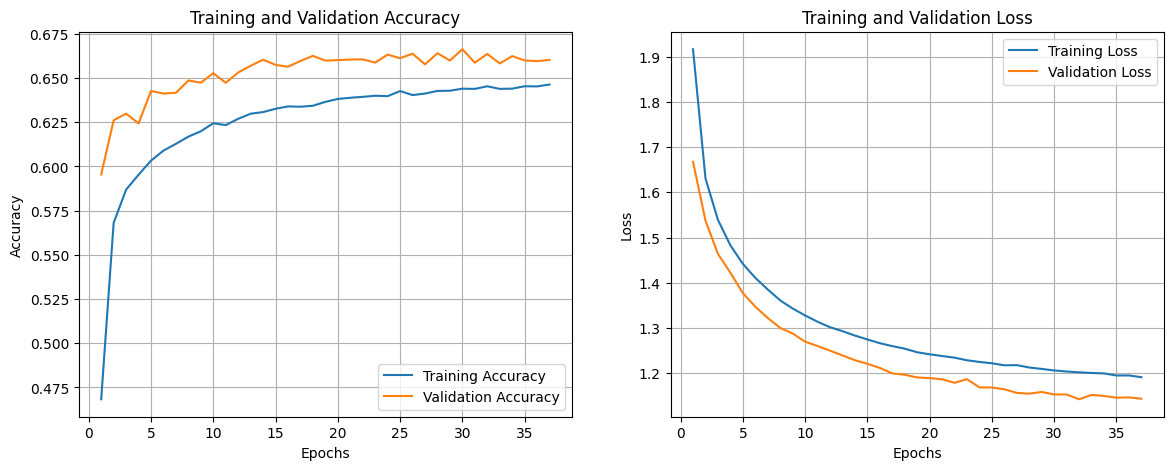


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.6636 (66.36%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.49      0.48      0.48      1843
  Computers & Internet       0.80      0.85      0.82      1842
 Education & Reference       0.56      0.38      0.45      1859
 Entertainment & Music       0.62      0.62      0.62      1859
Family & Relationships       0.65      0.73      0.69      1862
                Health       0.74      0.75      0.75      1868
 Politics & Government       0.71      0.74      0.72      1908
 Science & Mathematics       0.64      0.75      0.69      1858
     Society & Culture       0.57      0.51      0.54      1866
                Sports       0.81      0.81      0.81      1902

              accuracy                           0.66     18667
             macro avg       0.66      0.66      0.66     18667
          weighted avg       0.66      0.6

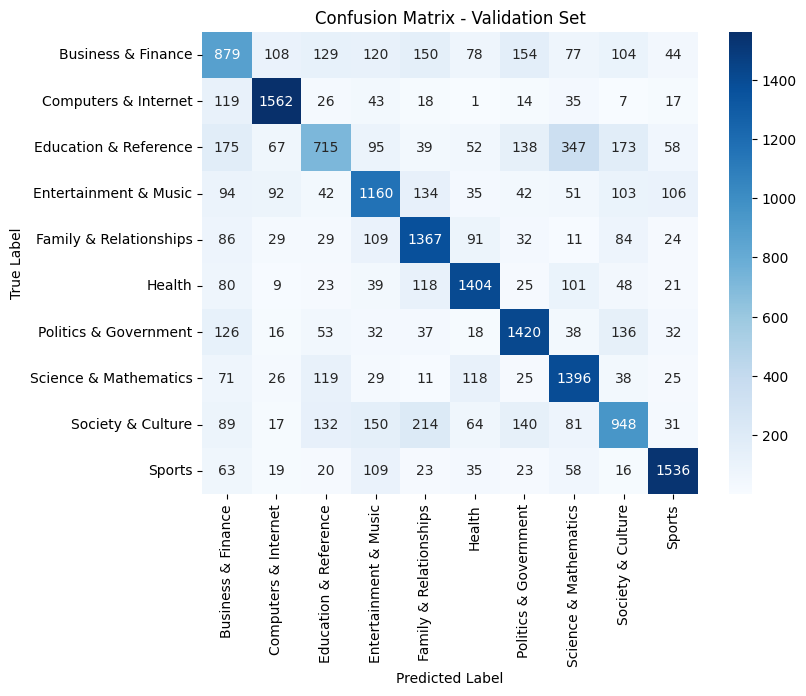


 Predicting on Test Set...
 Test Set ACCURACY: 0.6443 (64.43%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.41      0.50      0.45      6000
  Computers & Internet       0.79      0.82      0.80      6000
 Education & Reference       0.53      0.38      0.44      6000
 Entertainment & Music       0.60      0.61      0.61      6000
Family & Relationships       0.66      0.71      0.68      5999
                Health       0.74      0.74      0.74      6000
 Politics & Government       0.70      0.72      0.71      6000
 Science & Mathematics       0.64      0.72      0.68      6000
     Society & Culture       0.56      0.49      0.52      6000
                Sports       0.82      0.77      0.80      6000

              accuracy                           0.64     59999
             macro avg       0.65      0.64      0.64     59999
          weighted avg       0.65      0.64      0.64     59

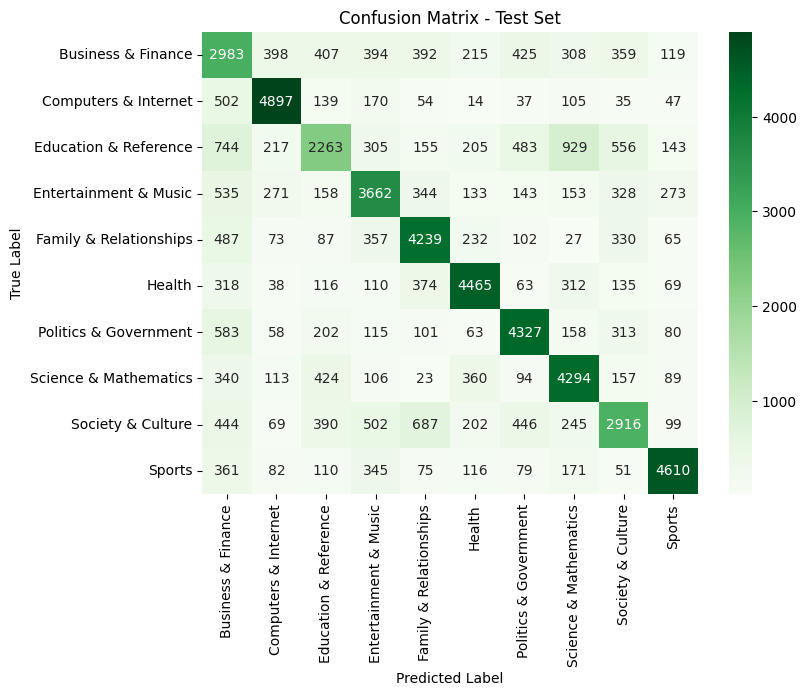

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,      # Using Padded Sequences
    y_val=y_val_enc,
    X_test=X_test_pad,    # Using Padded Sequences
    y_test=y_test_enc,
    class_names=list(le.classes_)
)

**RNN**
DO NOT RUN THESE CELLS

In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]      # e.g., 20000
EMBEDDING_DIM = embedding_matrix.shape[1]   # e.g., 100
NUM_CLASSES = 10  # Ensure this matches your actual number of label classes

model = Sequential([
    # Input Layer
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    # SimpleRNN Layer
    SimpleRNN(64, return_sequences=False),

    # Dense Layers
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

NUM_CLASSES = len(le.classes_)

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)
# --------------------------

print(f" Training with {NUM_CLASSES} classes...")

history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=15,
    batch_size=256,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop], # Now this variable exists
    verbose=1
)

 Training with 10 classes...
Epoch 1/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.2137 - loss: 2.1503 - val_accuracy: 0.3507 - val_loss: 1.8813
Epoch 2/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4020 - loss: 1.7690 - val_accuracy: 0.5249 - val_loss: 1.4587
Epoch 3/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4792 - loss: 1.5986 - val_accuracy: 0.4473 - val_loss: 1.6384
Epoch 4/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.4450 - loss: 1.6743 - val_accuracy: 0.5254 - val_loss: 1.4574
Epoch 5/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4994 - loss: 1.5607 - val_accuracy: 0.5403 - val_loss: 1.4142
Epoch 6/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.5214 - loss: 1.5222 - val_accuracy: 0.5537 - val_loss: 1.3868
Epoch 7/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.4826 - loss: 1.6038 - val_accuracy: 0.5287 - val_loss: 1.4324
Epoch 8/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.


 Plotting Training Curves...


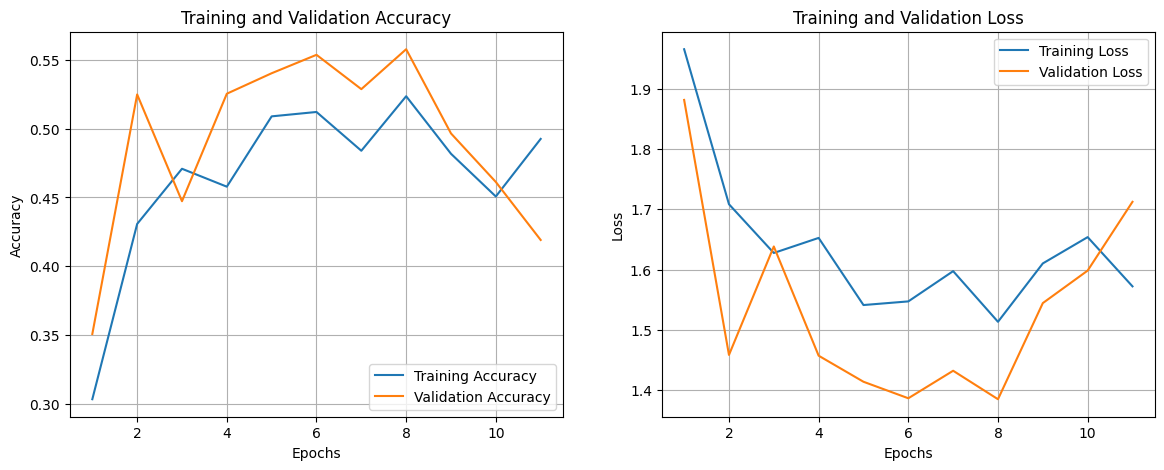


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.5578 (55.78%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.35      0.37      0.36      1843
  Computers & Internet       0.78      0.73      0.76      1842
 Education & Reference       0.34      0.09      0.15      1859
 Entertainment & Music       0.56      0.47      0.51      1859
Family & Relationships       0.46      0.71      0.55      1862
                Health       0.55      0.83      0.66      1868
 Politics & Government       0.51      0.72      0.60      1908
 Science & Mathematics       0.68      0.60      0.64      1858
     Society & Culture       0.50      0.29      0.37      1866
                Sports       0.81      0.75      0.78      1902

              accuracy                           0.56     18667
             macro avg       0.55      0.56      0.54     18667
          weighted avg       0.55      0.5

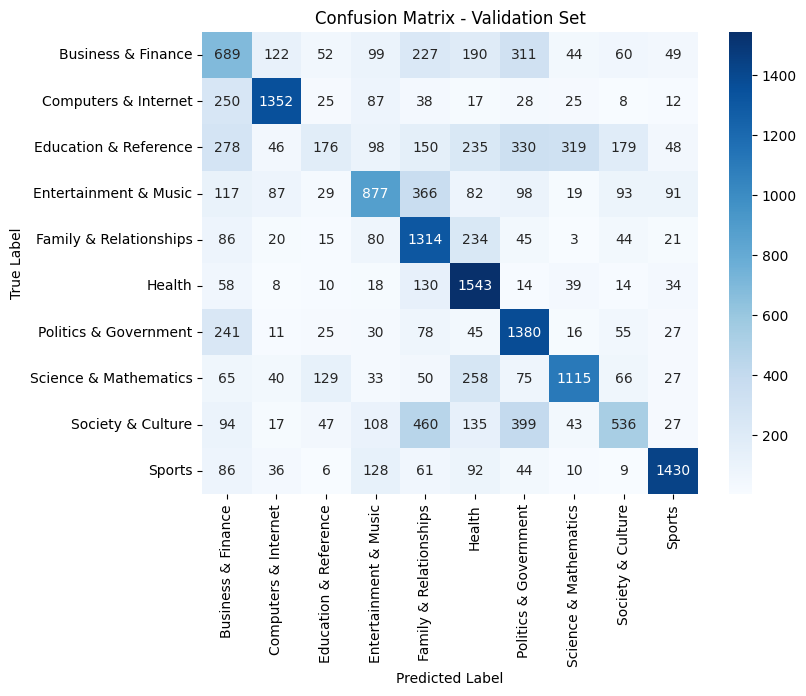


 Predicting on Test Set...
 Test Set ACCURACY: 0.5374 (53.74%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.32      0.38      0.35      6000
  Computers & Internet       0.79      0.70      0.74      6000
 Education & Reference       0.27      0.14      0.18      6000
 Entertainment & Music       0.58      0.41      0.48      6000
Family & Relationships       0.49      0.64      0.56      5999
                Health       0.53      0.82      0.64      6000
 Politics & Government       0.48      0.72      0.57      6000
 Science & Mathematics       0.68      0.58      0.62      6000
     Society & Culture       0.47      0.28      0.35      6000
                Sports       0.80      0.72      0.76      6000

              accuracy                           0.54     59999
             macro avg       0.54      0.54      0.52     59999
          weighted avg       0.54      0.54      0.52     59

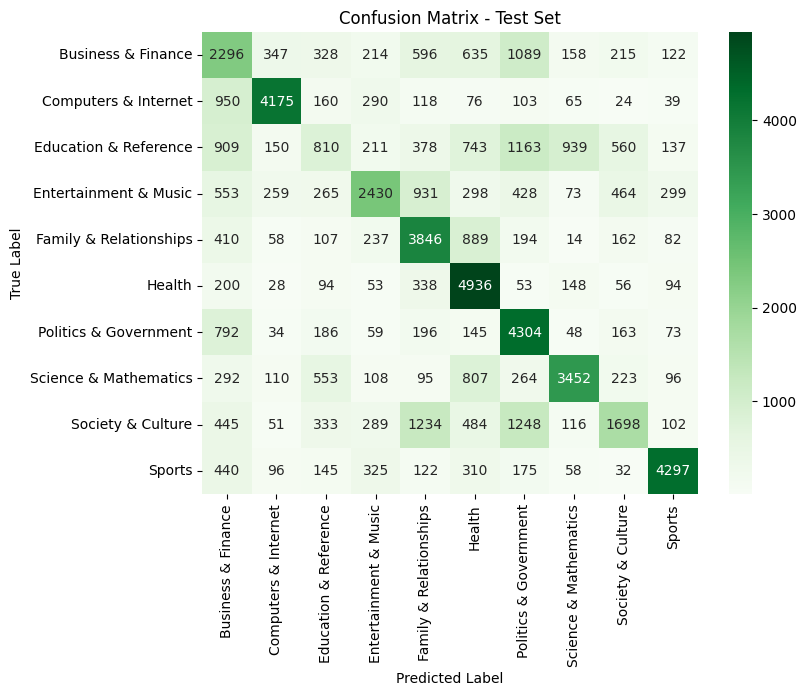

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)

In [ ]:
# ==========================================
#  HYPERPARAMETER CONFIGURATION (TUNE HERE)
# ==========================================
from tensorflow.keras.optimizers import Adam
RNN_UNITS = 128         # 32, 64, 128
DENSE_UNITS = 64        #  16, 32, 64
DROPOUT_RATE = 0.4      #  0.2, 0.3, 0.5
LEARNING_RATE = 0.001   #  0.01, 0.001, 0.0001
BATCH_SIZE = 512        #  32, 64, 128
EPOCHS = 10


# Data Constants (Do not tune these)
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# Define the Model using variables
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    # Tunable SimpleRNN Layer
    SimpleRNN(RNN_UNITS, return_sequences=False),

    # Tunable Dense Layer
    Dense(DENSE_UNITS, activation='relu'),

    # Tunable Dropout
    Dropout(DROPOUT_RATE),

    Dense(NUM_CLASSES, activation='softmax')
])


opt = Adam(learning_rate=LEARNING_RATE)

model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping (Keeps you from wasting time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print(f"Training with RNN={RNN_UNITS}, Dense={DENSE_UNITS}, LR={LEARNING_RATE}...")

history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

Training with RNN=128, Dense=64, LR=0.001...
Epoch 1/10
146/146 [==============================] - 19s 125ms/step - loss: 1.8243 - accuracy: 0.3660 - val_loss: 1.4475 - val_accuracy: 0.5165
Epoch 2/10
146/146 [==============================] - 18s 121ms/step - loss: 1.6376 - accuracy: 0.4521 - val_loss: 1.5680 - val_accuracy: 0.4749
Epoch 3/10
146/146 [==============================] - 18s 121ms/step - loss: 1.4740 - accuracy: 0.5233 - val_loss: 1.3570 - val_accuracy: 0.5580
Epoch 4/10
146/146 [==============================] - 18s 125ms/step - loss: 1.4234 - accuracy: 0.5507 - val_loss: 1.6423 - val_accuracy: 0.4368
Epoch 5/10
146/146 [==============================] - 18s 123ms/step - loss: 1.5432 - accuracy: 0.4954 - val_loss: 1.5428 - val_accuracy: 0.4727
Epoch 6/10
146/146 [==============================] - 18s 124ms/step - loss: 1.4730 - accuracy: 0.5203 - val_loss: 1.3511 - val_accuracy: 0.5569
Epoch 7/10
146/146 [==============================] - 18s 120ms/step - loss: 1.4191 -


 Plotting Training Curves...


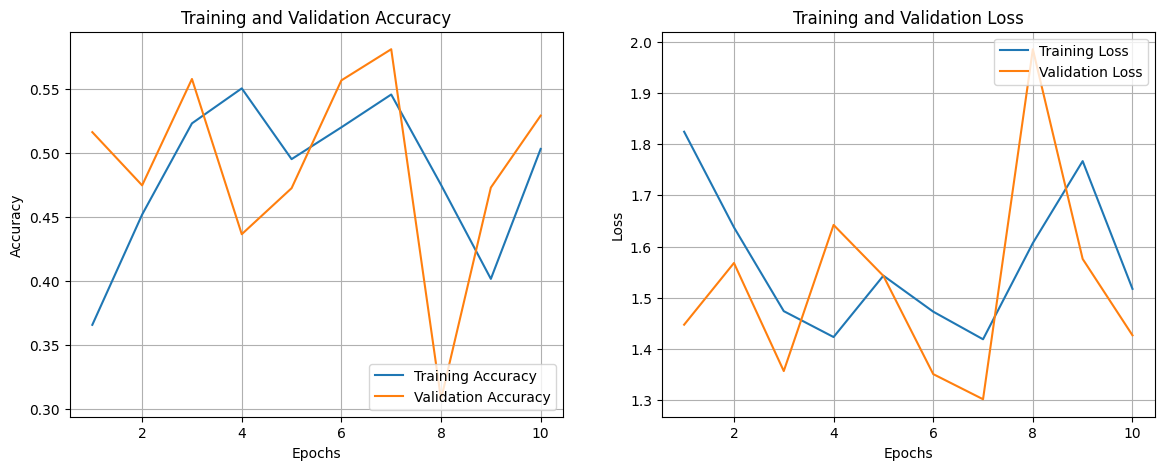


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.5812 (58.12%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.45      0.37      0.40      1843
  Computers & Internet       0.70      0.84      0.76      1842
 Education & Reference       0.35      0.17      0.23      1859
 Entertainment & Music       0.46      0.62      0.53      1859
Family & Relationships       0.60      0.69      0.64      1862
                Health       0.74      0.71      0.72      1868
 Politics & Government       0.50      0.68      0.58      1908
 Science & Mathematics       0.63      0.67      0.65      1858
     Society & Culture       0.48      0.32      0.38      1866
                Sports       0.78      0.75      0.77      1902

              accuracy                           0.58     18667
             macro avg       0.57      0.58      0.57     18667
          weighted avg       0.57      0.5

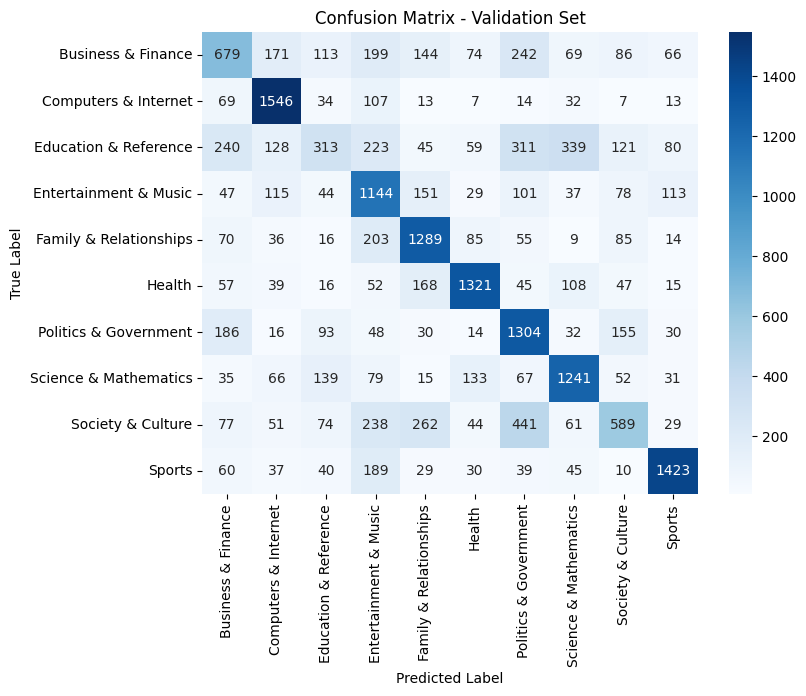


 Predicting on Test Set...
 Test Set ACCURACY: 0.5662 (56.62%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.47      0.33      0.39      6000
  Computers & Internet       0.70      0.81      0.76      6000
 Education & Reference       0.36      0.18      0.24      6000
 Entertainment & Music       0.40      0.65      0.50      6000
Family & Relationships       0.59      0.68      0.63      5999
                Health       0.74      0.69      0.71      6000
 Politics & Government       0.50      0.66      0.57      6000
 Science & Mathematics       0.62      0.65      0.64      6000
     Society & Culture       0.47      0.33      0.38      6000
                Sports       0.78      0.68      0.73      6000

              accuracy                           0.57     59999
             macro avg       0.56      0.57      0.55     59999
          weighted avg       0.56      0.57      0.55     59

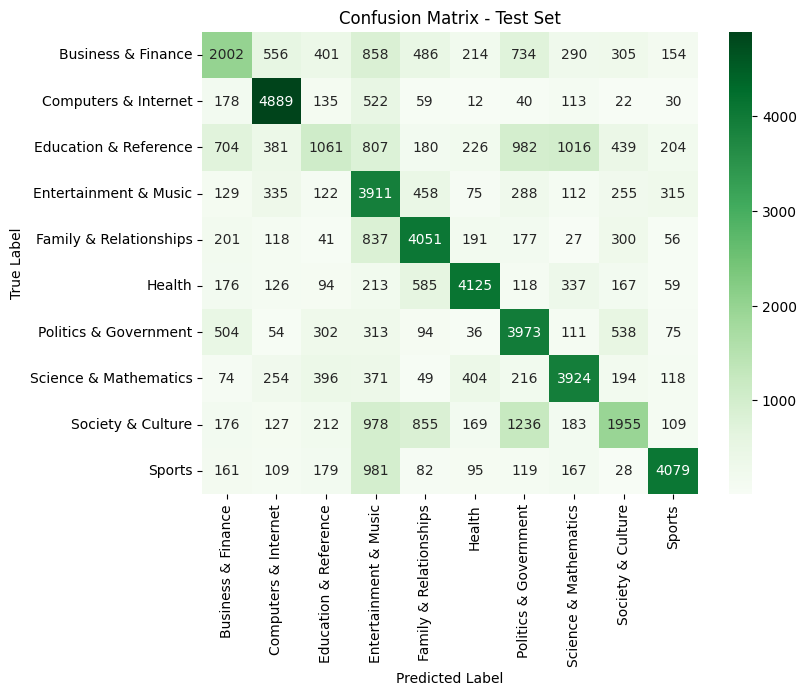

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)


In [ ]:
# ==========================================
#  HYPERPARAMETER CONFIGURATION (TUNE HERE)
# ==========================================
from tensorflow.keras.optimizers import Adam
RNN_UNITS = 64         # 32, 64, 128
DENSE_UNITS = 64       #  16, 32, 64
DROPOUT_RATE = 0.5      #  0.2, 0.3, 0.5
LEARNING_RATE = 0.01   #  0.01, 0.001, 0.0001
BATCH_SIZE = 512        #  32, 64, 128
EPOCHS = 10


# Data Constants (Do not tune these)
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# Define the Model using variables
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    # Tunable SimpleRNN Layer
    SimpleRNN(RNN_UNITS, return_sequences=False),

    # Tunable Dense Layer
    Dense(DENSE_UNITS, activation='relu'),

    # Tunable Dropout
    Dropout(DROPOUT_RATE),

    Dense(NUM_CLASSES, activation='softmax')
])


opt = Adam(learning_rate=LEARNING_RATE)

model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping (Keeps you from wasting time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print(f"Training with RNN={RNN_UNITS}, Dense={DENSE_UNITS}, LR={LEARNING_RATE}...")

history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

Training with RNN=64, Dense=64, LR=0.01...
Epoch 1/10
146/146 [==============================] - 21s 143ms/step - loss: 2.1171 - accuracy: 0.2378 - val_loss: 2.1115 - val_accuracy: 0.2218
Epoch 2/10
146/146 [==============================] - 20s 134ms/step - loss: 2.0667 - accuracy: 0.2463 - val_loss: 1.8761 - val_accuracy: 0.3373
Epoch 3/10
146/146 [==============================] - 20s 139ms/step - loss: 2.2422 - accuracy: 0.1568 - val_loss: 2.2576 - val_accuracy: 0.1675
Epoch 4/10
146/146 [==============================] - 19s 132ms/step - loss: 2.2420 - accuracy: 0.1550 - val_loss: 2.1718 - val_accuracy: 0.2162
Epoch 5/10
146/146 [==============================] - 20s 139ms/step - loss: 2.2975 - accuracy: 0.1067 - val_loss: 2.3026 - val_accuracy: 0.1019
Epoch 5: early stopping



 Plotting Training Curves...


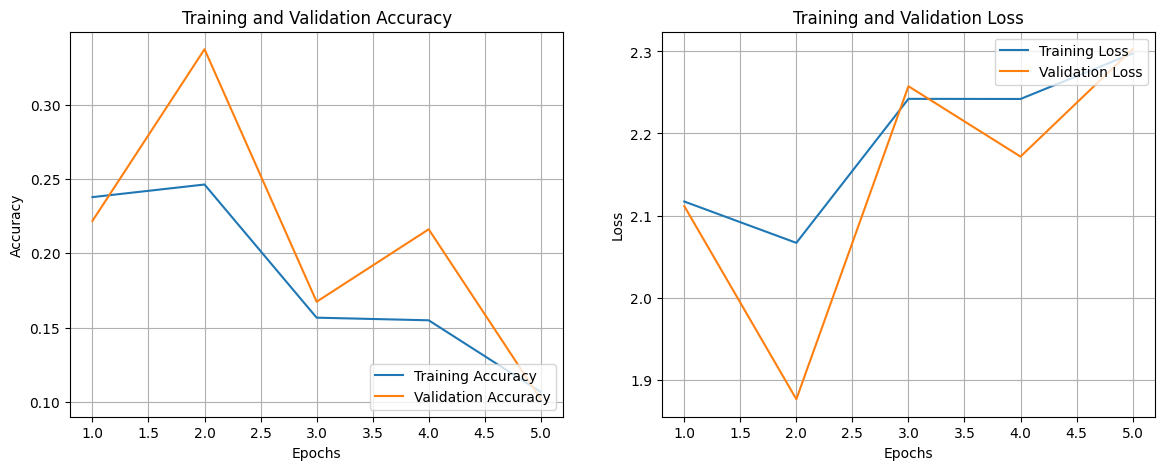


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.3373 (33.73%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.00      0.00      0.00      1843
  Computers & Internet       0.39      0.82      0.53      1842
 Education & Reference       0.16      0.13      0.15      1859
 Entertainment & Music       0.36      0.03      0.06      1859
Family & Relationships       0.31      0.12      0.17      1862
                Health       0.40      0.63      0.49      1868
 Politics & Government       0.23      0.44      0.30      1908
 Science & Mathematics       0.33      0.36      0.35      1858
     Society & Culture       0.24      0.22      0.23      1866
                Sports       0.58      0.61      0.60      1902

              accuracy                           0.34     18667
             macro avg       0.30      0.34      0.29     18667
          weighted avg       0.30      0.3

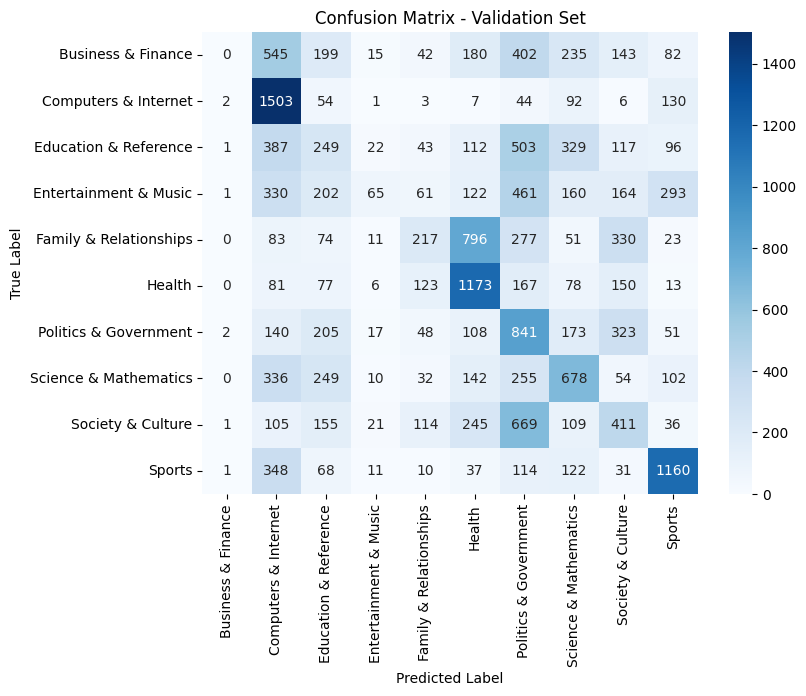


 Predicting on Test Set...
 Test Set ACCURACY: 0.3278 (32.78%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.26      0.00      0.00      6000
  Computers & Internet       0.40      0.79      0.53      6000
 Education & Reference       0.16      0.14      0.15      6000
 Entertainment & Music       0.38      0.04      0.08      6000
Family & Relationships       0.30      0.10      0.15      5999
                Health       0.44      0.58      0.50      6000
 Politics & Government       0.20      0.49      0.29      6000
 Science & Mathematics       0.34      0.37      0.35      6000
     Society & Culture       0.21      0.19      0.20      6000
                Sports       0.61      0.57      0.59      6000

              accuracy                           0.33     59999
             macro avg       0.33      0.33      0.28     59999
          weighted avg       0.33      0.33      0.28     59

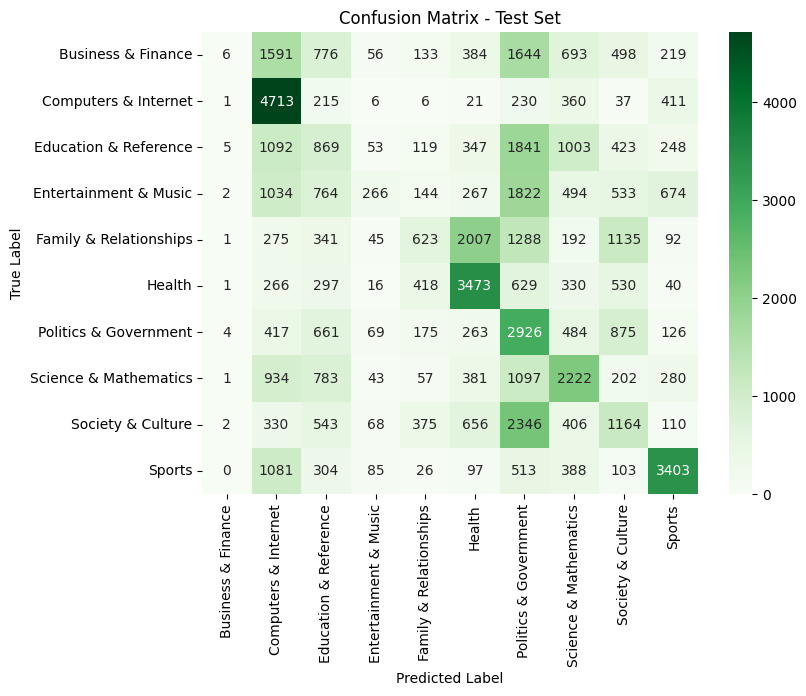

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)

In [ ]:
#Bidirectional Simple RNN

In [ ]:
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

RNN_UNITS = 64
DENSE_UNITS = 32
DROPOUT_RATE = 0.4
L2_STRENGTH = 0.01
BATCH_SIZE = 512
EPOCHS = 20
LEARNING_RATE = 0.001
# ==========================================

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    Bidirectional(SimpleRNN(RNN_UNITS, return_sequences=False)),


    Dense(DENSE_UNITS,
          activation='relu',
          kernel_regularizer=l2(L2_STRENGTH)), # <--- Penalizes large weights


    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile and Train (same as before)...
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop], verbose=1
)

Epoch 1/20
146/146 [==============================] - 35s 238ms/step - loss: 2.2294 - accuracy: 0.3017 - val_loss: 1.8418 - val_accuracy: 0.4097
Epoch 2/20
146/146 [==============================] - 35s 239ms/step - loss: 1.7105 - accuracy: 0.4660 - val_loss: 1.5179 - val_accuracy: 0.5241
Epoch 3/20
146/146 [==============================] - 35s 238ms/step - loss: 1.6002 - accuracy: 0.5041 - val_loss: 1.4428 - val_accuracy: 0.5517
Epoch 4/20
146/146 [==============================] - 35s 239ms/step - loss: 1.5350 - accuracy: 0.5307 - val_loss: 1.3973 - val_accuracy: 0.5721
Epoch 5/20
146/146 [==============================] - 33s 228ms/step - loss: 1.5417 - accuracy: 0.5302 - val_loss: 1.3810 - val_accuracy: 0.5777
Epoch 6/20
146/146 [==============================] - 34s 232ms/step - loss: 1.6318 - accuracy: 0.4868 - val_loss: 1.6102 - val_accuracy: 0.4798
Epoch 7/20
146/146 [==============================] - 35s 237ms/step - loss: 1.9172 - accuracy: 0.3533 - val_loss: 1.7195 - val_ac


 Plotting Training Curves...


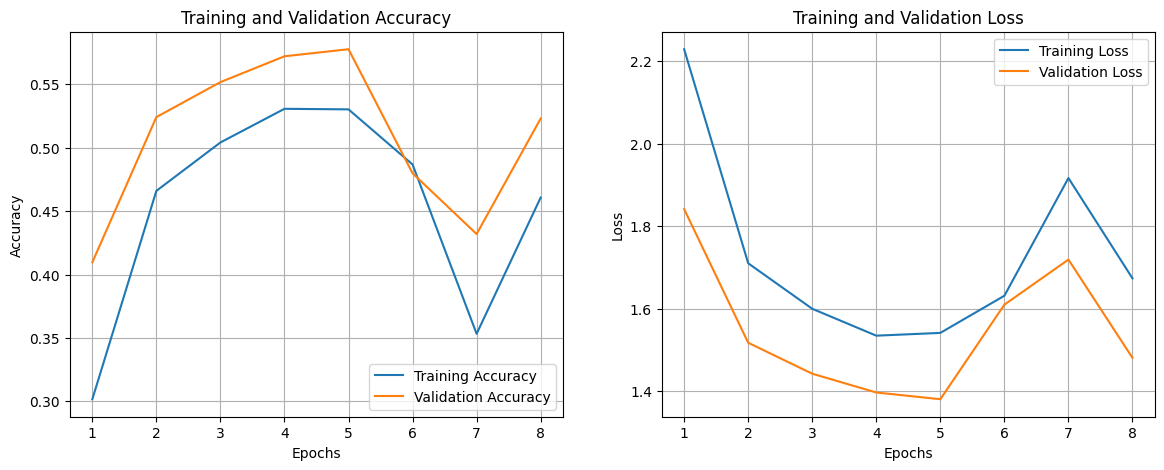


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.5774 (57.74%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.51      0.29      0.37      1843
  Computers & Internet       0.74      0.83      0.79      1842
 Education & Reference       0.41      0.15      0.21      1859
 Entertainment & Music       0.37      0.62      0.47      1859
Family & Relationships       0.50      0.75      0.60      1862
                Health       0.74      0.69      0.72      1868
 Politics & Government       0.62      0.66      0.64      1908
 Science & Mathematics       0.63      0.67      0.65      1858
     Society & Culture       0.47      0.35      0.40      1866
                Sports       0.75      0.76      0.75      1902

              accuracy                           0.58     18667
             macro avg       0.58      0.58      0.56     18667
          weighted avg       0.58      0.5

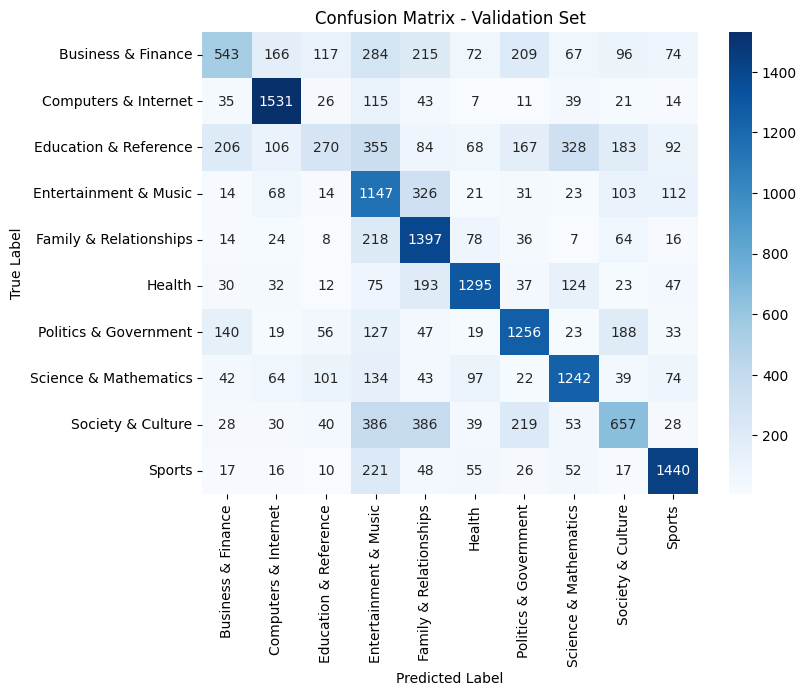


 Predicting on Test Set...
 Test Set ACCURACY: 0.5531 (55.31%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.50      0.27      0.35      6000
  Computers & Internet       0.74      0.79      0.76      6000
 Education & Reference       0.39      0.15      0.22      6000
 Entertainment & Music       0.32      0.68      0.43      6000
Family & Relationships       0.52      0.70      0.60      5999
                Health       0.76      0.64      0.70      6000
 Politics & Government       0.63      0.59      0.61      6000
 Science & Mathematics       0.63      0.66      0.64      6000
     Society & Culture       0.44      0.32      0.37      6000
                Sports       0.74      0.73      0.73      6000

              accuracy                           0.55     59999
             macro avg       0.57      0.55      0.54     59999
          weighted avg       0.57      0.55      0.54     59

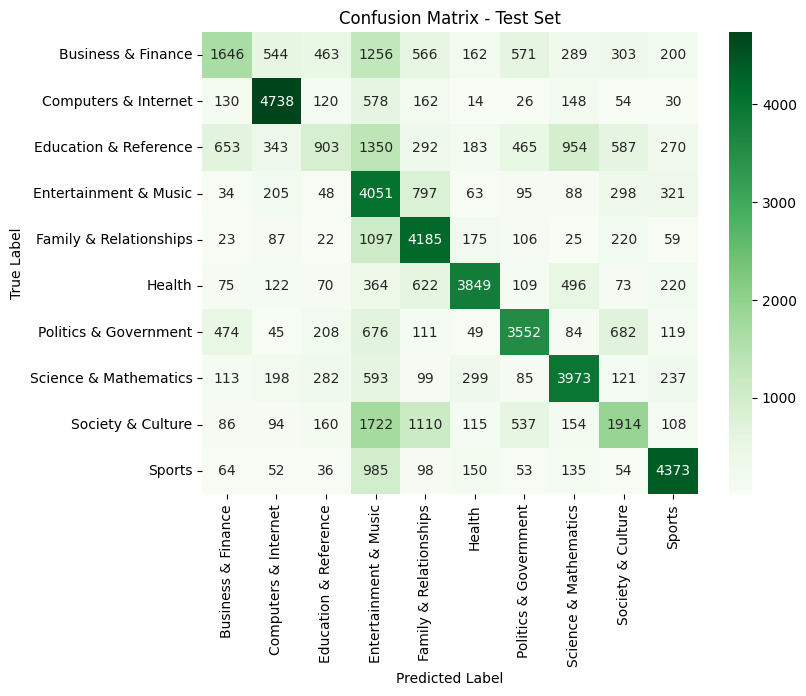

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)


In [ ]:
RNN_UNITS = 32          # 32 is safer for 2 layers (Output = 64)
DENSE_UNITS = 32
DROPOUT_RATE = 0.4      # Slightly lower dropout since we have L2
L2_STRENGTH = 0.01      # Regularization strength
BATCH_SIZE = 512        # Optimized for RTX 4070
EPOCHS = 20
LEARNING_RATE = 0.001
# ==========================================

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    # --- LAYER 1: Bidirectional Wrapper ---
    # MUST have return_sequences=True to feed Layer 2
    Bidirectional(SimpleRNN(RNN_UNITS, return_sequences=True)),

    # --- LAYER 2: Bidirectional Wrapper ---
    # return_sequences=False to feed the Dense layer
    Bidirectional(SimpleRNN(RNN_UNITS, return_sequences=False)),

    # Dense Layer with L2 Regularization
    Dense(DENSE_UNITS,
          activation='relu',
          kernel_regularizer=l2(L2_STRENGTH)), # Helps prevent jagged loss spikes

    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile
opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

print(f" Training 2-Layer Bidirectional RNN with L2 Regularization...")

history = model.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1)

 Training 2-Layer Bidirectional RNN with L2 Regularization...
Epoch 1/20
146/146 [==============================] - 80s 539ms/step - loss: 2.2833 - accuracy: 0.2705 - val_loss: 1.8289 - val_accuracy: 0.4487
Epoch 2/20
146/146 [==============================] - 79s 543ms/step - loss: 1.8070 - accuracy: 0.4410 - val_loss: 1.6011 - val_accuracy: 0.5058
Epoch 3/20
146/146 [==============================] - 80s 549ms/step - loss: 1.6619 - accuracy: 0.4870 - val_loss: 1.6598 - val_accuracy: 0.4729
Epoch 4/20
146/146 [==============================] - 80s 549ms/step - loss: 1.6695 - accuracy: 0.4719 - val_loss: 1.5810 - val_accuracy: 0.4961
Epoch 5/20
146/146 [==============================] - 81s 553ms/step - loss: 1.6323 - accuracy: 0.4844 - val_loss: 1.4773 - val_accuracy: 0.5363
Epoch 6/20
146/146 [==============================] - 78s 536ms/step - loss: 1.5311 - accuracy: 0.5296 - val_loss: 1.4528 - val_accuracy: 0.5392
Epoch 7/20
146/146 [==============================] - 78s 535ms/step


 Plotting Training Curves...


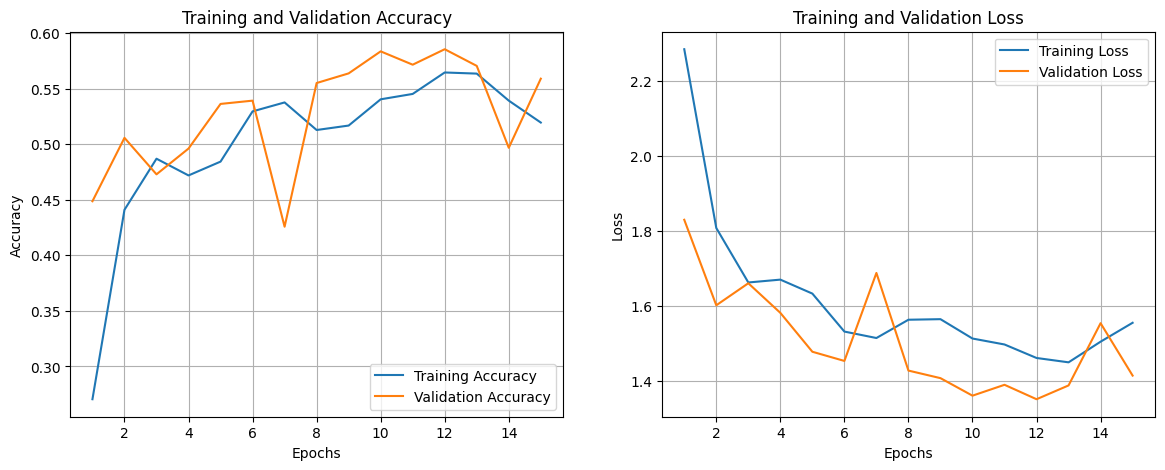


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.5855 (58.55%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.37      0.37      0.37      1843
  Computers & Internet       0.67      0.86      0.75      1842
 Education & Reference       0.40      0.14      0.21      1859
 Entertainment & Music       0.58      0.52      0.55      1859
Family & Relationships       0.57      0.73      0.64      1862
                Health       0.70      0.69      0.70      1868
 Politics & Government       0.57      0.71      0.63      1908
 Science & Mathematics       0.57      0.69      0.62      1858
     Society & Culture       0.48      0.42      0.45      1866
                Sports       0.79      0.73      0.76      1902

              accuracy                           0.59     18667
             macro avg       0.57      0.58      0.57     18667
          weighted avg       0.57      0.5

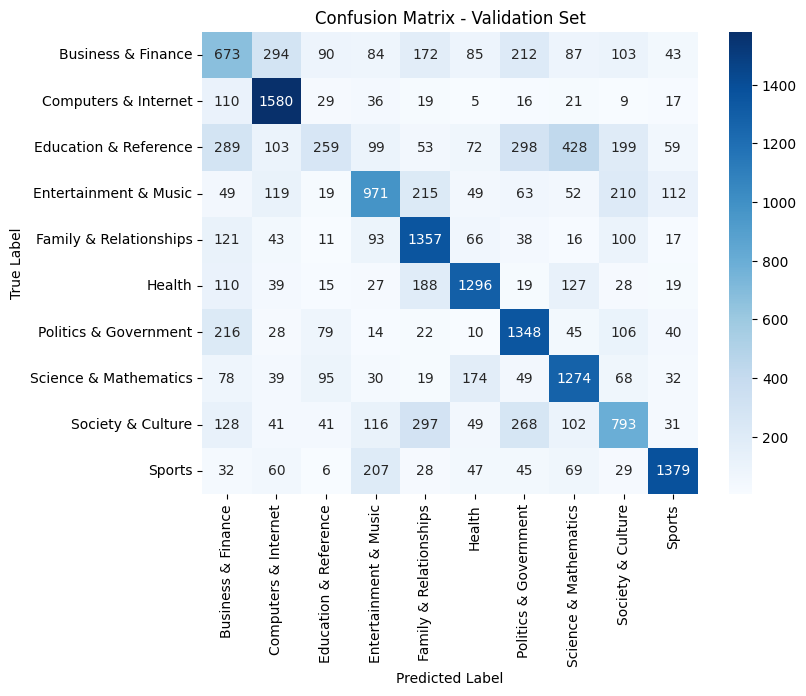


 Predicting on Test Set...
 Test Set ACCURACY: 0.5670 (56.70%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.37      0.38      0.37      6000
  Computers & Internet       0.66      0.83      0.74      6000
 Education & Reference       0.34      0.15      0.21      6000
 Entertainment & Music       0.54      0.53      0.53      6000
Family & Relationships       0.56      0.71      0.62      5999
                Health       0.65      0.70      0.68      6000
 Politics & Government       0.57      0.67      0.61      6000
 Science & Mathematics       0.56      0.65      0.60      6000
     Society & Culture       0.48      0.40      0.44      6000
                Sports       0.83      0.65      0.73      6000

              accuracy                           0.57     59999
             macro avg       0.56      0.57      0.55     59999
          weighted avg       0.56      0.57      0.55     59

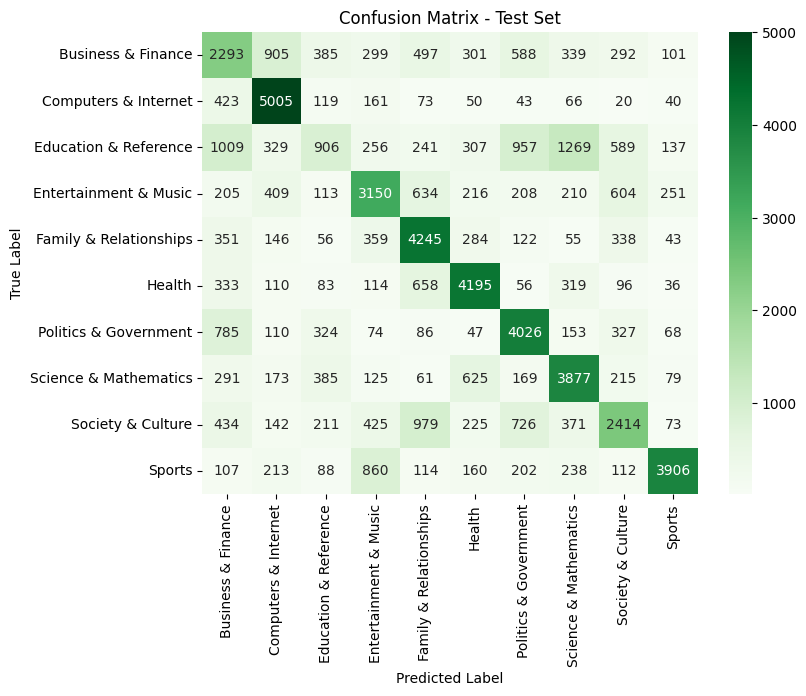

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)


In [ ]:

RNN_UNITS = 32
DENSE_UNITS = 32
DROPOUT_RATE = 0.4      # Lowered slightly because we added L2
L2_STRENGTH = 0.01      # Try 0.01 or 0.001
BATCH_SIZE = 512
EPOCHS = 20
LEARNING_RATE = 0.001
# ==========================================

model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    Bidirectional(SimpleRNN(RNN_UNITS, return_sequences=False)),

    # --- ADDED L2 HERE ---
    Dense(DENSE_UNITS,
          activation='relu',
          kernel_regularizer=l2(L2_STRENGTH)), # <--- Penalizes large weights
    # ---------------------

    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])


opt = Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)

history = model.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop], verbose=1
)

Epoch 1/20
146/146 [==============================] - 37s 250ms/step - loss: 2.3391 - accuracy: 0.2364 - val_loss: 1.9412 - val_accuracy: 0.3977
Epoch 2/20
146/146 [==============================] - 37s 252ms/step - loss: 1.8947 - accuracy: 0.3921 - val_loss: 1.7263 - val_accuracy: 0.4578
Epoch 3/20
146/146 [==============================] - 37s 254ms/step - loss: 1.7227 - accuracy: 0.4553 - val_loss: 1.5415 - val_accuracy: 0.5198
Epoch 4/20
146/146 [==============================] - 37s 253ms/step - loss: 1.6319 - accuracy: 0.4913 - val_loss: 1.5263 - val_accuracy: 0.5225
Epoch 5/20
146/146 [==============================] - 37s 253ms/step - loss: 1.6563 - accuracy: 0.4772 - val_loss: 1.6193 - val_accuracy: 0.4814
Epoch 6/20
146/146 [==============================] - 36s 250ms/step - loss: 1.6350 - accuracy: 0.4832 - val_loss: 1.5150 - val_accuracy: 0.5183
Epoch 7/20
146/146 [==============================] - 37s 254ms/step - loss: 1.5727 - accuracy: 0.5134 - val_loss: 1.4663 - val_ac


 Plotting Training Curves...


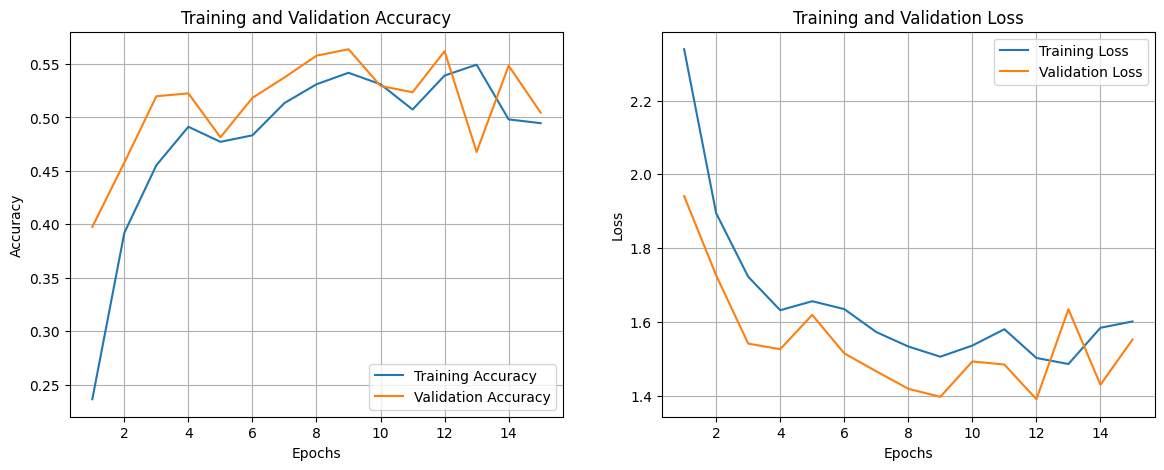


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.5620 (56.20%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.53      0.36      0.43      1843
  Computers & Internet       0.71      0.86      0.78      1842
 Education & Reference       0.28      0.07      0.11      1859
 Entertainment & Music       0.49      0.46      0.48      1859
Family & Relationships       0.52      0.71      0.60      1862
                Health       0.64      0.69      0.67      1868
 Politics & Government       0.54      0.73      0.62      1908
 Science & Mathematics       0.50      0.72      0.59      1858
     Society & Culture       0.45      0.27      0.34      1866
                Sports       0.69      0.75      0.72      1902

              accuracy                           0.56     18667
             macro avg       0.53      0.56      0.53     18667
          weighted avg       0.54      0.5

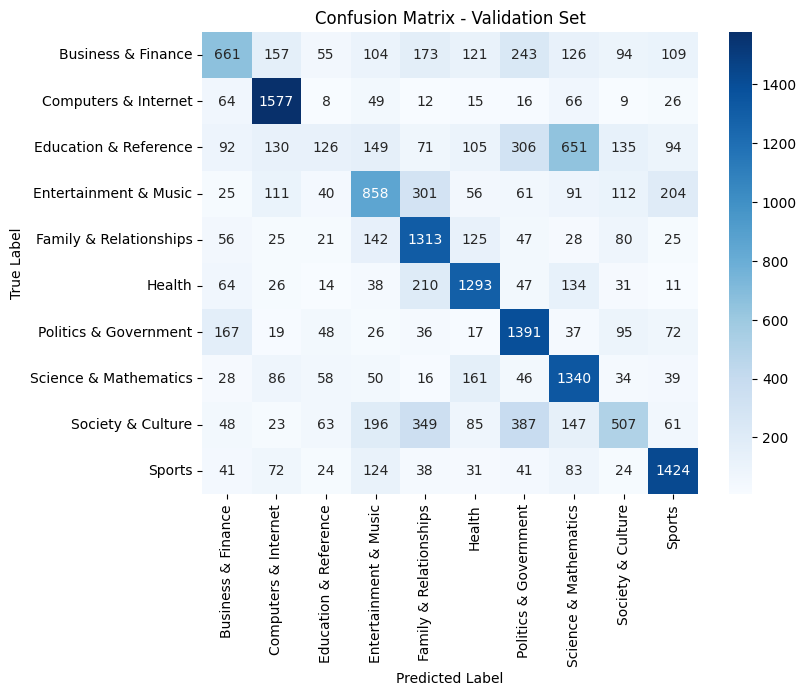


 Predicting on Test Set...
 Test Set ACCURACY: 0.5459 (54.59%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.54      0.35      0.42      6000
  Computers & Internet       0.67      0.83      0.74      6000
 Education & Reference       0.24      0.09      0.13      6000
 Entertainment & Music       0.48      0.49      0.48      6000
Family & Relationships       0.52      0.69      0.59      5999
                Health       0.63      0.68      0.65      6000
 Politics & Government       0.54      0.71      0.61      6000
 Science & Mathematics       0.47      0.70      0.56      6000
     Society & Culture       0.45      0.26      0.33      6000
                Sports       0.73      0.68      0.70      6000

              accuracy                           0.55     59999
             macro avg       0.52      0.55      0.52     59999
          weighted avg       0.52      0.55      0.52     59

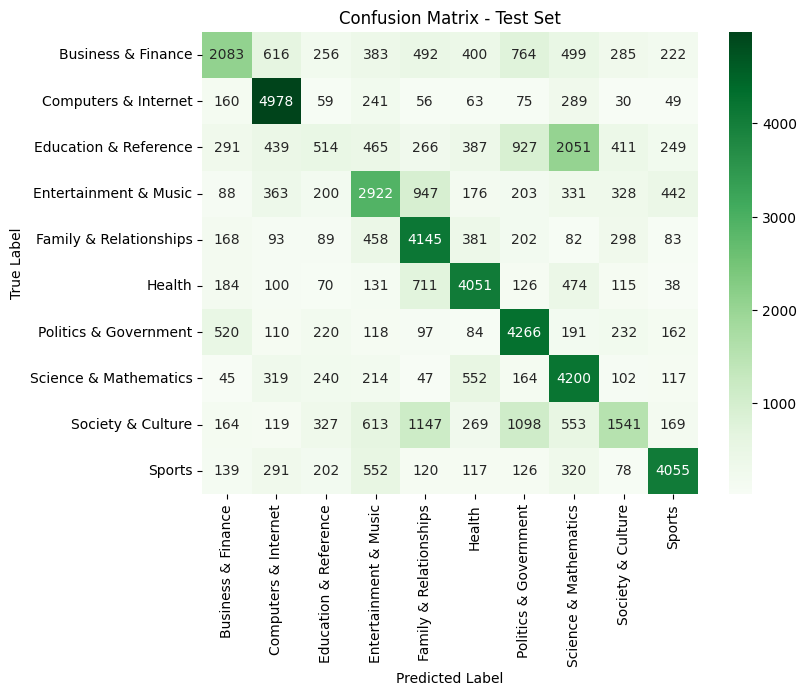

In [ ]:
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,    # Your processed test features
    y_test=y_test_enc,    # Your processed test labels
    class_names=list(le.classes_) # Your list of label names
)


In [ ]:
################################################

In [ ]:
################################################

## **GRU**

Epoch 1/30
292/292 [==============================] - 4s 12ms/step - loss: 1.6286 - accuracy: 0.4530 - val_loss: 1.1245 - val_accuracy: 0.6540
Epoch 2/30
292/292 [==============================] - 3s 10ms/step - loss: 1.2437 - accuracy: 0.6144 - val_loss: 1.0447 - val_accuracy: 0.6705
Epoch 3/30
292/292 [==============================] - 3s 10ms/step - loss: 1.1798 - accuracy: 0.6397 - val_loss: 1.0113 - val_accuracy: 0.6802
Epoch 4/30
292/292 [==============================] - 3s 10ms/step - loss: 1.1516 - accuracy: 0.6499 - val_loss: 0.9982 - val_accuracy: 0.6852
Epoch 5/30
292/292 [==============================] - 3s 11ms/step - loss: 1.1290 - accuracy: 0.6565 - val_loss: 0.9857 - val_accuracy: 0.6884
Epoch 6/30
292/292 [==============================] - 3s 11ms/step - loss: 1.1147 - accuracy: 0.6593 - val_loss: 0.9769 - val_accuracy: 0.6919
Epoch 7/30
292/292 [==============================] - 3s 11ms/step - loss: 1.1041 - accuracy: 0.6657 - val_loss: 0.9827 - val_accuracy: 0.6885

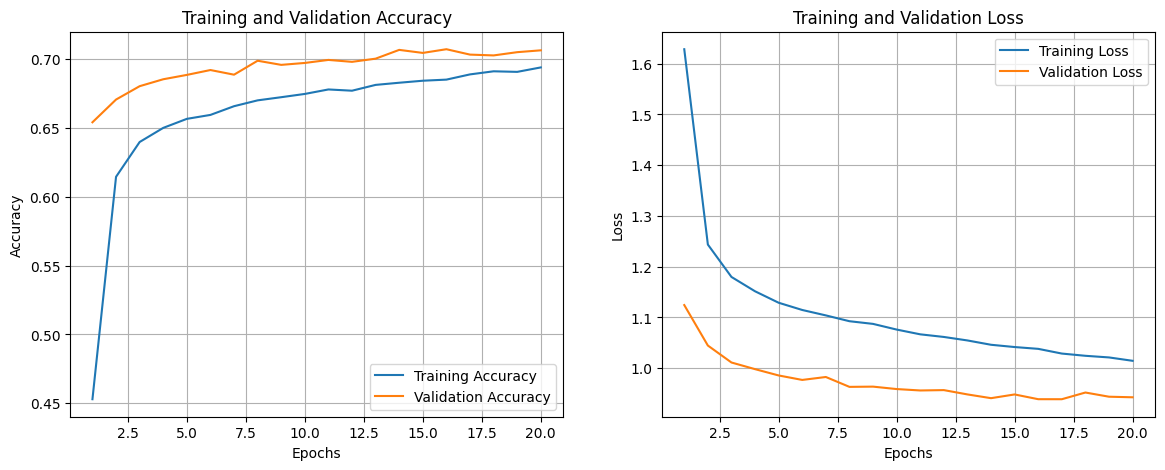


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7031 (70.31%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.66      0.47      0.55      1843
  Computers & Internet       0.83      0.88      0.85      1842
 Education & Reference       0.61      0.42      0.50      1859
 Entertainment & Music       0.69      0.66      0.67      1859
Family & Relationships       0.66      0.79      0.72      1862
                Health       0.72      0.82      0.77      1868
 Politics & Government       0.72      0.80      0.76      1908
 Science & Mathematics       0.68      0.76      0.72      1858
     Society & Culture       0.56      0.58      0.57      1866
                Sports       0.87      0.84      0.86      1902

              accuracy                           0.70     18667
             macro avg       0.70      0.70      0.70     18667
          weighted avg       0.70      0.7

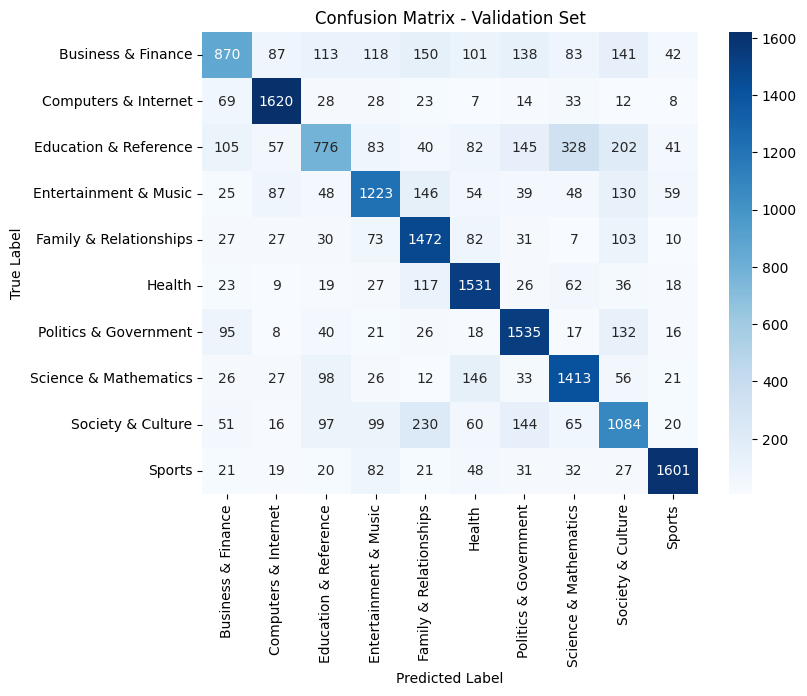


 Predicting on Test Set...
 Test Set ACCURACY: 0.6807 (68.07%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.66      0.45      0.53      6000
  Computers & Internet       0.80      0.84      0.82      6000
 Education & Reference       0.56      0.42      0.48      6000
 Entertainment & Music       0.63      0.66      0.65      6000
Family & Relationships       0.66      0.74      0.70      5999
                Health       0.70      0.81      0.75      6000
 Politics & Government       0.70      0.78      0.74      6000
 Science & Mathematics       0.66      0.75      0.70      6000
     Society & Culture       0.55      0.56      0.56      6000
                Sports       0.85      0.81      0.83      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.67     59999
          weighted avg       0.68      0.68      0.67     59

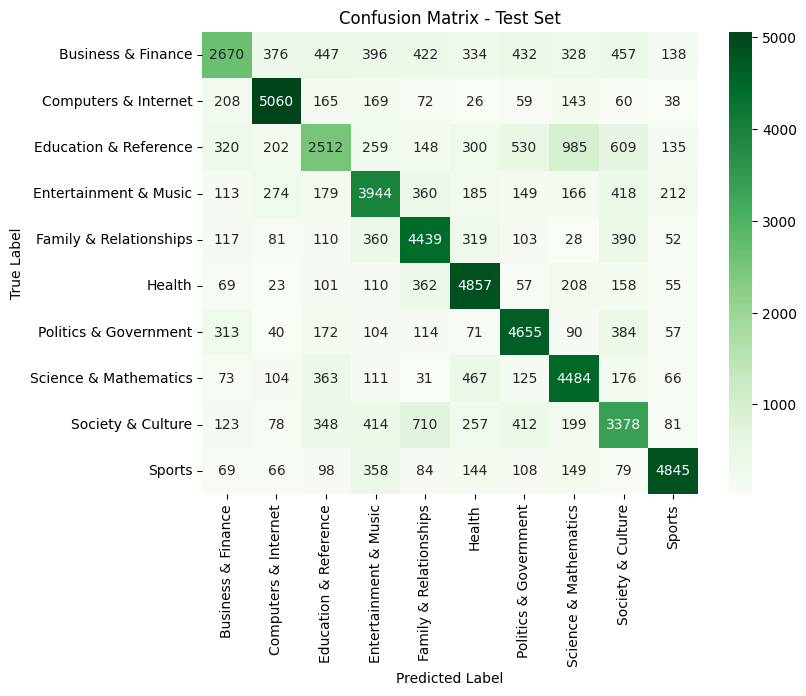

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------
# define constants
# ----------------------------
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# ----------------------------
# build GRU model
# ----------------------------
model = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              trainable=False),

    GRU(64, return_sequences=False),  # GRU layer, units=64

    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ----------------------------
# compile model
# ----------------------------
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# early stopping
# ----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# ----------------------------
# train model
# ----------------------------
history = model.fit(
    X_train_pad, y_train_enc,
    epochs=30,
    batch_size=256,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

# ----------------------------
# evaluate model
# ----------------------------
evaluate_keras_model(
    model=model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)


### Bi-Directional GRU

Epoch 1/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - accuracy: 0.3182 - loss: 1.9307 - val_accuracy: 0.6531 - val_loss: 1.1283
Epoch 2/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6199 - loss: 1.2479 - val_accuracy: 0.6766 - val_loss: 1.0279
Epoch 3/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6438 - loss: 1.1740 - val_accuracy: 0.6855 - val_loss: 1.0080
Epoch 4/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6575 - loss: 1.1343 - val_accuracy: 0.6893 - val_loss: 0.9881
Epoch 5/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6617 - loss: 1.1130 - val_accuracy: 0.6885 - val_loss: 0.9863
Epoch 6/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6699 - loss: 1.0940 - val_accuracy: 0.6952 - val_loss: 0.9690
Epoch 7/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.6692 - loss: 1.0895 - val_accuracy: 0.6980 - val_loss: 0.9654
Epoch 8/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6747 - loss: 1.0820 - val_acc

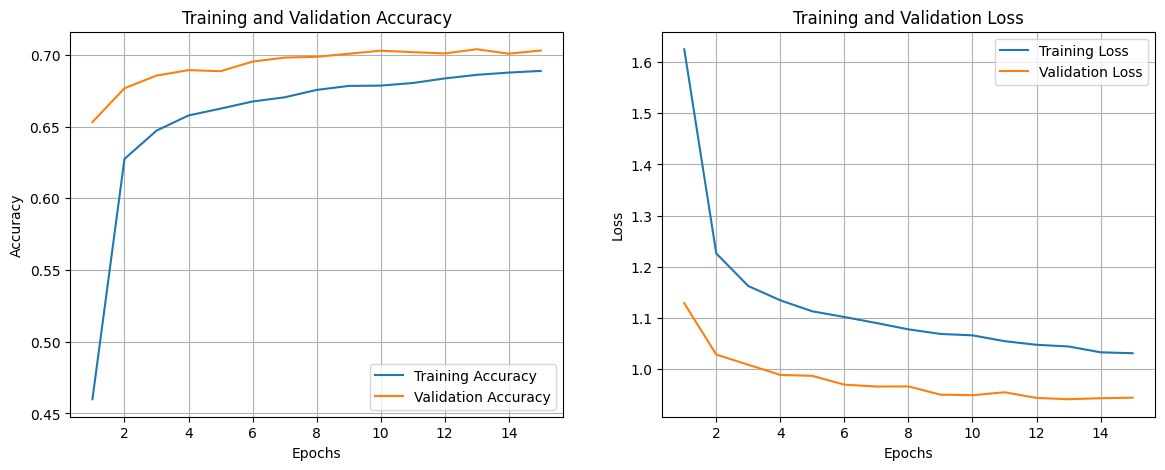


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7039 (70.39%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.45      0.54      1843
  Computers & Internet       0.81      0.89      0.85      1842
 Education & Reference       0.61      0.43      0.50      1859
 Entertainment & Music       0.61      0.71      0.66      1859
Family & Relationships       0.68      0.77      0.72      1862
                Health       0.76      0.79      0.77      1868
 Politics & Government       0.72      0.82      0.77      1908
 Science & Mathematics       0.68      0.77      0.72      1858
     Society & Culture       0.61      0.53      0.57      1866
                Sports       0.83      0.87      0.85      1902

              accuracy                           0.70     18667
             macro avg       0.70      0.70      0.70     18667
          weighted avg       0.70      0.7

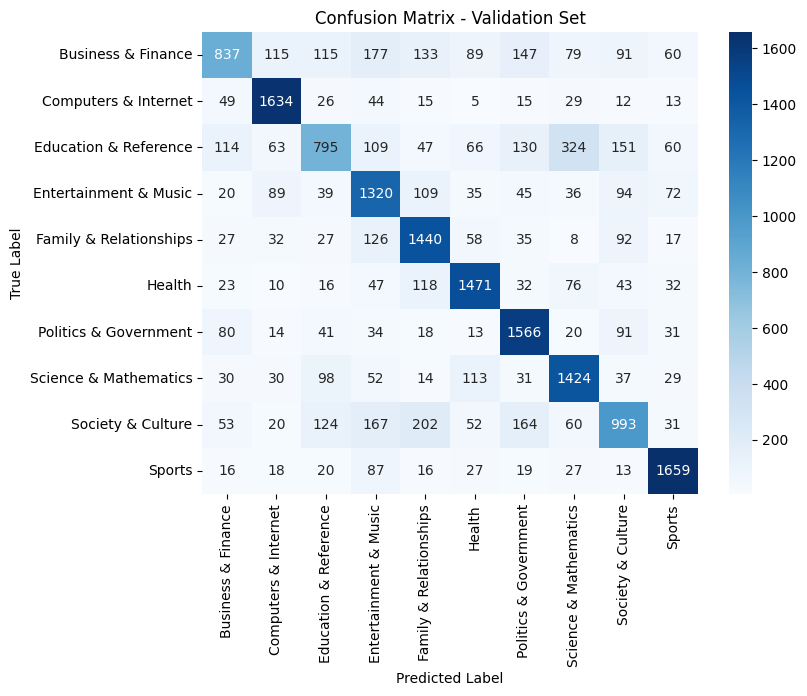


 Predicting on Test Set...
 Test Set ACCURACY: 0.6780 (67.80%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.65      0.43      0.52      6000
  Computers & Internet       0.78      0.86      0.82      6000
 Education & Reference       0.57      0.42      0.48      6000
 Entertainment & Music       0.54      0.72      0.62      6000
Family & Relationships       0.68      0.73      0.70      5999
                Health       0.75      0.76      0.76      6000
 Politics & Government       0.70      0.77      0.74      6000
 Science & Mathematics       0.66      0.75      0.70      6000
     Society & Culture       0.63      0.50      0.56      6000
                Sports       0.79      0.84      0.82      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.67     59999
          weighted avg       0.68      0.68      0.67     59

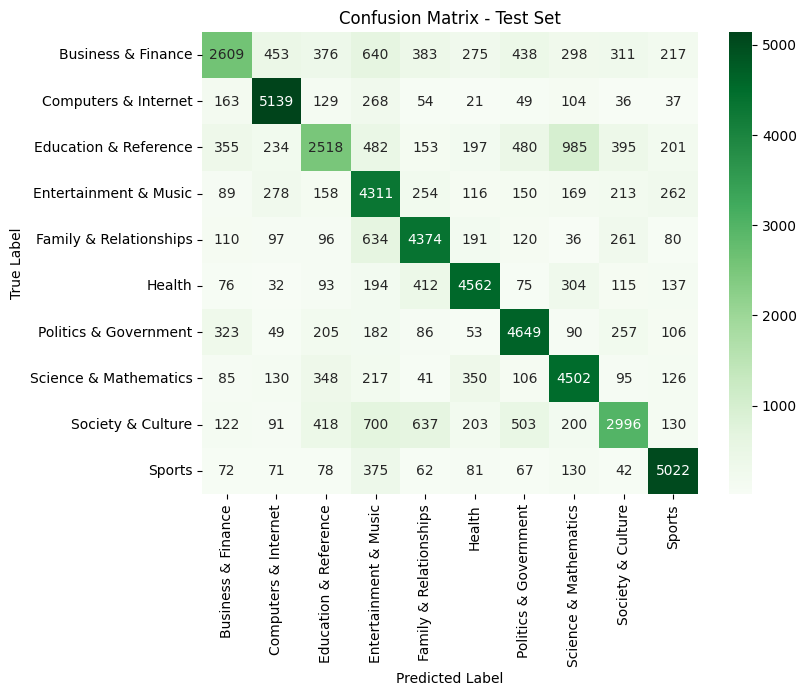

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ----------------------------
# define constants
# ----------------------------
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# ----------------------------
# build Bidirectional GRU model
# ----------------------------
model_bi_gru = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    # Bidirectional GRU layer
    Bidirectional(GRU(64, return_sequences=False)),

    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

# ----------------------------
# compile model
# ----------------------------
model_bi_gru.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# ----------------------------
# early stopping
# ----------------------------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# ----------------------------
# train model
# ----------------------------
history_bi_gru = model_bi_gru.fit(
    X_train_pad, y_train_enc,
    epochs=15,
    batch_size=256,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

# ----------------------------
# evaluate model
# ----------------------------
evaluate_keras_model(
    model=model_bi_gru,
    history=history_bi_gru,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)


# hyperparameter tuning for gru

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 128)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,097,226 (8.00 MB)

 Trainable params: 97,226 (379.79 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.4426 - loss: 1.6540 - val_accuracy: 0.6663 - val_loss: 1.0425
Epoch 2/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.6653 - loss: 1.0732 - val_accuracy: 0.6893 - val_loss: 0.9756
Epoch 3/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6811 - loss: 1.0300 - val_accuracy: 0.6955 - val_loss: 0.9543
Epoch 4/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6873 - loss: 0.9963 - val_accuracy: 0.6971 - val_loss: 0.9446
Epoch 5/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.6916 - loss: 0.9854 - val_accuracy: 0.7004 - val_loss: 0.9313
Epoch 6/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.6949 - loss: 0.9739 - val_accuracy: 0.6996 - val_loss: 0.9305
Epoch 7/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7029 - loss: 0.9520 - val_accuracy: 0.7028 - val_loss: 0.9217
Epoch 8/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7062 - loss: 0.9411 - val_acc

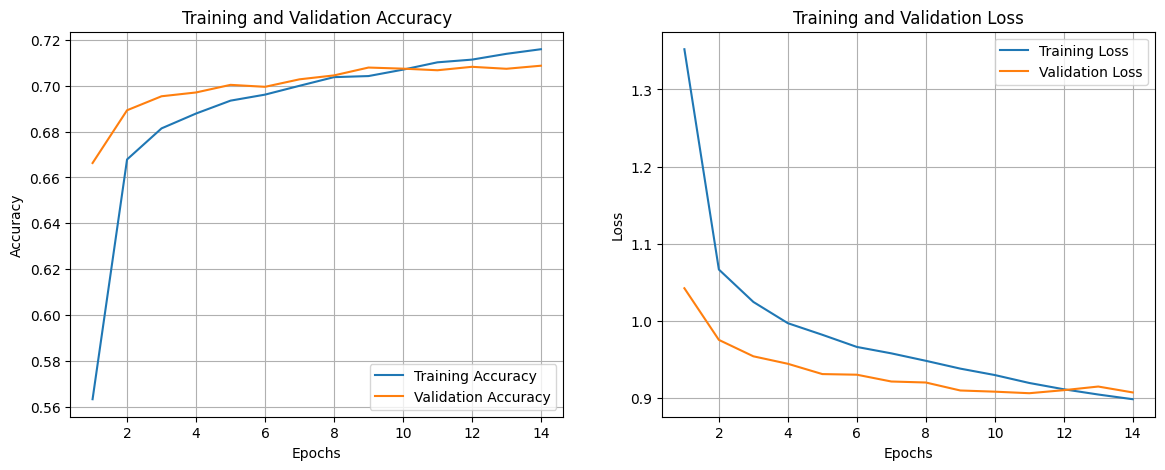


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7068 (70.68%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.46      0.54      1843
  Computers & Internet       0.84      0.86      0.85      1842
 Education & Reference       0.61      0.44      0.51      1859
 Entertainment & Music       0.61      0.73      0.67      1859
Family & Relationships       0.69      0.77      0.73      1862
                Health       0.72      0.82      0.77      1868
 Politics & Government       0.74      0.80      0.77      1908
 Science & Mathematics       0.71      0.74      0.72      1858
     Society & Culture       0.59      0.58      0.58      1866
                Sports       0.85      0.87      0.86      1902

              accuracy                           0.71     18667
             macro avg       0.70      0.71      0.70     18667
          weighted avg       0.70      0.7

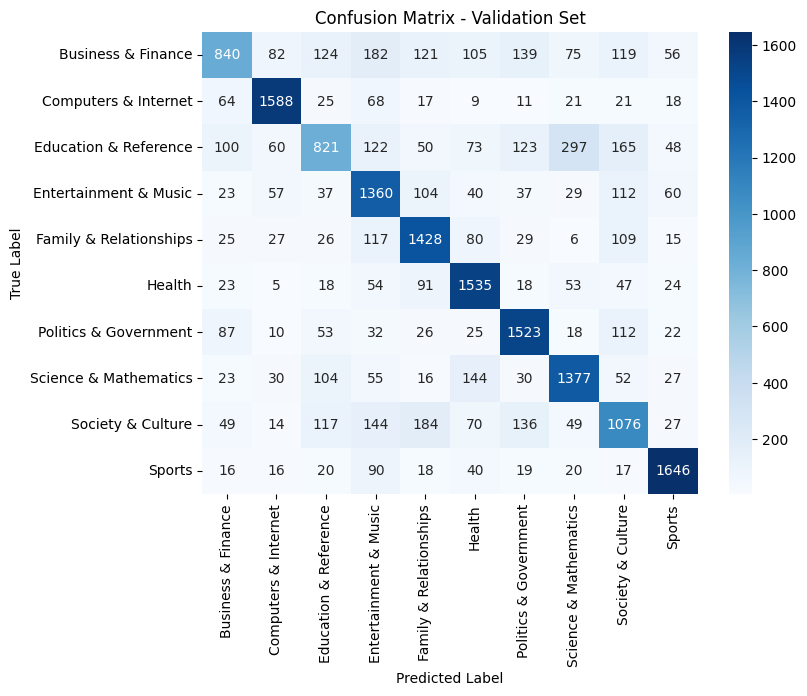


 Predicting on Test Set...
 Test Set ACCURACY: 0.6816 (68.16%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.44      0.53      6000
  Computers & Internet       0.82      0.83      0.83      6000
 Education & Reference       0.56      0.44      0.49      6000
 Entertainment & Music       0.54      0.74      0.62      6000
Family & Relationships       0.70      0.72      0.71      5999
                Health       0.71      0.80      0.76      6000
 Politics & Government       0.71      0.77      0.74      6000
 Science & Mathematics       0.69      0.72      0.71      6000
     Society & Culture       0.59      0.54      0.56      6000
                Sports       0.82      0.82      0.82      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.68     59999
          weighted avg       0.68      0.68      0.68     59

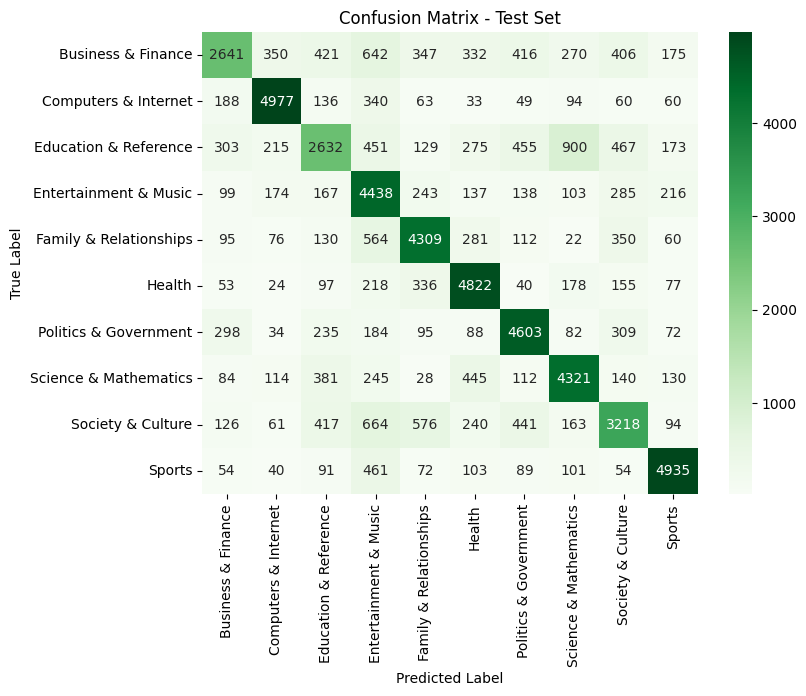

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 🔧 MANUAL HYPERPARAMETER CONFIGURATION
# ==========================================
RNN_UNITS = 128         # try values: 32, 64, 128
DENSE_UNITS = 64        # try values: 16, 32, 64
DROPOUT_RATE = 0.4      # try values: 0.3, 0.4, 0.5
LEARNING_RATE = 0.001   # try values: 0.01, 0.001, 0.0001
BATCH_SIZE = 256        # try values: 128, 256, 512
EPOCHS = 15             # can adjust based on early stopping

# ==========================================
# CONSTANTS
# ==========================================
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# ==========================================
# BUILD GRU MODEL
# ==========================================
model_gru_tuned = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    GRU(RNN_UNITS, return_sequences=False),

    Dense(DENSE_UNITS, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

# ==========================================
# COMPILE MODEL
# ==========================================
optimizer = Adam(learning_rate=LEARNING_RATE)
model_gru_tuned.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_gru_tuned.summary()

# ==========================================
# EARLY STOPPING
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# ==========================================
# TRAIN MODEL
# ==========================================
history_gru_tuned = model_gru_tuned.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# EVALUATE MODEL
# ==========================================
evaluate_keras_model(
    model=model_gru_tuned,
    history=history_gru_tuned,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)


# hyperparameter tuning for bidirect gru

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 200, 100)       │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       176,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,738 (8.37 MB)

 Trainable params: 193,738 (756.79 KB)

 Non-trainable params: 2,000,000 (7.63 MB)

Epoch 1/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 15s 42ms/step - accuracy: 0.4301 - loss: 1.6580 - val_accuracy: 0.6686 - val_loss: 1.0432
Epoch 2/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.6605 - loss: 1.0842 - val_accuracy: 0.6874 - val_loss: 0.9762
Epoch 3/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.6811 - loss: 1.0212 - val_accuracy: 0.6903 - val_loss: 0.9659
Epoch 4/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step - accuracy: 0.6890 - loss: 0.9943 - val_accuracy: 0.6933 - val_loss: 0.9465
Epoch 5/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - accuracy: 0.6911 - loss: 0.9803 - val_accuracy: 0.6983 - val_loss: 0.9352
Epoch 6/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - accuracy: 0.6971 - loss: 0.9638 - val_accuracy: 0.7005 - val_loss: 0.9274
Epoch 7/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.6999 - loss: 0.9528 - val_accuracy: 0.7034 - val_loss: 0.9215
Epoch 8/15
292/292 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.7023 - loss: 0.9421 - 

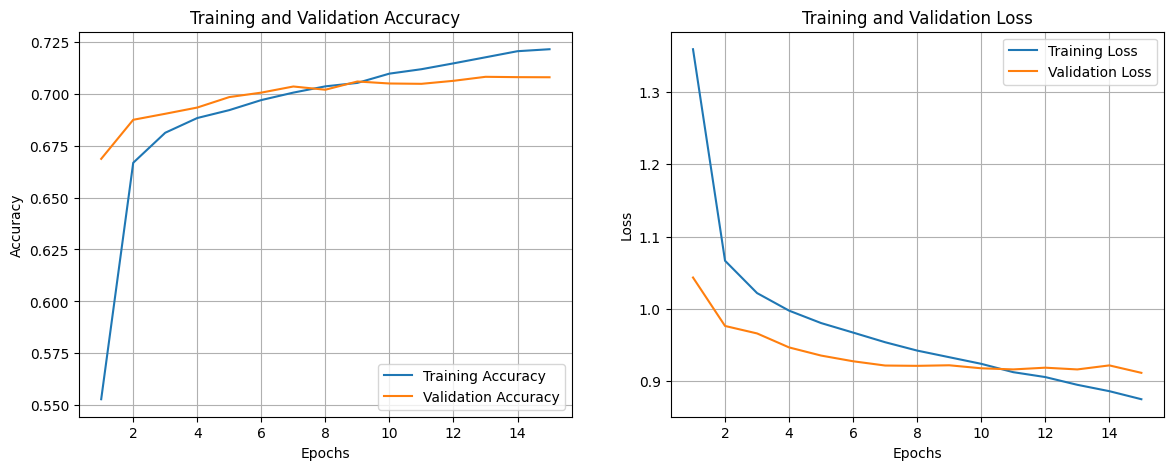


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7079 (70.79%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.64      0.47      0.54      1843
  Computers & Internet       0.83      0.87      0.85      1842
 Education & Reference       0.60      0.46      0.52      1859
 Entertainment & Music       0.69      0.67      0.68      1859
Family & Relationships       0.67      0.78      0.72      1862
                Health       0.74      0.81      0.77      1868
 Politics & Government       0.74      0.80      0.77      1908
 Science & Mathematics       0.70      0.74      0.72      1858
     Society & Culture       0.56      0.60      0.58      1866
                Sports       0.87      0.86      0.87      1902

              accuracy                           0.71     18667
             macro avg       0.70      0.71      0.70     18667
          weighted avg       0.70      0.7

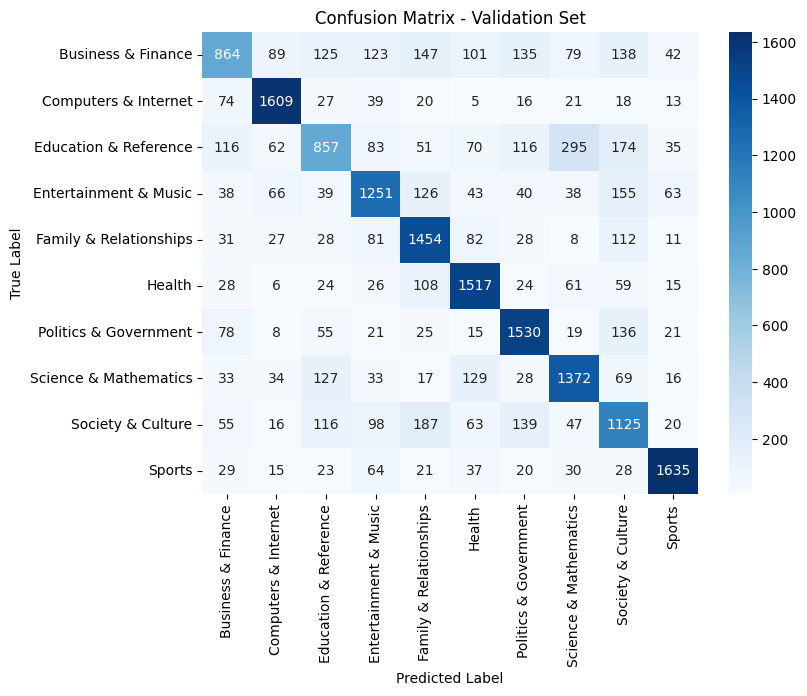


 Predicting on Test Set...
 Test Set ACCURACY: 0.6850 (68.50%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.66      0.45      0.53      6000
  Computers & Internet       0.81      0.84      0.82      6000
 Education & Reference       0.54      0.46      0.49      6000
 Entertainment & Music       0.62      0.68      0.65      6000
Family & Relationships       0.67      0.75      0.71      5999
                Health       0.71      0.80      0.75      6000
 Politics & Government       0.72      0.77      0.74      6000
 Science & Mathematics       0.68      0.73      0.70      6000
     Society & Culture       0.57      0.56      0.56      6000
                Sports       0.84      0.82      0.83      6000

              accuracy                           0.69     59999
             macro avg       0.68      0.69      0.68     59999
          weighted avg       0.68      0.69      0.68     59

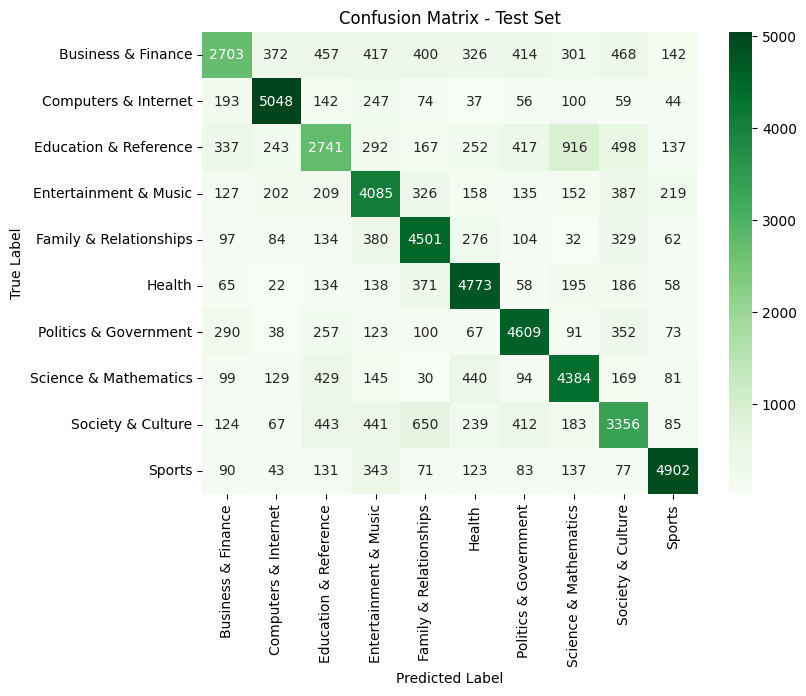

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ==========================================
# 🔧 MANUAL HYPERPARAMETER CONFIGURATION
# ==========================================
RNN_UNITS = 128         # try values: 32, 64, 128
DENSE_UNITS = 64        # try values: 16, 32, 64
DROPOUT_RATE = 0.4      # try values: 0.3, 0.4, 0.5
LEARNING_RATE = 0.001   # try values: 0.01, 0.001, 0.0001
BATCH_SIZE = 256        # try values: 128, 256, 512
EPOCHS = 15             # adjust based on early stopping

# ==========================================
# CONSTANTS
# ==========================================
MAX_SEQUENCE_LENGTH = 200
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

# ==========================================
# BUILD BIDIRECTIONAL GRU MODEL
# ==========================================
model_bi_gru_tuned = Sequential([
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    ),

    Bidirectional(GRU(RNN_UNITS, return_sequences=False)),

    Dense(DENSE_UNITS, activation='relu'),
    Dropout(DROPOUT_RATE),
    Dense(NUM_CLASSES, activation='softmax')
])

# ==========================================
# COMPILE MODEL
# ==========================================
optimizer = Adam(learning_rate=LEARNING_RATE)
model_bi_gru_tuned.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_bi_gru_tuned.summary()

# ==========================================
# EARLY STOPPING
# ==========================================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# ==========================================
# TRAIN MODEL
# ==========================================
history_bi_gru_tuned = model_bi_gru_tuned.fit(
    X_train_pad, y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# EVALUATE MODEL
# ==========================================
evaluate_keras_model(
    model=model_bi_gru_tuned,
    history=history_bi_gru_tuned,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)


# **LSTM**


# Model

In [ ]:

from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
# 1. Setup Dimensions (Safest way)
vocab_size = embedding_matrix.shape[0]      # Must match matrix rows
embedding_dim = embedding_matrix.shape[1]   # Must match matrix cols
NUM_CLASSES = len(le.classes_)              # Must match your label count

model_lstm_sg = Sequential()

# 2. Input Layer (Best practice for newer Keras versions)
model_lstm_sg.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))

# 3. Embedding Layer
model_lstm_sg.add(
    Embedding(
        input_dim=vocab_size,       # changed from MAX_VOCAB_SIZE to match matrix
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False             # Keep frozen for now
    )
)

# 4. LSTM Layer
model_lstm_sg.add(LSTM(128))        # 128 units is a good standard size

# 5. Regularization & Output
model_lstm_sg.add(Dropout(0.3))
model_lstm_sg.add(Dense(NUM_CLASSES, activation='softmax'))

# 6. Compile
model_lstm_sg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_lstm_sg.summary()

Model: "sequential_48"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_39 (Embedding)    (None, 200, 100)          2000000   
                                                                 
 lstm (LSTM)                 (None, 128)               117248    
                                                                 
 dropout_59 (Dropout)        (None, 128)               0         
                                                                 
 dense_106 (Dense)           (None, 10)                1290      
                                                                 
Total params: 2,118,538
Trainable params: 118,538
Non-trainable params: 2,000,000
_________________________________________________________________


# LSTM Model Train

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history_lstm_sg = model_lstm_sg.fit(
    X_train_pad,
    y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
292/292 [==============================] - 4s 13ms/step - loss: 0.7999 - accuracy: 0.7370 - val_loss: 0.9051 - val_accuracy: 0.7095
Epoch 2/30
292/292 [==============================] - 4s 13ms/step - loss: 0.7898 - accuracy: 0.7391 - val_loss: 0.9135 - val_accuracy: 0.7087
Epoch 3/30
292/292 [==============================] - 4s 13ms/step - loss: 0.7825 - accuracy: 0.7406 - val_loss: 0.9141 - val_accuracy: 0.7077
Epoch 4/30
292/292 [==============================] - 4s 13ms/step - loss: 0.7793 - accuracy: 0.7439 - val_loss: 0.9099 - val_accuracy: 0.7085



 Plotting Training Curves...


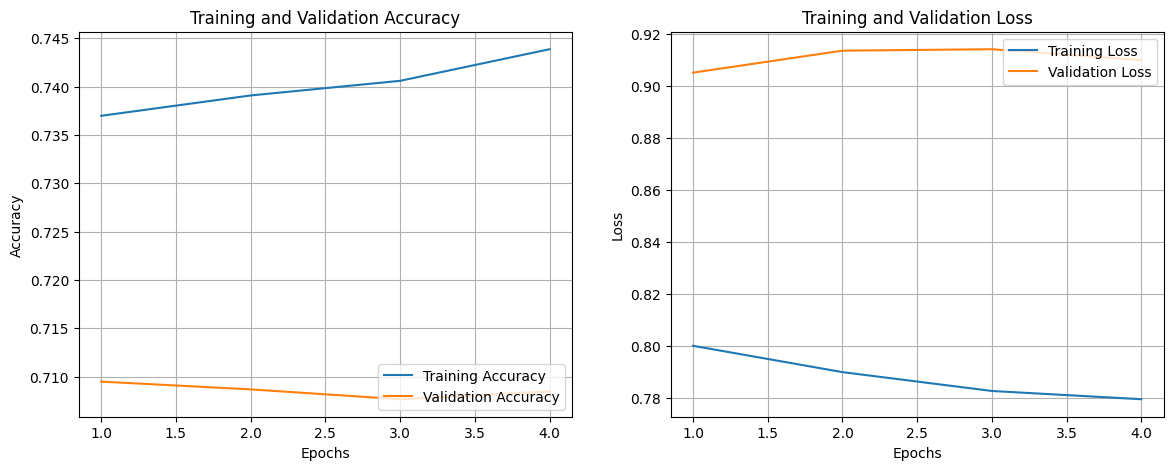


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7095 (70.95%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.65      0.47      0.55      1843
  Computers & Internet       0.84      0.86      0.85      1842
 Education & Reference       0.60      0.46      0.52      1859
 Entertainment & Music       0.66      0.70      0.68      1859
Family & Relationships       0.68      0.78      0.73      1862
                Health       0.74      0.81      0.77      1868
 Politics & Government       0.75      0.79      0.77      1908
 Science & Mathematics       0.68      0.77      0.72      1858
     Society & Culture       0.61      0.57      0.59      1866
                Sports       0.85      0.87      0.86      1902

              accuracy                           0.71     18667
             macro avg       0.70      0.71      0.70     18667
          weighted avg       0.70      0.7

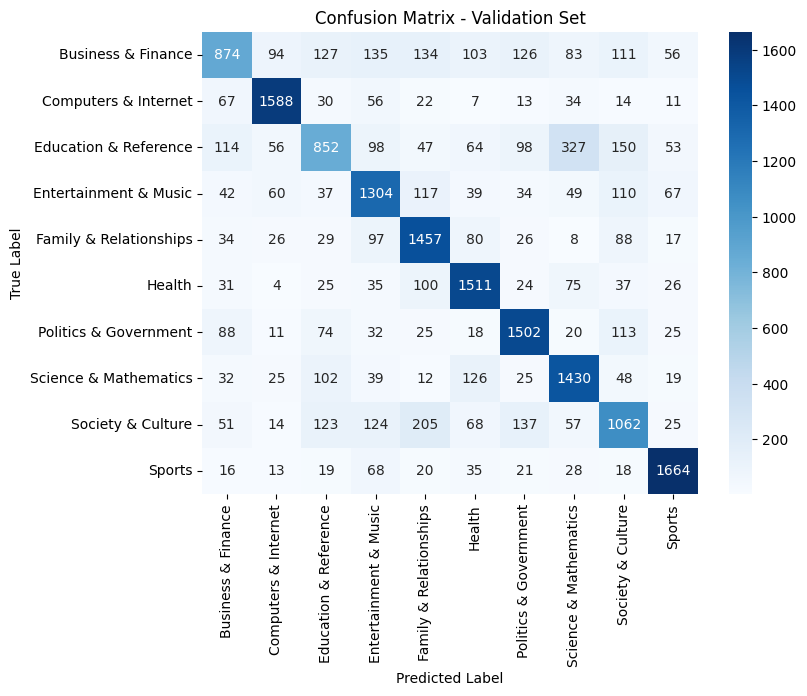


 Predicting on Test Set...
 Test Set ACCURACY: 0.6862 (68.62%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.66      0.45      0.53      6000
  Computers & Internet       0.82      0.83      0.82      6000
 Education & Reference       0.55      0.46      0.50      6000
 Entertainment & Music       0.60      0.70      0.65      6000
Family & Relationships       0.68      0.74      0.71      5999
                Health       0.72      0.79      0.75      6000
 Politics & Government       0.74      0.74      0.74      6000
 Science & Mathematics       0.66      0.77      0.71      6000
     Society & Culture       0.61      0.53      0.57      6000
                Sports       0.80      0.84      0.82      6000

              accuracy                           0.69     59999
             macro avg       0.68      0.69      0.68     59999
          weighted avg       0.68      0.69      0.68     59

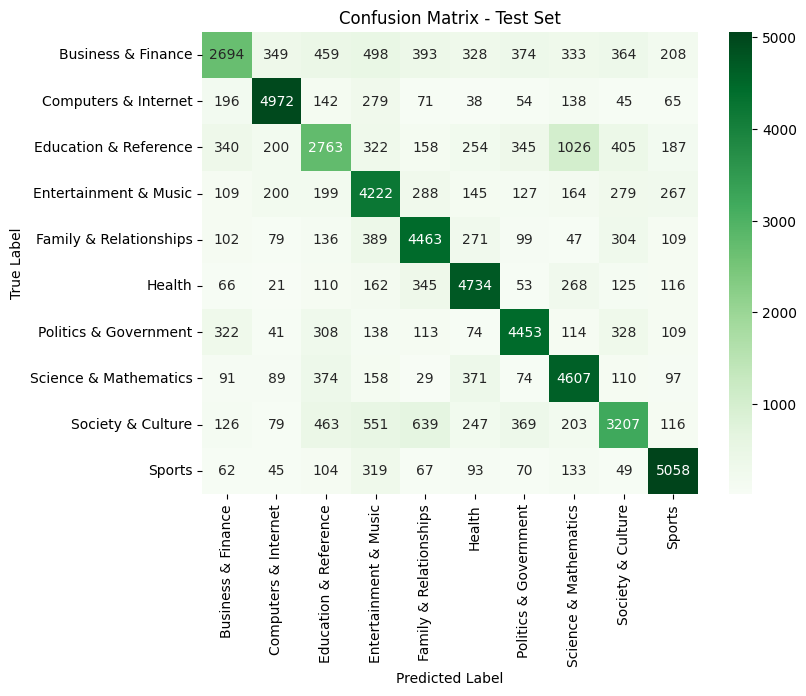

In [ ]:
evaluate_keras_model(
    model=model_lstm_sg,
    history=history_lstm_sg,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)


# **LSTM Hyper Param Tuning**

In [ ]:
param_grid = {
    'hidden_layers': [1, 2],
    'trainable': [False, True],
    'units': [64, 128, 256],
    'dropout_rate': [0.3, 0.5],
    'l2_strength': [0.001],
}

results = []
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
MAX_SEQUENCE_LENGTH = 200

BATCH_SIZE = 128


# ==========================================
#  2. Start the Loop
# ==========================================
for layers in param_grid['hidden_layers']:
    for trainable in param_grid['trainable']:
        for units in param_grid['units']:
            for dropout in param_grid['dropout_rate']:
                for l2_val in param_grid['l2_strength']:

                    print(f"\nTesting: Layers={layers}, Tune={trainable}, Units={units}, Drop={dropout}")

                    model = Sequential()

                    # Input & Embedding
                    model.add(Input(shape=(MAX_SEQUENCE_LENGTH,)))
                    model.add(Embedding(input_dim=vocab_size,
                                        output_dim=embedding_dim,
                                        weights=[embedding_matrix],
                                        trainable=trainable))

                    # LSTM Layers
                    if layers == 1:
                        model.add(LSTM(units,
                                       return_sequences=False,
                                       kernel_regularizer=l2(l2_val)))
                        model.add(Dropout(dropout))

                    elif layers == 2:
                        model.add(LSTM(units,
                                       return_sequences=True,
                                       kernel_regularizer=l2(l2_val)))
                        model.add(Dropout(dropout))

                        model.add(LSTM(units,
                                       return_sequences=False,
                                       kernel_regularizer=l2(l2_val)))
                        model.add(Dropout(dropout))

                    # Output
                    model.add(Dense(NUM_CLASSES, activation='softmax'))

                    # Compile
                    model.compile(optimizer=Adam(learning_rate=0.001),
                                  loss='sparse_categorical_crossentropy',
                                  metrics=['accuracy'])

                    early_stop = EarlyStopping(monitor='val_loss', patience=2, verbose=0, restore_best_weights=True)

                    history = model.fit(
                        X_train_pad, y_train_enc,
                        epochs=8,
                        batch_size=BATCH_SIZE,  # <--- Fast Batch Size
                        validation_data=(X_val_pad, y_val_enc),
                        callbacks=[early_stop],
                        verbose=0
                    )

                    best_val_acc = max(history.history['val_accuracy'])
                    print(f"   >>> Result: {best_val_acc:.4f}")

                    results.append({
                        'Layers': layers,
                        'Trainable': trainable,
                        'Units': units,
                        'Dropout': dropout,
                        'Val_Acc': best_val_acc
                    })

# ==========================================
#  3. Final Report
# ==========================================
print("\n🏆 Ultimate Grid Search Results:")
df_results = pd.DataFrame(results)
df_sorted = df_results.sort_values(by='Val_Acc', ascending=False)
print(df_sorted)

print(f"\n✅ Best Configuration:\n{df_sorted.iloc[0]}")


Testing: Layers=1, Tune=False, Units=64, Drop=0.3
   >>> Result: 0.6832

Testing: Layers=1, Tune=False, Units=64, Drop=0.5
   >>> Result: 0.6877

Testing: Layers=1, Tune=False, Units=128, Drop=0.3
   >>> Result: 0.6802

Testing: Layers=1, Tune=False, Units=128, Drop=0.5
   >>> Result: 0.6851

Testing: Layers=1, Tune=False, Units=256, Drop=0.3
   >>> Result: 0.6843

Testing: Layers=1, Tune=False, Units=256, Drop=0.5
   >>> Result: 0.6828

Testing: Layers=1, Tune=True, Units=64, Drop=0.3
   >>> Result: 0.7007

Testing: Layers=1, Tune=True, Units=64, Drop=0.5
   >>> Result: 0.6971

Testing: Layers=1, Tune=True, Units=128, Drop=0.3
   >>> Result: 0.7027

Testing: Layers=1, Tune=True, Units=128, Drop=0.5
   >>> Result: 0.6673

Testing: Layers=1, Tune=True, Units=256, Drop=0.3
   >>> Result: 0.7009

Testing: Layers=1, Tune=True, Units=256, Drop=0.5
   >>> Result: 0.7025

Testing: Layers=2, Tune=False, Units=64, Drop=0.3
   >>> Result: 0.6807

Testing: Layers=2, Tune=False, Units=64, Drop=0.

# **BI-Directional LSTM**

In [ ]:
MAX_SEQUENCE_LENGTH = 200 # Assuming this is consistent from previous cells
vocab_size = embedding_matrix.shape[0]
EMBEDDING_DIM = embedding_matrix.shape[1]
NUM_CLASSES = len(le.classes_)

bilstm_model = Sequential()

bilstm_model.add(
    Embedding(
        vocab_size,
        EMBEDDING_DIM,
        weights=[embedding_matrix],
        trainable=False
    )
)

bilstm_model.add(
    Bidirectional(
        LSTM(128, dropout=0.3)
    )
)

bilstm_model.add(Dense(NUM_CLASSES, activation='softmax'))

bilstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

# BILSTM TRAIN

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = bilstm_model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 48s 20ms/step - accuracy: 0.5169 - loss: 1.4751 - val_accuracy: 0.6682 - val_loss: 1.0456
Epoch 2/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 81s 19ms/step - accuracy: 0.6524 - loss: 1.0893 - val_accuracy: 0.6858 - val_loss: 0.9722
Epoch 3/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 84s 20ms/step - accuracy: 0.6756 - loss: 1.0123 - val_accuracy: 0.6861 - val_loss: 0.9650
Epoch 4/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.6806 - loss: 0.9903 - val_accuracy: 0.6940 - val_loss: 0.9400
Epoch 5/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.6846 - loss: 0.9658 - val_accuracy: 0.6979 - val_loss: 0.9275
Epoch 6/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - accuracy: 0.6885 - loss: 0.9504 - val_accuracy: 0.7036 - val_loss: 0.9198
Epoch 7/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 46s 20ms/step - accuracy: 0.6951 - loss: 0.9304 - val_accuracy: 0.7049 - val_loss: 0.9137
Epoch 8/10
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - accuracy: 0.7015 -

# Evaluate


 Plotting Training Curves...


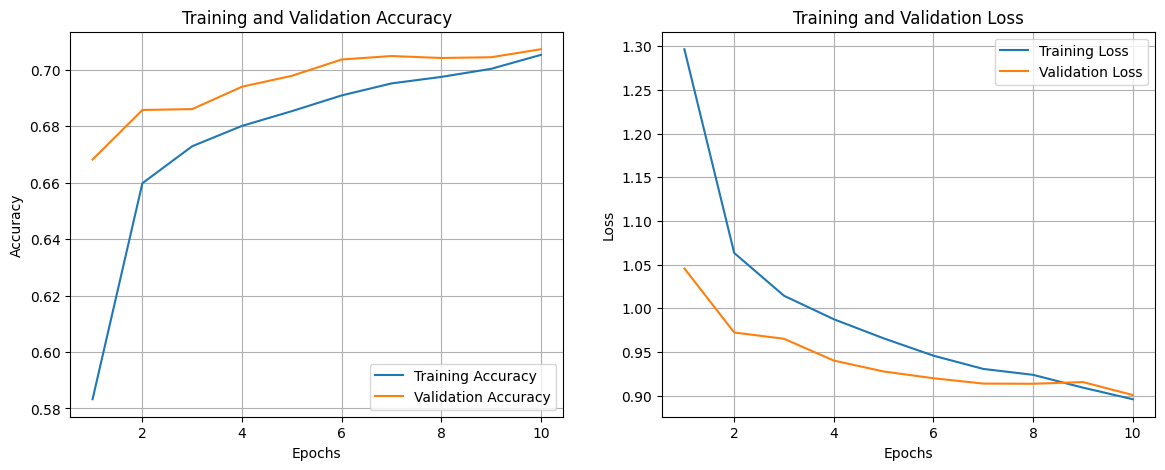


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7073 (70.73%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.47      0.55      1843
  Computers & Internet       0.82      0.88      0.85      1842
 Education & Reference       0.62      0.45      0.52      1859
 Entertainment & Music       0.64      0.69      0.67      1859
Family & Relationships       0.66      0.80      0.72      1862
                Health       0.74      0.80      0.77      1868
 Politics & Government       0.75      0.79      0.77      1908
 Science & Mathematics       0.69      0.76      0.72      1858
     Society & Culture       0.59      0.57      0.58      1866
                Sports       0.85      0.87      0.86      1902

              accuracy                           0.71     18667
             macro avg       0.70      0.71      0.70     18667
          weighted avg       0.70      0.7

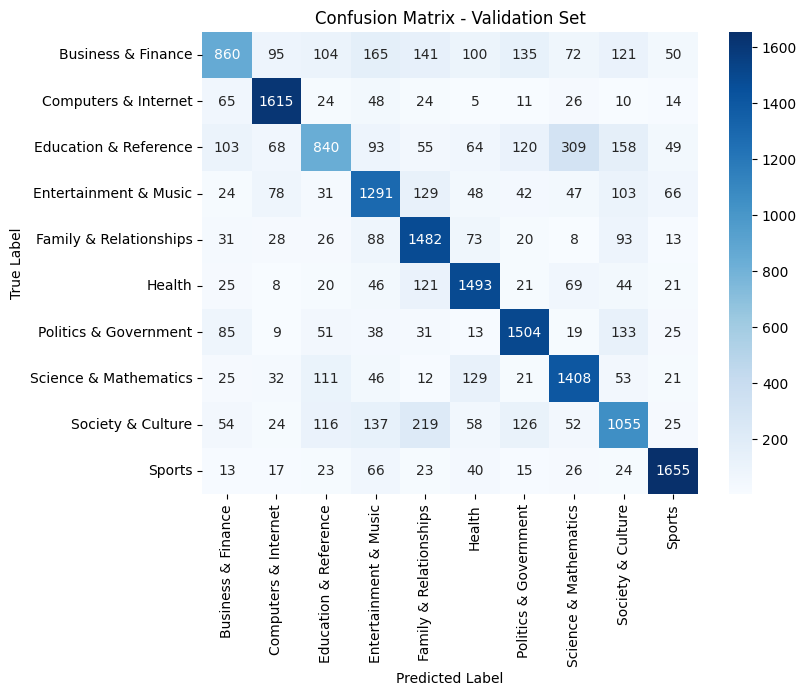


 Predicting on Test Set...
 Test Set ACCURACY: 0.6838 (68.38%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.67      0.44      0.53      6000
  Computers & Internet       0.80      0.84      0.82      6000
 Education & Reference       0.57      0.45      0.50      6000
 Entertainment & Music       0.56      0.72      0.63      6000
Family & Relationships       0.68      0.74      0.71      5999
                Health       0.73      0.79      0.76      6000
 Politics & Government       0.73      0.75      0.74      6000
 Science & Mathematics       0.66      0.75      0.70      6000
     Society & Culture       0.61      0.53      0.57      6000
                Sports       0.81      0.83      0.82      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.68     59999
          weighted avg       0.68      0.68      0.68     59

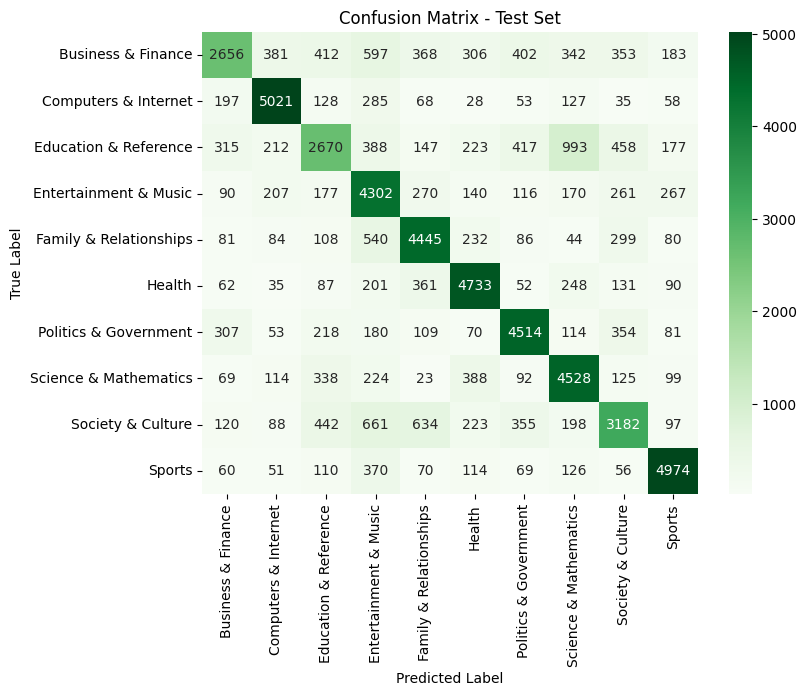

In [ ]:
evaluate_keras_model(
    model=bilstm_model,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)

# BiLSTM Hyper Param Tuning

In [ ]:
bilstm_tuning_grid = [
    {'units': 128, 'lr': 0.001,  'dropout': 0.2, 'batch_size': 32, 'epochs': 15},
    {'units': 128, 'lr': 0.0005, 'dropout': 0.2, 'batch_size': 32, 'epochs': 20},
    {'units': 256, 'lr': 0.0005, 'dropout': 0.3, 'batch_size': 32, 'epochs': 20},
    {'units': 256, 'lr': 0.0003, 'dropout': 0.3, 'batch_size': 64, 'epochs': 20},
]
best_acc = 0
best_config = None
best_history = None

for i, config in enumerate(bilstm_tuning_grid):
    print(f"\n--- Testing BiLSTM Config {i+1}: {config} ---")

    bilstm_model.compile(
        optimizer=Adam(learning_rate=config['lr']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )

    history = bilstm_model.fit(
        X_train_pad,
        y_train_enc,
        validation_data=(X_val_pad, y_val_enc),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        callbacks=[early_stopping],
        verbose=1
    )

    val_probs = bilstm_model.predict(X_val_pad)
    val_preds = np.argmax(val_probs, axis=1)
    val_acc = accuracy_score(y_val_enc, val_preds)

    print(f"Validation Accuracy: {val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_config = config
        best_history = history

print(f"\n🏆 Best BiLSTM Config: {best_config} with Validation Accuracy: {best_acc:.4f}")



--- Testing BiLSTM Config 1: {'units': 128, 'lr': 0.001, 'dropout': 0.2, 'batch_size': 32, 'epochs': 15} ---
Epoch 1/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 47s 19ms/step - accuracy: 0.7083 - loss: 0.8806 - val_accuracy: 0.7070 - val_loss: 0.9127
Epoch 2/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.7109 - loss: 0.8746 - val_accuracy: 0.7073 - val_loss: 0.9083
Epoch 3/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.7164 - loss: 0.8620 - val_accuracy: 0.7084 - val_loss: 0.9075
Epoch 4/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - accuracy: 0.7184 - loss: 0.8511 - val_accuracy: 0.7056 - val_loss: 0.9107
Epoch 5/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.7195 - loss: 0.8389 - val_accuracy: 0.7077 - val_loss: 0.9136
Epoch 6/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 45s 19ms/step - accuracy: 0.7255 - loss: 0.8276 - val_accuracy: 0.6905 - val_loss: 0.9666
Epoch 7/15
2334/2334 ━━━━━━━━━━━━━━━━━━━━ 44s 19ms/step - accuracy: 0.7154 - loss: 0.8638 - val_ac

In [ ]:
UNITS = 256
LEARNING_RATE = 0.0003
DROPOUT = 0.3
BATCH_SIZE = 64
EPOCHS = 20
# ==========================================

# Dimensions
vocab_size = embedding_matrix.shape[0]
embedding_dim = embedding_matrix.shape[1]
MAX_SEQUENCE_LENGTH = 200

model_bilstm = Sequential([
    # 1. Input Layer
    Input(shape=(MAX_SEQUENCE_LENGTH,)),

    # 2. Embedding Layer
    # We set trainable=True here because you are using a low learning rate (0.0003).
    # This allows the model to gently fine-tune the Word2Vec weights.
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              trainable=True),

    # 3. Bidirectional LSTM
    # Wraps the LSTM so it processes the sequence in both directions
    Bidirectional(LSTM(UNITS, return_sequences=False)),

    # 4. Dropout
    Dropout(DROPOUT),

    # 5. Output Layer
    Dense(NUM_CLASSES, activation='softmax')
])

# Compile
opt = Adam(learning_rate=LEARNING_RATE)
model_bilstm.compile(optimizer=opt,
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    verbose=1,
    restore_best_weights=True
)

model_bilstm.summary()

print(f"🚀 Training Bidirectional LSTM (Units={UNITS}, LR={LEARNING_RATE})...")

history = model_bilstm.fit(
    X_train_pad,
    y_train_enc,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val_pad, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_73"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_64 (Embedding)    (None, 200, 100)          2000000   
                                                                 
 bidirectional (Bidirectiona  (None, 512)              731136    
 l)                                                              
                                                                 
 dropout_96 (Dropout)        (None, 512)               0         
                                                                 
 dense_131 (Dense)           (None, 10)                5130      
                                                                 
Total params: 2,736,266
Trainable params: 2,736,266
Non-trainable params: 0
_________________________________________________________________
🚀 Training Bidirectional LSTM (Units=256, LR=0.0003)...
Epoch 1/20
1167/1167 [==============================]


 Plotting Training Curves...


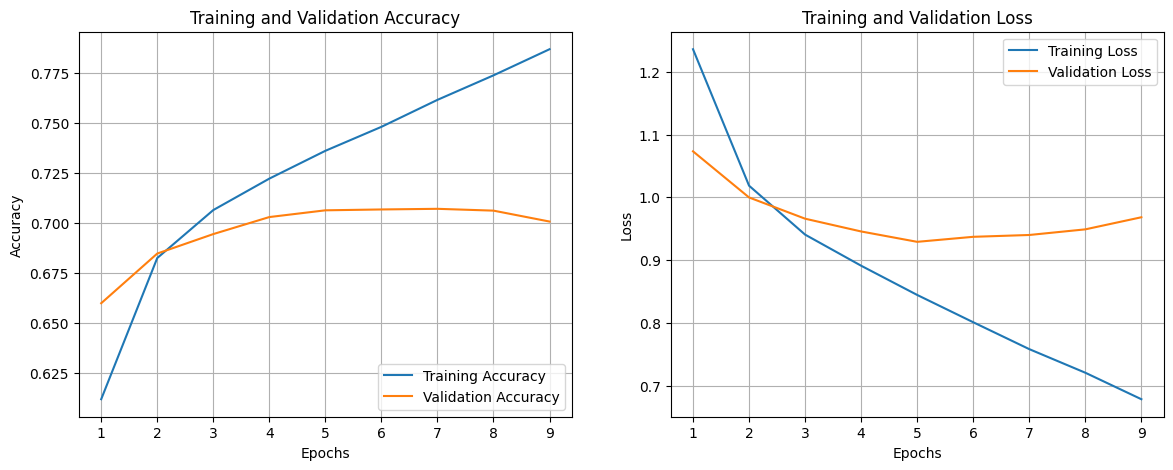


 Predicting on Validation Set...
 Validation Set ACCURACY: 0.7062 (70.62%)

--- Classification Report (Validation Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.65      0.47      0.54      1843
  Computers & Internet       0.86      0.85      0.85      1842
 Education & Reference       0.56      0.49      0.52      1859
 Entertainment & Music       0.67      0.70      0.69      1859
Family & Relationships       0.68      0.77      0.72      1862
                Health       0.73      0.81      0.77      1868
 Politics & Government       0.77      0.75      0.76      1908
 Science & Mathematics       0.67      0.77      0.72      1858
     Society & Culture       0.61      0.56      0.58      1866
                Sports       0.81      0.89      0.85      1902

              accuracy                           0.71     18667
             macro avg       0.70      0.71      0.70     18667
          weighted avg       0.70      0.7

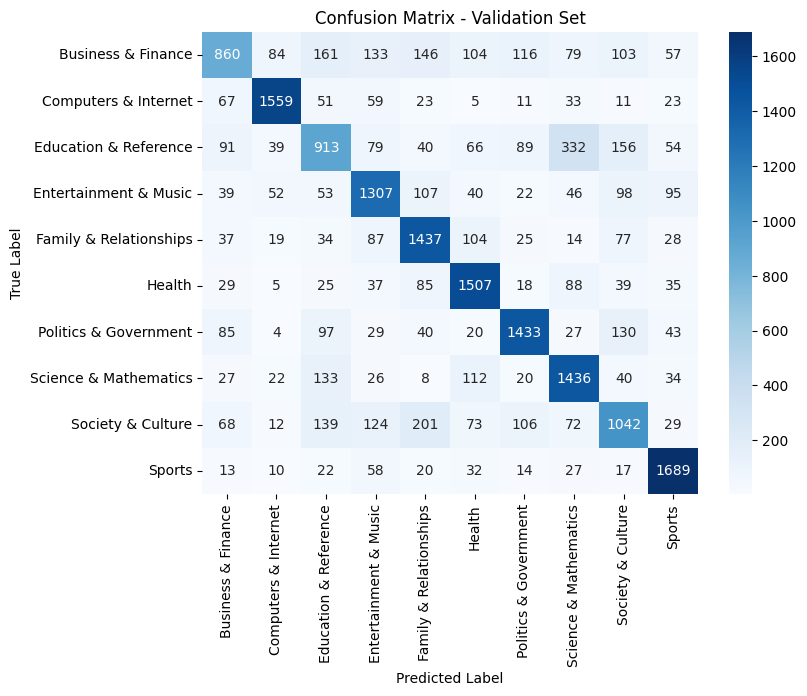


 Predicting on Test Set...
 Test Set ACCURACY: 0.6778 (67.78%)

--- Classification Report (Test Set) ---
                        precision    recall  f1-score   support

    Business & Finance       0.69      0.42      0.52      6000
  Computers & Internet       0.85      0.81      0.83      6000
 Education & Reference       0.48      0.50      0.49      6000
 Entertainment & Music       0.58      0.70      0.64      6000
Family & Relationships       0.72      0.70      0.71      5999
                Health       0.72      0.77      0.75      6000
 Politics & Government       0.78      0.71      0.74      6000
 Science & Mathematics       0.63      0.79      0.70      6000
     Society & Culture       0.62      0.51      0.56      6000
                Sports       0.75      0.87      0.80      6000

              accuracy                           0.68     59999
             macro avg       0.68      0.68      0.67     59999
          weighted avg       0.68      0.68      0.67     59

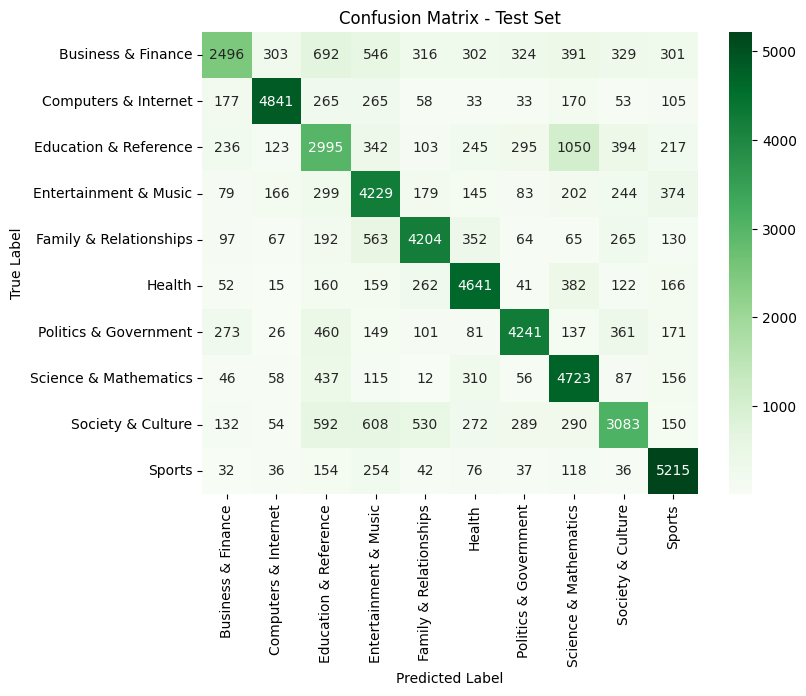

In [ ]:
evaluate_keras_model(
    model=model_bilstm,
    history=history,
    X_val=X_val_pad,
    y_val=y_val_enc,
    X_test=X_test_pad,
    y_test=y_test_enc,
    class_names=list(le.classes_)
)